In [1]:

pip install backtrader yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import backtrader as bt
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
import yfinance as yf

meta = yf.download("META", period="5y", interval="1d", auto_adjust=True)

meta.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2021-08-20,356.241669,356.856267,350.234424,351.513203,8697700
2021-08-23,360.187012,362.506638,355.974008,356.311045,10942000
2021-08-24,362.328156,364.756810,358.690090,360.494254,9235100
2021-08-25,365.183105,367.631575,362.219113,362.417385,9684500
2021-08-26,361.208008,366.223957,360.960184,365.173187,7888700


In [4]:
print("Número de días:", len(meta))
print("Desde:", meta.index[0])
print("Hasta:", meta.index[-1])

Número de días: 1254
Desde: 2021-08-20 00:00:00
Hasta: 2026-08-19 00:00:00


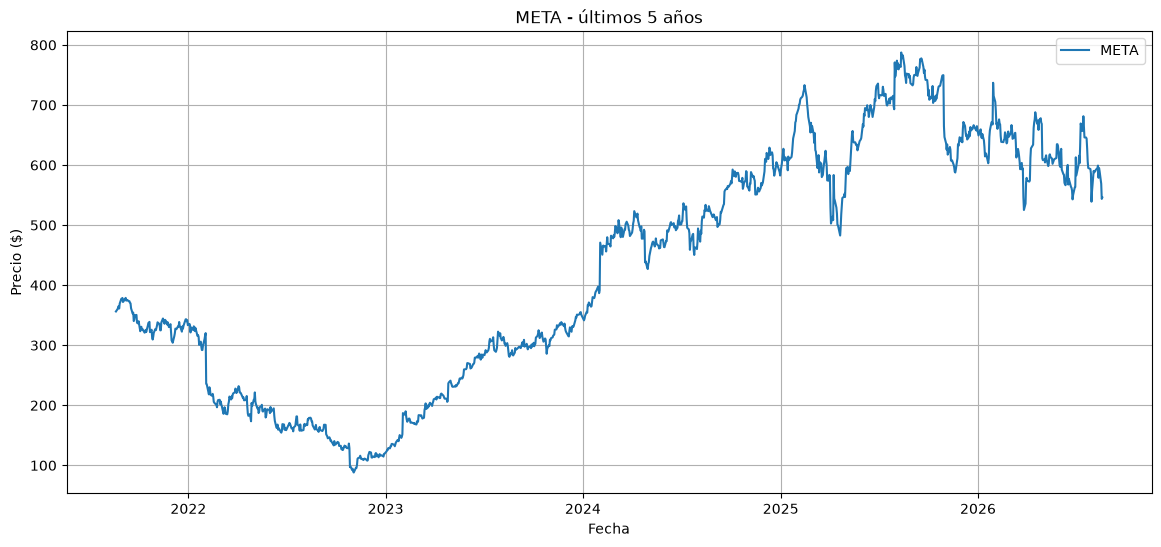

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(meta["Close"], label="META")
plt.title("META - últimos 5 años")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
meta["MA20"] = meta["Close"].rolling(20).mean()
meta["MA50"] = meta["Close"].rolling(50).mean()

meta[["Close", "MA20", "MA50"]].tail()

Price,Close,MA20,MA50
Ticker,META,,
Date,,,
2026-08-13,594.969971,597.478494,597.708984
2026-08-14,589.849976,594.670493,597.057921
2026-08-17,568.969971,590.826492,595.897543
2026-08-18,543.669983,585.819492,594.921924
2026-08-19,546.030029,581.762494,594.145565


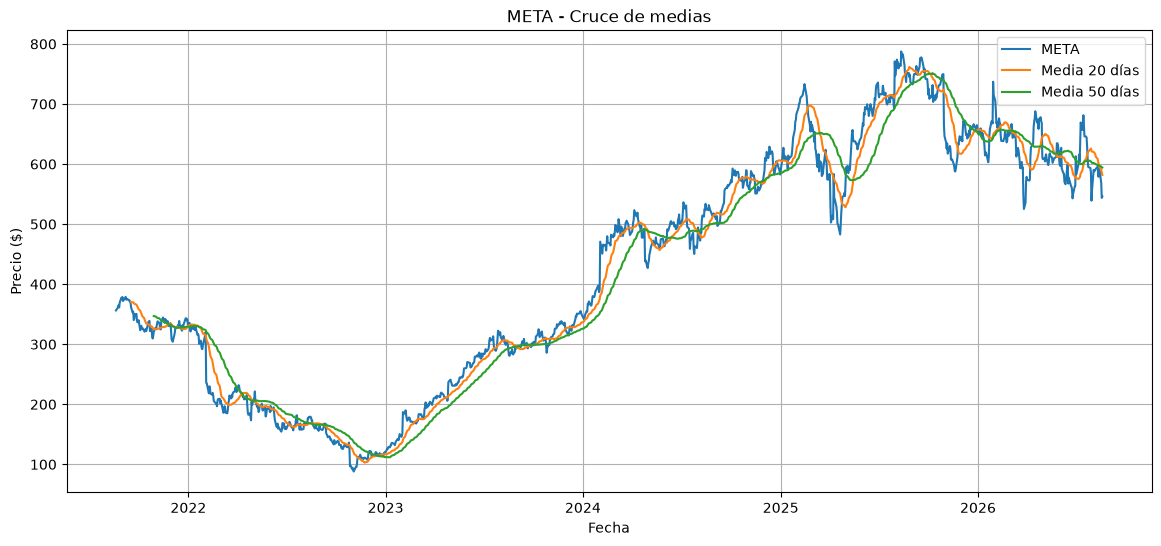

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(meta["Close"], label="META")
plt.plot(meta["MA20"], label="Media 20 días")
plt.plot(meta["MA50"], label="Media 50 días")

plt.title("META - Cruce de medias")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.grid(True)
plt.legend()

plt.show()

In [8]:
meta["Signal"] = 0

meta.loc[meta["MA20"] > meta["MA50"], "Signal"] = 1
meta.loc[meta["MA20"] < meta["MA50"], "Signal"] = -1

meta["Cambio"] = meta["Signal"].diff()

meta[meta["Cambio"] != 0][
    ["Close", "MA20", "MA50", "Signal"]
]

Price,Close,MA20,MA50,Signal
Ticker,META,,,
Date,,,,
2021-08-20,356.241669,NaN,NaN,0
2021-10-29,320.753235,325.093170,346.932393,-1
2021-11-26,330.220184,333.482013,333.072507,1
2021-12-14,330.834747,327.599168,327.657257,-1
2021-12-31,333.421997,329.983235,329.297061,1
2022-01-21,300.530884,328.432356,328.715965,-1
2022-04-12,212.275894,218.301470,216.043799,1
2022-05-02,209.292084,205.742262,205.765260,-1


In [9]:
capital_inicial = 10000
capital = capital_inicial
acciones = 0

operaciones = []

for fecha, fila in meta.iterrows():

    precio = float(fila["Close"].iloc[0])

    # COMPRA
    if fila["Cambio"].iloc[0] == 2 and acciones == 0:

        acciones = capital / precio
        capital = 0

        operaciones.append({
            "Fecha": fecha,
            "Tipo": "COMPRA",
            "Precio": precio
        })

    # VENTA
    elif fila["Cambio"].iloc[0] == -2 and acciones > 0:

        capital = acciones * precio
        acciones = 0

        operaciones.append({
            "Fecha": fecha,
            "Tipo": "VENTA",
            "Precio": precio
        })

print("Backtest ejecutado.")
print("Número de operaciones:", len(operaciones))

Backtest ejecutado.
Número de operaciones: 26


In [10]:
ultimo_precio = float(meta["Close"].iloc[-1].iloc[0])

if acciones > 0:
    capital_final = acciones * ultimo_precio
else:
    capital_final = capital

rentabilidad = (capital_final / capital_inicial - 1) * 100

print(f"Capital inicial: ${capital_inicial:,.2f}")
print(f"Capital final:   ${capital_final:,.2f}")
print(f"Rentabilidad:    {rentabilidad:.2f}%")

Capital inicial: $10,000.00
Capital final:   $27,341.40
Rentabilidad:    173.41%


In [11]:
precio_inicial = float(meta["Close"].iloc[0].iloc[0])
precio_final = float(meta["Close"].iloc[-1].iloc[0])

rentabilidad_buy_hold = (
    precio_final / precio_inicial - 1
) * 100

print(f"Rentabilidad Buy & Hold: {rentabilidad_buy_hold:.2f}%")

Rentabilidad Buy & Hold: 53.28%


In [12]:
meta["MA20"] = meta["Close"].rolling(20).mean()
meta["MA50"] = meta["Close"].rolling(50).mean()

meta["Signal"] = 0
meta.loc[meta["MA20"] > meta["MA50"], "Signal"] = 1
meta.loc[meta["MA20"] < meta["MA50"], "Signal"] = -1

meta["Cambio"] = meta["Signal"].diff()

In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Descargar META
meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=True
)

# Simplificar las columnas que devuelve yfinance
if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

# Medias móviles
meta["MA20"] = meta["Close"].rolling(20).mean()
meta["MA50"] = meta["Close"].rolling(50).mean()

# Señal
meta["Signal"] = 0
meta.loc[meta["MA20"] > meta["MA50"], "Signal"] = 1
meta.loc[meta["MA20"] < meta["MA50"], "Signal"] = -1

# Cambio de señal
meta["Cambio"] = meta["Signal"].diff()

print("Datos preparados correctamente")
print("Filas:", len(meta))
print(meta[["Close", "MA20", "MA50", "Signal", "Cambio"]].tail())

[*********************100%***********************]  1 of 1 completed

Datos preparados correctamente
Filas: 1254
Price            Close        MA20        MA50  Signal  Cambio
Date                                                          
2026-08-13  594.969971  597.478494  597.708984      -1    -2.0
2026-08-14  589.849976  594.670493  597.057921      -1     0.0
2026-08-17  568.969971  590.826492  595.897543      -1     0.0
2026-08-18  543.669983  585.819492  594.921924      -1     0.0
2026-08-19  546.030029  581.762494  594.145565      -1     0.0


In [14]:
capital_inicial = 10000
capital = capital_inicial

stop_loss = 0.04
take_profit = 0.08

en_posicion = False
precio_entrada = 0

operaciones = []

for fecha, fila in meta.iterrows():

    precio = float(fila["Close"])
    cambio = float(fila["Cambio"])

    # ENTRADA
    if not en_posicion and cambio == 2:

        en_posicion = True
        precio_entrada = precio

        operaciones.append({
            "Entrada": fecha,
            "Precio entrada": precio
        })

    # SALIDA
    elif en_posicion:

        rentabilidad = (precio - precio_entrada) / precio_entrada

        motivo = None

        if rentabilidad <= -stop_loss:
            motivo = "STOP LOSS"

        elif rentabilidad >= take_profit:
            motivo = "TAKE PROFIT"

        elif cambio == -2:
            motivo = "CRUCE BAJISTA"

        if motivo:

            operaciones[-1]["Salida"] = fecha
            operaciones[-1]["Precio salida"] = precio
            operaciones[-1]["Rentabilidad"] = rentabilidad * 100
            operaciones[-1]["Motivo"] = motivo

            capital = capital * (1 + rentabilidad)

            en_posicion = False
            precio_entrada = 0

print("Backtest terminado")

Backtest terminado


In [15]:
operaciones_df = pd.DataFrame(operaciones)

operaciones_df

,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad,Motivo
0,2021-11-26,330.220154,2021-12-01,307.896179,-6.760331,STOP LOSS
1,2021-12-31,333.422058,2022-01-18,315.380463,-5.411038,STOP LOSS
2,2022-04-12,212.275879,2022-04-20,198.675323,-6.407019,STOP LOSS
3,2022-08-15,179.315323,2022-08-19,166.497879,-7.147991,STOP LOSS
4,2022-12-19,113.483452,2023-01-03,123.654121,8.962249,TAKE PROFIT
5,2023-09-29,297.596588,2023-10-11,324.966309,9.196920,TAKE PROFIT
6,2024-06-13,500.241974,2024-07-17,458.909393,-8.262517,STOP LOSS
7,2024-08-22,528.383057,2024-09-06,496.934143,-5.951916,STOP LOSS
8,2024-12-05,605.446655,2025-01-27,656.634521,8.454563,TAKE PROFIT
9,2025-05-16,637.757446,2025-06-06,694.896057,8.959301,TAKE PROFIT


In [16]:
# ==========================================
# BACKTEST CON STOP LOSS Y TAKE PROFIT
# ==========================================

capital_inicial = 10000
capital = capital_inicial

stop_loss = 0.04      # 4%
take_profit = 0.08    # 8%

en_posicion = False
precio_entrada = 0

operaciones = []

for fecha, fila in meta.iterrows():

    # Precios del día
    apertura = float(fila["Open"])
    maximo = float(fila["High"])
    minimo = float(fila["Low"])
    cierre = float(fila["Close"])
    cambio = float(fila["Cambio"])

    # ==========================
    # ENTRADA
    # ==========================

    if not en_posicion and cambio == 2:

        en_posicion = True
        precio_entrada = cierre

        operaciones.append({
            "Entrada": fecha,
            "Precio entrada": precio_entrada
        })

    # ==========================
    # SALIDA
    # ==========================

    elif en_posicion:

        precio_stop = precio_entrada * (1 - stop_loss)
        precio_objetivo = precio_entrada * (1 + take_profit)

        precio_salida = None
        motivo = None

        # GAP bajista:
        # si abre por debajo del stop,
        # salimos al precio de apertura
        if apertura <= precio_stop:

            precio_salida = apertura
            motivo = "STOP LOSS - GAP"

        # Stop tocado durante el día
        elif minimo <= precio_stop:

            precio_salida = precio_stop
            motivo = "STOP LOSS"

        # Take profit tocado durante el día
        elif maximo >= precio_objetivo:

            precio_salida = precio_objetivo
            motivo = "TAKE PROFIT"

        # Cruce bajista
        elif cambio == -2:

            precio_salida = cierre
            motivo = "CRUCE BAJISTA"

        # ==========================
        # REGISTRAR VENTA
        # ==========================

        if precio_salida is not None:

            rentabilidad = (
                precio_salida - precio_entrada
            ) / precio_entrada

            operaciones[-1]["Salida"] = fecha
            operaciones[-1]["Precio salida"] = precio_salida
            operaciones[-1]["Rentabilidad"] = rentabilidad * 100
            operaciones[-1]["Motivo"] = motivo

            capital = capital * (1 + rentabilidad)

            en_posicion = False
            precio_entrada = 0


# ==========================================
# RESULTADOS
# ==========================================

operaciones_df = pd.DataFrame(operaciones)

print("BACKTEST TERMINADO")
print("------------------")
print(f"Capital inicial: ${capital_inicial:,.2f}")
print(f"Capital final:   ${capital:,.2f}")

rentabilidad_total = (
    capital / capital_inicial - 1
) * 100

print(f"Rentabilidad:    {rentabilidad_total:.2f}%")

print(f"Operaciones:     {len(operaciones_df)}")

ganadoras = (
    operaciones_df["Rentabilidad"] > 0
).sum()

perdedoras = (
    operaciones_df["Rentabilidad"] <= 0
).sum()

print(f"Ganadoras:       {ganadoras}")
print(f"Perdedoras:      {perdedoras}")

porcentaje_aciertos = (
    ganadoras / len(operaciones_df)
) * 100

print(f"% aciertos:      {porcentaje_aciertos:.2f}%")

BACKTEST TERMINADO
------------------
Capital inicial: $10,000.00
Capital final:   $7,739.57
Rentabilidad:    -22.60%
Operaciones:     13
Ganadoras:       3
Perdedoras:      10
% aciertos:      23.08%


In [17]:
operaciones_df

,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad,Motivo
0,2021-11-26,330.220154,2021-12-01,317.011348,-4.000000,STOP LOSS
1,2021-12-31,333.422058,2022-01-06,320.009791,-4.022609,STOP LOSS - GAP
2,2022-04-12,212.275879,2022-04-20,203.784844,-4.000000,STOP LOSS
3,2022-08-15,179.315323,2022-08-18,172.142710,-4.000000,STOP LOSS
4,2022-12-19,113.483452,2023-01-03,122.562128,8.000000,TAKE PROFIT
5,2023-09-29,297.596588,2023-10-10,321.404315,8.000000,TAKE PROFIT
6,2024-06-13,500.241974,2024-07-17,475.974858,-4.851075,STOP LOSS - GAP
7,2024-08-22,528.383057,2024-09-03,507.247734,-4.000000,STOP LOSS
8,2024-12-05,605.446655,2024-12-20,581.228789,-4.000000,STOP LOSS
9,2025-05-16,637.757446,2025-06-05,688.778042,8.000000,TAKE PROFIT


In [18]:
operaciones_df[
    ["Entrada", "Precio entrada", "Salida",
     "Precio salida", "Rentabilidad", "Motivo"]
]

,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad,Motivo
0,2021-11-26,330.220154,2021-12-01,317.011348,-4.000000,STOP LOSS
1,2021-12-31,333.422058,2022-01-06,320.009791,-4.022609,STOP LOSS - GAP
2,2022-04-12,212.275879,2022-04-20,203.784844,-4.000000,STOP LOSS
3,2022-08-15,179.315323,2022-08-18,172.142710,-4.000000,STOP LOSS
4,2022-12-19,113.483452,2023-01-03,122.562128,8.000000,TAKE PROFIT
5,2023-09-29,297.596588,2023-10-10,321.404315,8.000000,TAKE PROFIT
6,2024-06-13,500.241974,2024-07-17,475.974858,-4.851075,STOP LOSS - GAP
7,2024-08-22,528.383057,2024-09-03,507.247734,-4.000000,STOP LOSS
8,2024-12-05,605.446655,2024-12-20,581.228789,-4.000000,STOP LOSS
9,2025-05-16,637.757446,2025-06-05,688.778042,8.000000,TAKE PROFIT


In [19]:
print("RESULTADO DE CADA OPERACIÓN")
print("==========================")

for i, op in operaciones_df.iterrows():
    print(
        f"{op['Entrada'].date()} → "
        f"{op['Salida'].date()} | "
        f"{op['Rentabilidad']:+.2f}% | "
        f"{op['Motivo']}"
    )

print("\nRentabilidad acumulada:")

rentabilidad_acumulada = (
    (1 + operaciones_df["Rentabilidad"] / 100).prod() - 1
) * 100

print(f"{rentabilidad_acumulada:+.2f}%")

RESULTADO DE CADA OPERACIÓN
2021-11-26 → 2021-12-01 | -4.00% | STOP LOSS
2021-12-31 → 2022-01-06 | -4.02% | STOP LOSS - GAP
2022-04-12 → 2022-04-20 | -4.00% | STOP LOSS
2022-08-15 → 2022-08-18 | -4.00% | STOP LOSS
2022-12-19 → 2023-01-03 | +8.00% | TAKE PROFIT
2023-09-29 → 2023-10-10 | +8.00% | TAKE PROFIT
2024-06-13 → 2024-07-17 | -4.85% | STOP LOSS - GAP
2024-08-22 → 2024-09-03 | -4.00% | STOP LOSS
2024-12-05 → 2024-12-20 | -4.00% | STOP LOSS
2025-05-16 → 2025-06-05 | +8.00% | TAKE PROFIT
2025-12-29 → 2026-01-13 | -4.00% | STOP LOSS
2026-04-27 → 2026-04-30 | -8.74% | STOP LOSS - GAP
2026-07-17 → 2026-07-23 | -5.82% | STOP LOSS - GAP

Rentabilidad acumulada:
-22.60%


In [20]:
resultados = []

stops = [0.02, 0.03, 0.04, 0.05, 0.06]
objetivos = [0.04, 0.06, 0.08, 0.10, 0.12, 0.15]

for stop_loss in stops:

    for take_profit in objetivos:

        capital = 10000
        en_posicion = False
        precio_entrada = 0
        operaciones = []

        for fecha, fila in meta.iterrows():

            apertura = float(fila["Open"])
            maximo = float(fila["High"])
            minimo = float(fila["Low"])
            cierre = float(fila["Close"])
            cambio = float(fila["Cambio"])

            # ENTRADA
            if not en_posicion and cambio == 2:

                en_posicion = True
                precio_entrada = cierre

            # SALIDA
            elif en_posicion:

                precio_stop = precio_entrada * (1 - stop_loss)
                precio_objetivo = precio_entrada * (1 + take_profit)

                precio_salida = None
                motivo = None

                # GAP bajista
                if apertura <= precio_stop:

                    precio_salida = apertura
                    motivo = "STOP"

                # STOP
                elif minimo <= precio_stop:

                    precio_salida = precio_stop
                    motivo = "STOP"

                # TAKE PROFIT
                elif maximo >= precio_objetivo:

                    precio_salida = precio_objetivo
                    motivo = "TP"

                # CRUCE BAJISTA
                elif cambio == -2:

                    precio_salida = cierre
                    motivo = "CRUCE"

                if precio_salida is not None:

                    rentabilidad = (
                        precio_salida - precio_entrada
                    ) / precio_entrada

                    capital *= (1 + rentabilidad)

                    operaciones.append(rentabilidad)

                    en_posicion = False
                    precio_entrada = 0

        # RESULTADOS

        rentabilidad_total = (
            capital / 10000 - 1
        ) * 100

        operaciones_ganadoras = sum(
            1 for x in operaciones if x > 0
        )

        total_operaciones = len(operaciones)

        if total_operaciones > 0:

            porcentaje_aciertos = (
                operaciones_ganadoras /
                total_operaciones
            ) * 100

        else:

            porcentaje_aciertos = 0

        resultados.append({
            "Stop %": stop_loss * 100,
            "Take Profit %": take_profit * 100,
            "Operaciones": total_operaciones,
            "% Aciertos": porcentaje_aciertos,
            "Rentabilidad %": rentabilidad_total
        })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    "Rentabilidad %",
    ascending=False
)

resultados_df

,Stop %,Take Profit %,Operaciones,% Aciertos,Rentabilidad %
3,2.0,10.0,13,15.384615,-3.657017
2,2.0,8.0,13,15.384615,-7.128550
9,3.0,10.0,13,23.076923,-7.655269
0,2.0,4.0,13,23.076923,-8.607900
7,3.0,6.0,13,30.769231,-9.700407
5,2.0,15.0,13,7.692308,-10.265668
6,3.0,4.0,13,38.461538,-10.286605
1,2.0,6.0,13,15.384615,-10.536384
11,3.0,15.0,13,15.384615,-10.997649
8,3.0,8.0,13,23.076923,-12.601228


[*********************100%***********************]  1 of 1 completed

BACKTEST META - ÚLTIMO AÑO
Capital inicial:       $10,000.00
Capital final MA20/50: $8,264.85
Rentabilidad MA20/50:  -17.35%

Buy & Hold:             -26.73%

Número de operaciones:  3

OPERACIONES


,Entrada,Precio entrada,Salida,Precio salida
0,2025-12-29,657.517151,2026-03-03,653.913574
1,2026-04-27,677.991638,2026-05-26,611.773010
2,2026-07-17,646.010010,2026-08-13,594.969971


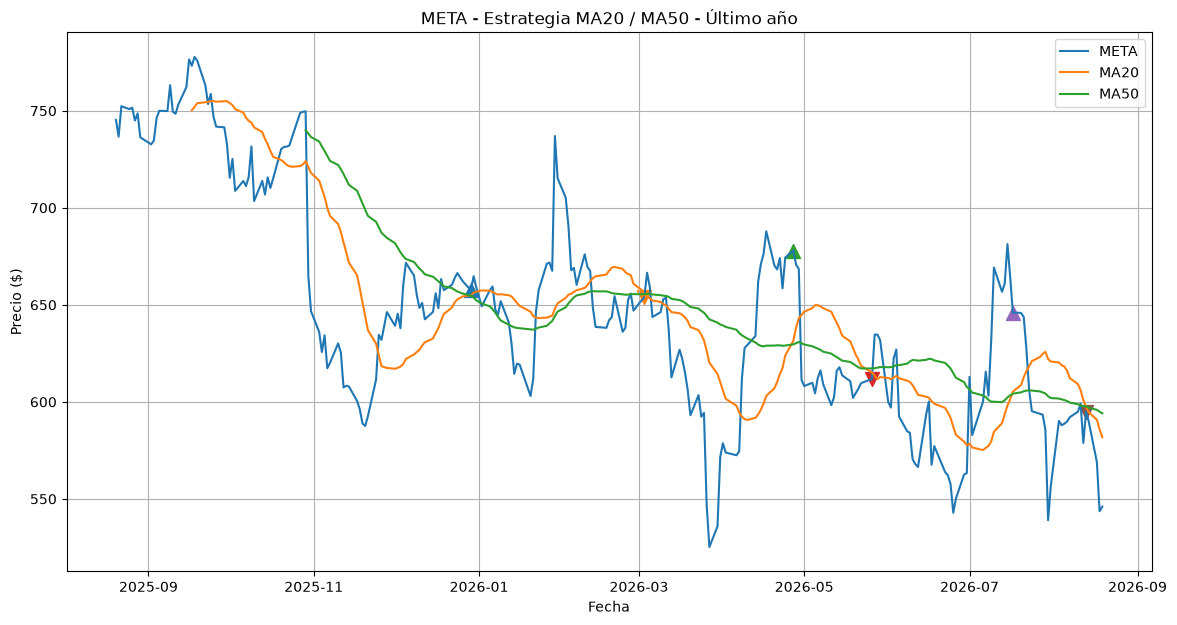

In [21]:
# ============================================================
# BACKTEST META - MA20 / MA50 - ÚLTIMO AÑO
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. DESCARGAR DATOS
# ------------------------------------------------------------

meta = yf.download(
    "META",
    period="1y",
    interval="1d",
    auto_adjust=True
)

# Compatibilidad con versiones actuales de yfinance
if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)


# ------------------------------------------------------------
# 2. CALCULAR MEDIAS MÓVILES
# ------------------------------------------------------------

meta["MA20"] = meta["Close"].rolling(20).mean()
meta["MA50"] = meta["Close"].rolling(50).mean()

meta["Signal"] = 0

meta.loc[meta["MA20"] > meta["MA50"], "Signal"] = 1
meta.loc[meta["MA20"] < meta["MA50"], "Signal"] = -1

meta["Cambio"] = meta["Signal"].diff()


# ------------------------------------------------------------
# 3. BACKTEST
# ------------------------------------------------------------

capital_inicial = 10000
capital = capital_inicial

en_posicion = False
acciones = 0

operaciones = []


for fecha, fila in meta.iterrows():

    precio = float(fila["Close"])
    cambio = float(fila["Cambio"])

    # -------------------------
    # COMPRA
    # -------------------------

    if cambio == 2 and not en_posicion:

        acciones = capital / precio
        capital = 0
        en_posicion = True

        operaciones.append({
            "Entrada": fecha,
            "Precio entrada": precio
        })


    # -------------------------
    # VENTA
    # -------------------------

    elif cambio == -2 and en_posicion:

        capital = acciones * precio
        acciones = 0
        en_posicion = False

        operaciones[-1]["Salida"] = fecha
        operaciones[-1]["Precio salida"] = precio


# ------------------------------------------------------------
# 4. VALOR FINAL
# ------------------------------------------------------------

if en_posicion:

    ultimo_precio = float(meta["Close"].iloc[-1])

    capital_final = acciones * ultimo_precio

else:

    capital_final = capital


rentabilidad_ma = (
    capital_final / capital_inicial - 1
) * 100


# ------------------------------------------------------------
# 5. BUY & HOLD
# ------------------------------------------------------------

precio_inicial = float(meta["Close"].iloc[0])
precio_final = float(meta["Close"].iloc[-1])

rentabilidad_buy_hold = (
    precio_final / precio_inicial - 1
) * 100


# ------------------------------------------------------------
# 6. RESULTADOS
# ------------------------------------------------------------

print("=" * 60)
print("BACKTEST META - ÚLTIMO AÑO")
print("=" * 60)

print(f"Capital inicial:       ${capital_inicial:,.2f}")
print(f"Capital final MA20/50: ${capital_final:,.2f}")
print(f"Rentabilidad MA20/50:  {rentabilidad_ma:+.2f}%")
print()
print(f"Buy & Hold:             {rentabilidad_buy_hold:+.2f}%")
print()
print(f"Número de operaciones:  {len(operaciones)}")

print("=" * 60)


# ------------------------------------------------------------
# 7. MOSTRAR OPERACIONES
# ------------------------------------------------------------

if operaciones:

    operaciones_df = pd.DataFrame(operaciones)

    print("\nOPERACIONES")
    print("=" * 60)

    display(operaciones_df)

else:

    print("\nNo se produjeron operaciones durante el periodo.")


# ------------------------------------------------------------
# 8. GRÁFICO
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

plt.plot(
    meta.index,
    meta["Close"],
    label="META"
)

plt.plot(
    meta.index,
    meta["MA20"],
    label="MA20"
)

plt.plot(
    meta.index,
    meta["MA50"],
    label="MA50"
)


# Marcar compras y ventas

for op in operaciones:

    plt.scatter(
        op["Entrada"],
        op["Precio entrada"],
        marker="^",
        s=100
    )

    if "Salida" in op:

        plt.scatter(
            op["Salida"],
            op["Precio salida"],
            marker="v",
            s=100
        )


plt.title(
    "META - Estrategia MA20 / MA50 - Último año"
)

plt.xlabel("Fecha")
plt.ylabel("Precio ($)")

plt.grid(True)
plt.legend()

plt.show()

[*********************100%***********************]  1 of 1 completed

META - ÚLTIMO AÑO - COMPARACIÓN DE ESTRATEGIAS


,Estrategia,Rentabilidad %,Drawdown máximo %,Operaciones
2,Precio > MA20,10.99%,-11.30%,12
3,RSI + MA20,-9.92%,-17.66%,9
4,Breakout 20 días,-11.52%,-15.29%,5
0,MA20 / MA50,-19.84%,-33.69%,3
5,BUY & HOLD,-26.73%,-32.46%,1
1,MA10 / MA20,-40.31%,-40.33%,8


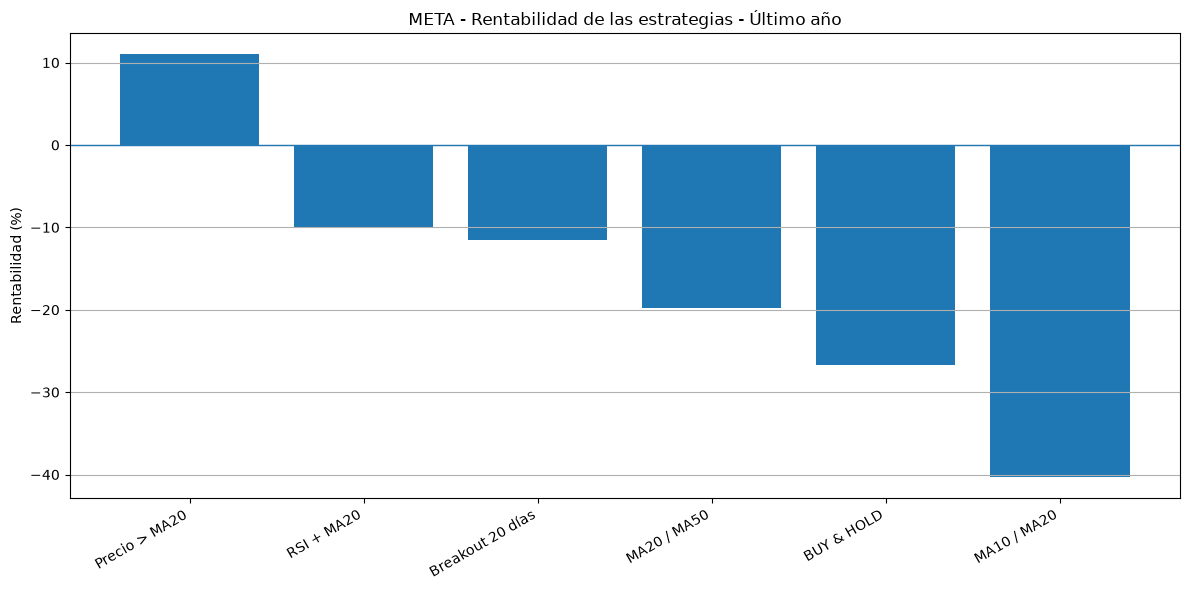

In [22]:
# ============================================================
# TORNEO DE ESTRATEGIAS - META - ÚLTIMO AÑO
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


# ============================================================
# 1. DESCARGAR DATOS
# ============================================================

meta = yf.download(
    "META",
    period="1y",
    interval="1d",
    auto_adjust=True
)

if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna(subset=["Open", "High", "Low", "Close"])


# ============================================================
# 2. INDICADORES
# ============================================================

# Medias
meta["MA10"] = meta["Close"].rolling(10).mean()
meta["MA20"] = meta["Close"].rolling(20).mean()
meta["MA50"] = meta["Close"].rolling(50).mean()

# RSI 14
delta = meta["Close"].diff()

ganancias = delta.clip(lower=0)
perdidas = -delta.clip(upper=0)

media_ganancias = ganancias.rolling(14).mean()
media_perdidas = perdidas.rolling(14).mean()

RS = media_ganancias / media_perdidas

meta["RSI"] = 100 - (100 / (1 + RS))

# Máximo de los 20 días anteriores
meta["Max20"] = meta["High"].rolling(20).max().shift(1)


# ============================================================
# 3. FUNCIÓN DE BACKTEST
# ============================================================

def backtest(nombre, señal_entrada, señal_salida):

    capital_inicial = 10000
    capital = capital_inicial

    en_posicion = False
    acciones = 0

    operaciones = []

    patrimonio = []

    for fecha, fila in meta.iterrows():

        apertura = float(fila["Open"])
        cierre = float(fila["Close"])

        # -----------------------------
        # ENTRADA
        # -----------------------------

        if not en_posicion and señal_entrada(fila):

            acciones = capital / apertura
            capital = 0
            en_posicion = True

            operaciones.append({
                "Entrada": fecha,
                "Precio entrada": apertura
            })

        # -----------------------------
        # SALIDA
        # -----------------------------

        elif en_posicion and señal_salida(fila):

            capital = acciones * apertura
            acciones = 0
            en_posicion = False

            operaciones[-1]["Salida"] = fecha
            operaciones[-1]["Precio salida"] = apertura

        # -----------------------------
        # VALOR DE LA CARTERA
        # -----------------------------

        if en_posicion:
            valor = acciones * cierre
        else:
            valor = capital

        patrimonio.append(valor)


    # Si terminamos dentro
    if en_posicion:

        ultimo_cierre = float(meta["Close"].iloc[-1])
        capital_final = acciones * ultimo_cierre

    else:

        capital_final = capital


    # -----------------------------
    # RENTABILIDAD
    # -----------------------------

    rentabilidad = (
        capital_final / capital_inicial - 1
    ) * 100


    # -----------------------------
    # DRAWDOWN
    # -----------------------------

    patrimonio = pd.Series(
        patrimonio,
        index=meta.index
    )

    maximo = patrimonio.cummax()

    drawdown = (
        patrimonio / maximo - 1
    ) * 100

    max_drawdown = drawdown.min()


    return {
        "Estrategia": nombre,
        "Rentabilidad %": rentabilidad,
        "Drawdown máximo %": max_drawdown,
        "Operaciones": len(operaciones)
    }


# ============================================================
# 4. DEFINIR ESTRATEGIAS
# ============================================================

estrategias = []


# ------------------------------------------------------------
# ESTRATEGIA 1 - MA20 / MA50
# ------------------------------------------------------------

estrategias.append(
    backtest(
        "MA20 / MA50",

        lambda x:
            x["MA20"] > x["MA50"],

        lambda x:
            x["MA20"] < x["MA50"]
    )
)


# ------------------------------------------------------------
# ESTRATEGIA 2 - MA10 / MA20
# ------------------------------------------------------------

estrategias.append(
    backtest(
        "MA10 / MA20",

        lambda x:
            x["MA10"] > x["MA20"],

        lambda x:
            x["MA10"] < x["MA20"]
    )
)


# ------------------------------------------------------------
# ESTRATEGIA 3 - PRECIO / MA20
# ------------------------------------------------------------

estrategias.append(
    backtest(
        "Precio > MA20",

        lambda x:
            x["Close"] > x["MA20"],

        lambda x:
            x["Close"] < x["MA20"]
    )
)


# ------------------------------------------------------------
# ESTRATEGIA 4 - RSI + MA20
# ------------------------------------------------------------

estrategias.append(
    backtest(
        "RSI + MA20",

        lambda x:
            x["RSI"] > 50 and
            x["Close"] > x["MA20"],

        lambda x:
            x["RSI"] < 45
    )
)


# ------------------------------------------------------------
# ESTRATEGIA 5 - BREAKOUT 20 DÍAS
# ------------------------------------------------------------

estrategias.append(
    backtest(
        "Breakout 20 días",

        lambda x:
            x["Close"] > x["Max20"],

        lambda x:
            x["Close"] < x["MA20"]
    )
)


# ============================================================
# 5. BUY & HOLD
# ============================================================

precio_inicial = float(meta["Close"].iloc[0])
precio_final = float(meta["Close"].iloc[-1])

buy_hold = (
    precio_final / precio_inicial - 1
) * 100

patrimonio_buy_hold = (
    meta["Close"] / precio_inicial
) * 10000

maximo_bh = patrimonio_buy_hold.cummax()

drawdown_bh = (
    patrimonio_buy_hold / maximo_bh - 1
) * 100

estrategias.append({
    "Estrategia": "BUY & HOLD",
    "Rentabilidad %": buy_hold,
    "Drawdown máximo %": drawdown_bh.min(),
    "Operaciones": 1
})


# ============================================================
# 6. RESULTADOS
# ============================================================

resultados = pd.DataFrame(estrategias)

resultados = resultados.sort_values(
    "Rentabilidad %",
    ascending=False
)

print("=" * 75)
print("META - ÚLTIMO AÑO - COMPARACIÓN DE ESTRATEGIAS")
print("=" * 75)

display(
    resultados.style.format({
        "Rentabilidad %": "{:.2f}%",
        "Drawdown máximo %": "{:.2f}%"
    })
)


# ============================================================
# 7. GRÁFICO DE RENTABILIDADES
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    resultados["Estrategia"],
    resultados["Rentabilidad %"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "META - Rentabilidad de las estrategias - Último año"
)

plt.ylabel("Rentabilidad (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

[*********************100%***********************]  1 of 1 completed

Datos descargados: 1254 días
Desde: 2021-08-20
Hasta: 2026-08-19

META - PRECIO > MA20 - BLOQUES INDEPENDIENTES DE 6 MESES


,Bloque,Desde,Hasta,Capital final,Rentabilidad %,Drawdown máximo %,Operaciones,% Aciertos
0,1,2021-08-20,2022-02-18,"$6,175.47",-38.25%,-38.25%,7,0.0%
1,2,2022-02-22,2022-08-19,"$8,756.13",-12.44%,-24.87%,8,12.5%
2,3,2022-08-22,2023-02-17,"$10,136.88",+1.37%,-33.82%,4,25.0%
3,4,2023-02-21,2023-08-18,"$13,206.29",+32.06%,-12.13%,4,75.0%
4,5,2023-08-21,2024-02-16,"$13,850.90",+38.51%,-7.66%,8,37.5%
5,6,2024-02-20,2024-08-19,"$11,286.54",+12.87%,-12.09%,7,42.9%
6,7,2024-08-20,2025-02-19,"$11,070.43",+10.70%,-14.88%,9,22.2%
7,8,2025-02-20,2025-08-19,"$11,189.77",+11.90%,-11.43%,4,25.0%
8,9,2025-08-20,2026-02-19,"$9,013.04",-9.87%,-12.62%,7,42.9%
9,10,2026-02-20,2026-08-19,"$7,987.33",-20.13%,-23.35%,6,0.0%



RESUMEN
Bloques ganadores:  6
Bloques perdedores: 4
Rentabilidad media: +2.67%


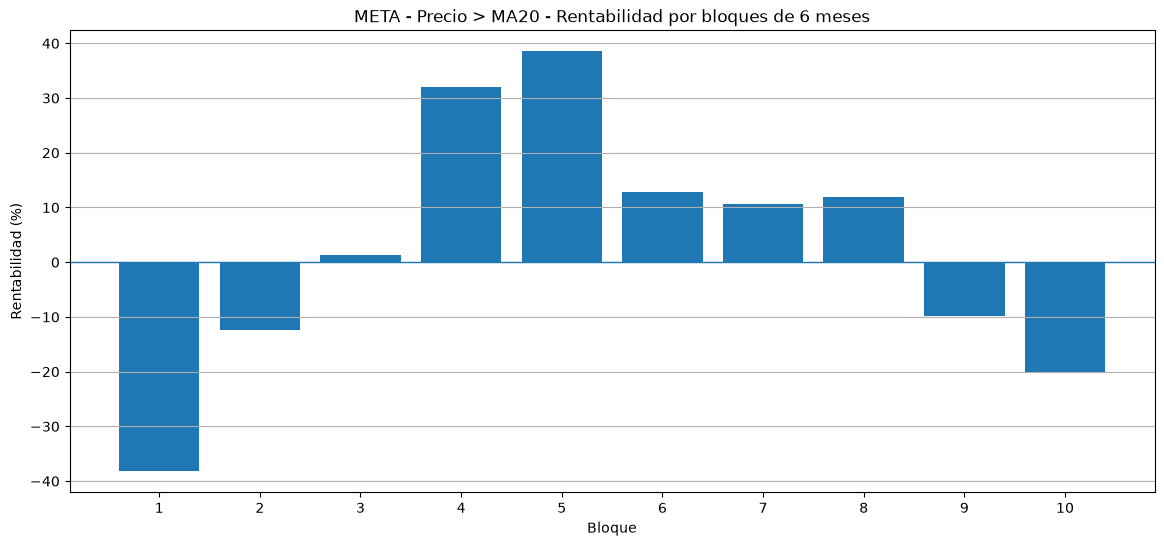

In [23]:
# ============================================================
# BACKTEST META - PRECIO > MA20
# 5 AÑOS DIVIDIDOS EN BLOQUES INDEPENDIENTES DE 6 MESES
#
# Señal al cierre
# Ejecución a la apertura del día siguiente
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


# ============================================================
# 1. DESCARGAR LOS ÚLTIMOS 5 AÑOS
# ============================================================

meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=True
)

# Compatibilidad con yfinance
if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna(subset=["Open", "High", "Low", "Close"])

print("Datos descargados:", len(meta), "días")
print("Desde:", meta.index[0].date())
print("Hasta:", meta.index[-1].date())


# ============================================================
# 2. CALCULAR MA20
# ============================================================

meta["MA20"] = meta["Close"].rolling(20).mean()


# ============================================================
# 3. CREAR SEÑALES
#
# Señal = 1  -> estar dentro
# Señal = 0  -> estar fuera
# ============================================================

meta["Señal"] = np.where(
    meta["Close"] > meta["MA20"],
    1,
    0
)

# Detectamos cambios
meta["Cambio"] = meta["Señal"].diff()


# ============================================================
# 4. CREAR BLOQUES DE 6 MESES
# ============================================================

fecha_inicio = meta.index.min()
fecha_final = meta.index.max()

bloques = []

inicio = fecha_inicio

while inicio < fecha_final:

    fin = inicio + pd.DateOffset(months=6)

    bloque = meta[
        (meta.index >= inicio) &
        (meta.index < fin)
    ].copy()

    if len(bloque) > 0:
        bloques.append(bloque)

    inicio = fin


# ============================================================
# 5. FUNCIÓN DE BACKTEST
# ============================================================

def ejecutar_backtest(datos):

    capital_inicial = 10000
    capital = capital_inicial

    en_posicion = False
    acciones = 0

    operaciones = []

    patrimonio = []

    # Necesitamos conocer la señal del día anterior
    señal_anterior = 0

    for i in range(len(datos)):

        fecha = datos.index[i]

        apertura = float(datos["Open"].iloc[i])
        cierre = float(datos["Close"].iloc[i])

        señal = int(datos["Señal"].iloc[i])


        # ====================================================
        # EJECUTAMOS LA SEÑAL DEL DÍA ANTERIOR
        # AL PRECIO DE APERTURA DE HOY
        # ====================================================

        if i > 0:

            cambio_anterior = (
                int(datos["Señal"].iloc[i-1])
                - int(datos["Señal"].iloc[i-2])
                if i > 1
                else int(datos["Señal"].iloc[i-1])
            )

        else:

            cambio_anterior = 0


        # ====================================================
        # COMPRA
        # ====================================================

        if (
            i > 0
            and not en_posicion
            and datos["Señal"].iloc[i-1] == 1
            and (i < 2 or datos["Señal"].iloc[i-2] == 0)
        ):

            acciones = capital / apertura
            capital = 0
            en_posicion = True

            operaciones.append({
                "Entrada": fecha,
                "Precio entrada": apertura
            })


        # ====================================================
        # VENTA
        # ====================================================

        elif (
            i > 0
            and en_posicion
            and datos["Señal"].iloc[i-1] == 0
            and datos["Señal"].iloc[i-2] == 1
        ):

            capital = acciones * apertura
            acciones = 0
            en_posicion = False

            operaciones[-1]["Salida"] = fecha
            operaciones[-1]["Precio salida"] = apertura

            operaciones[-1]["Rentabilidad"] = (
                operaciones[-1]["Precio salida"]
                / operaciones[-1]["Precio entrada"]
                - 1
            ) * 100


        # ====================================================
        # VALOR DE LA CARTERA AL CIERRE
        # ====================================================

        if en_posicion:
            valor = acciones * cierre
        else:
            valor = capital

        patrimonio.append(valor)


    # ========================================================
    # CERRAR POSICIÓN AL FINAL DEL BLOQUE
    # ========================================================

    if en_posicion:

        ultimo_cierre = float(datos["Close"].iloc[-1])

        capital_final = acciones * ultimo_cierre

    else:

        capital_final = capital


    # ========================================================
    # RENTABILIDAD
    # ========================================================

    rentabilidad = (
        capital_final / capital_inicial - 1
    ) * 100


    # ========================================================
    # DRAWDOWN
    # ========================================================

    patrimonio = pd.Series(
        patrimonio,
        index=datos.index
    )

    maximo = patrimonio.cummax()

    drawdown = (
        patrimonio / maximo - 1
    ) * 100

    max_drawdown = drawdown.min()


    # ========================================================
    # OPERACIONES GANADORAS
    # ========================================================

    operaciones_completas = [
        x for x in operaciones
        if "Rentabilidad" in x
    ]

    if len(operaciones_completas) > 0:

        ganadoras = sum(
            1 for x in operaciones_completas
            if x["Rentabilidad"] > 0
        )

        porcentaje_aciertos = (
            ganadoras / len(operaciones_completas)
        ) * 100

    else:

        porcentaje_aciertos = 0


    return {
        "Capital final": capital_final,
        "Rentabilidad %": rentabilidad,
        "Drawdown máximo %": max_drawdown,
        "Operaciones": len(operaciones_completas),
        "% Aciertos": porcentaje_aciertos,
        "Operaciones detalle": operaciones
    }


# ============================================================
# 6. EJECUTAR TODOS LOS BLOQUES
# ============================================================

resultados = []

for numero, bloque in enumerate(bloques, start=1):

    fecha_inicio_bloque = bloque.index[0]
    fecha_final_bloque = bloque.index[-1]

    resultado = ejecutar_backtest(bloque)

    resultados.append({

        "Bloque": numero,

        "Desde":
            fecha_inicio_bloque.strftime("%Y-%m-%d"),

        "Hasta":
            fecha_final_bloque.strftime("%Y-%m-%d"),

        "Capital final":
            resultado["Capital final"],

        "Rentabilidad %":
            resultado["Rentabilidad %"],

        "Drawdown máximo %":
            resultado["Drawdown máximo %"],

        "Operaciones":
            resultado["Operaciones"],

        "% Aciertos":
            resultado["% Aciertos"]

    })


# ============================================================
# 7. TABLA FINAL
# ============================================================

resultados_df = pd.DataFrame(resultados)


print()
print("=" * 100)
print("META - PRECIO > MA20 - BLOQUES INDEPENDIENTES DE 6 MESES")
print("=" * 100)

display(
    resultados_df.style.format({

        "Capital final": "${:,.2f}",

        "Rentabilidad %": "{:+.2f}%",

        "Drawdown máximo %": "{:.2f}%",

        "% Aciertos": "{:.1f}%"

    })
)


# ============================================================
# 8. RESUMEN
# ============================================================

bloques_ganadores = (
    resultados_df["Rentabilidad %"] > 0
).sum()

bloques_perdedores = (
    resultados_df["Rentabilidad %"] <= 0
).sum()

rentabilidad_media = (
    resultados_df["Rentabilidad %"].mean()
)

print()
print("=" * 100)
print("RESUMEN")
print("=" * 100)

print(
    f"Bloques ganadores:  {bloques_ganadores}"
)

print(
    f"Bloques perdedores: {bloques_perdedores}"
)

print(
    f"Rentabilidad media: {rentabilidad_media:+.2f}%"
)


# ============================================================
# 9. GRÁFICO
# ============================================================

plt.figure(figsize=(14, 6))

plt.bar(
    resultados_df["Bloque"].astype(str),
    resultados_df["Rentabilidad %"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "META - Precio > MA20 - Rentabilidad por bloques de 6 meses"
)

plt.xlabel("Bloque")
plt.ylabel("Rentabilidad (%)")

plt.grid(
    axis="y"
)

plt.show()

[*********************100%***********************]  1 of 1 completed


Datos descargados: 251 días
Periodo: 2025-08-20 → 2026-08-19

META - OPERACIONES ALEATORIAS - 100 SIMULACIONES


,Ejecución,Rentabilidad media,Rentabilidad mediana,Mejor resultado,Peor resultado,Capital medio,Operaciones medias
0,100%,-10.17%,-10.97%,+28.48%,-43.74%,"$8,982.72",25.2
1,75%,-13.64%,-12.68%,+20.34%,-44.02%,"$8,636.44",19.3
2,50%,-11.51%,-13.15%,+49.91%,-39.58%,"$8,849.21",12.9
3,25%,-14.72%,-16.65%,+21.68%,-41.75%,"$8,528.32",6.7
4,10%,-11.92%,-12.47%,+12.61%,-29.06%,"$8,808.36",2.2



BUY & HOLD: -26.73%


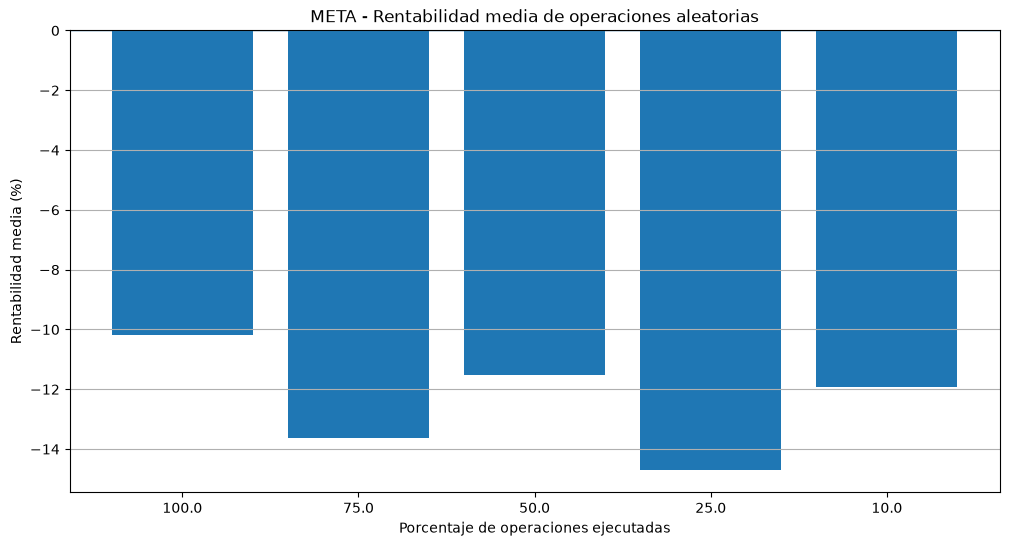

In [24]:
# ============================================================
# BACKTEST ALEATORIO - META - ÚLTIMO AÑO
# ============================================================
#
# 10.000 $
#
# Generamos señales aleatorias de COMPRA / VENTA.
#
# Después simulamos que solo ejecutamos un porcentaje
# de esas señales porque estamos de vacaciones, se nos olvida,
# no tenemos el móvil, etc.
#
# Probamos:
#   100%
#    75%
#    50%
#    25%
#    10%
#
# Cada escenario se repite 100 veces.
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


# ============================================================
# 1. DESCARGAR META - ÚLTIMO AÑO
# ============================================================

meta = yf.download(
    "META",
    period="1y",
    interval="1d",
    auto_adjust=True
)

if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna(
    subset=["Open", "Close"]
)

print("Datos descargados:", len(meta), "días")
print(
    "Periodo:",
    meta.index[0].date(),
    "→",
    meta.index[-1].date()
)


# ============================================================
# 2. FUNCIÓN PARA UNA SIMULACIÓN
# ============================================================

def simulacion_aleatoria(
    datos,
    porcentaje_ejecucion,
    probabilidad_senal=0.10,
    capital_inicial=10000
):

    capital = capital_inicial
    acciones = 0
    en_posicion = False

    operaciones = []

    for i in range(len(datos)):

        fecha = datos.index[i]

        apertura = float(
            datos["Open"].iloc[i]
        )

        cierre = float(
            datos["Close"].iloc[i]
        )


        # ----------------------------------------------------
        # GENERAR UNA SEÑAL ALEATORIA
        # ----------------------------------------------------
        #
        # Solo algunos días generamos una señal.
        #
        # probabilidad_senal = 10%
        # significa aproximadamente 1 señal cada 10 días.
        # ----------------------------------------------------

        if np.random.random() < probabilidad_senal:

            # Si estamos fuera → señal de COMPRA
            if not en_posicion:

                tipo = "COMPRA"

            # Si estamos dentro → señal de VENTA
            else:

                tipo = "VENTA"


            # ------------------------------------------------
            # ¿EJECUTAMOS LA OPERACIÓN?
            # ------------------------------------------------

            if np.random.random() < porcentaje_ejecucion:


                # ============================================
                # COMPRA
                # ============================================

                if tipo == "COMPRA":

                    acciones = capital / apertura

                    capital = 0

                    en_posicion = True

                    operaciones.append({

                        "Fecha": fecha,

                        "Tipo": "COMPRA",

                        "Precio": apertura

                    })


                # ============================================
                # VENTA
                # ============================================

                elif tipo == "VENTA":

                    capital = acciones * apertura

                    acciones = 0

                    en_posicion = False

                    operaciones.append({

                        "Fecha": fecha,

                        "Tipo": "VENTA",

                        "Precio": apertura

                    })


    # ========================================================
    # VALOR FINAL
    # ========================================================

    if en_posicion:

        ultimo_precio = float(
            datos["Close"].iloc[-1]
        )

        capital_final = (
            acciones * ultimo_precio
        )

    else:

        capital_final = capital


    # ========================================================
    # RENTABILIDAD
    # ========================================================

    rentabilidad = (
        capital_final /
        capital_inicial
        - 1
    ) * 100


    return {
        "Capital final": capital_final,
        "Rentabilidad": rentabilidad,
        "Operaciones": len(operaciones),
        "Operaciones detalle": operaciones
    }


# ============================================================
# 3. CONFIGURACIÓN
# ============================================================

porcentajes = [
    1.00,
    0.75,
    0.50,
    0.25,
    0.10
]

numero_simulaciones = 100


# ============================================================
# 4. EJECUTAR SIMULACIONES
# ============================================================

resultados = []


for porcentaje in porcentajes:

    rentabilidades = []
    capitales = []
    operaciones = []


    for simulacion in range(
        numero_simulaciones
    ):

        resultado = simulacion_aleatoria(

            meta,

            porcentaje_ejecucion=porcentaje,

            probabilidad_senal=0.10,

            capital_inicial=10000
        )


        rentabilidades.append(
            resultado["Rentabilidad"]
        )

        capitales.append(
            resultado["Capital final"]
        )

        operaciones.append(
            resultado["Operaciones"]
        )


    # --------------------------------------------------------
    # RESULTADOS
    # --------------------------------------------------------

    resultados.append({

        "Ejecución":
            porcentaje * 100,

        "Rentabilidad media":
            np.mean(rentabilidades),

        "Rentabilidad mediana":
            np.median(rentabilidades),

        "Mejor resultado":
            np.max(rentabilidades),

        "Peor resultado":
            np.min(rentabilidades),

        "Capital medio":
            np.mean(capitales),

        "Operaciones medias":
            np.mean(operaciones)

    })


# ============================================================
# 5. TABLA
# ============================================================

resultados_df = pd.DataFrame(
    resultados
)

print()
print("=" * 100)
print("META - OPERACIONES ALEATORIAS - 100 SIMULACIONES")
print("=" * 100)

display(
    resultados_df.style.format({

        "Ejecución":
            "{:.0f}%",

        "Rentabilidad media":
            "{:+.2f}%",

        "Rentabilidad mediana":
            "{:+.2f}%",

        "Mejor resultado":
            "{:+.2f}%",

        "Peor resultado":
            "{:+.2f}%",

        "Capital medio":
            "${:,.2f}",

        "Operaciones medias":
            "{:.1f}"

    })
)


# ============================================================
# 6. BUY & HOLD
# ============================================================

precio_inicial = float(
    meta["Close"].iloc[0]
)

precio_final = float(
    meta["Close"].iloc[-1]
)

rentabilidad_bh = (

    precio_final /
    precio_inicial
    - 1

) * 100


print()
print("=" * 100)

print(
    f"BUY & HOLD: {rentabilidad_bh:+.2f}%"
)

print("=" * 100)


# ============================================================
# 7. GRÁFICO
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(

    resultados_df["Ejecución"].astype(str),

    resultados_df["Rentabilidad media"]

)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "META - Rentabilidad media de operaciones aleatorias"
)

plt.xlabel(
    "Porcentaje de operaciones ejecutadas"
)

plt.ylabel(
    "Rentabilidad media (%)"
)

plt.grid(
    axis="y"
)

plt.show()

Descargando META...


[*********************100%***********************]  1 of 1 completed


Datos descargados: 1254
Desde: 2021-08-20
Hasta: 2026-08-19

BACKTEST META - SOPORTE + VOLUMEN + REBOTE
Capital inicial:   $10,000.00
Capital final:     $10,419.10
Rentabilidad:      +4.19%
Nº operaciones:    9
Buy & Hold:        +51.94%

OPERACIONES


,Entrada,Precio entrada,Soporte,Resistencia objetivo,Salida,Precio salida,Rentabilidad %,Motivo
0,2021-10-06 00:00:00,$329.74,$322.70,$383.79,2021-10-26 00:00:00,$309.79,-6.05%,STOP LOSS
1,2021-10-29 00:00:00,$320.19,$309.60,$345.02,2021-11-05 00:00:00,$345.02,+7.75%,RESISTENCIA
2,2022-01-25 00:00:00,$299.95,$303.04,$352.71,2022-01-26 00:00:00,$290.92,-3.01%,STOP LOSS
3,2022-02-07 00:00:00,$237.70,$235.75,$339.17,2022-02-08 00:00:00,$226.32,-4.79%,STOP LOSS
4,2022-11-02 00:00:00,$94.21,$92.60,$142.39,2022-11-03 00:00:00,$88.90,-5.64%,STOP LOSS
5,2024-07-15 00:00:00,$498.63,$492.39,$542.81,2024-07-17 00:00:00,$472.69,-5.20%,STOP LOSS
6,2025-04-08 00:00:00,$543.25,$494.20,$633.88,2025-05-12 00:00:00,$633.88,+16.68%,RESISTENCIA
7,2025-10-07 00:00:00,$717.72,$710.18,$790.80,2025-10-30 00:00:00,$681.77,-5.01%,STOP LOSS
8,2026-06-22 00:00:00,$572.02,$557.01,$643.00,2026-07-10 00:00:00,$643.00,+12.41%,RESISTENCIA



Drawdown máximo:  -28.04%


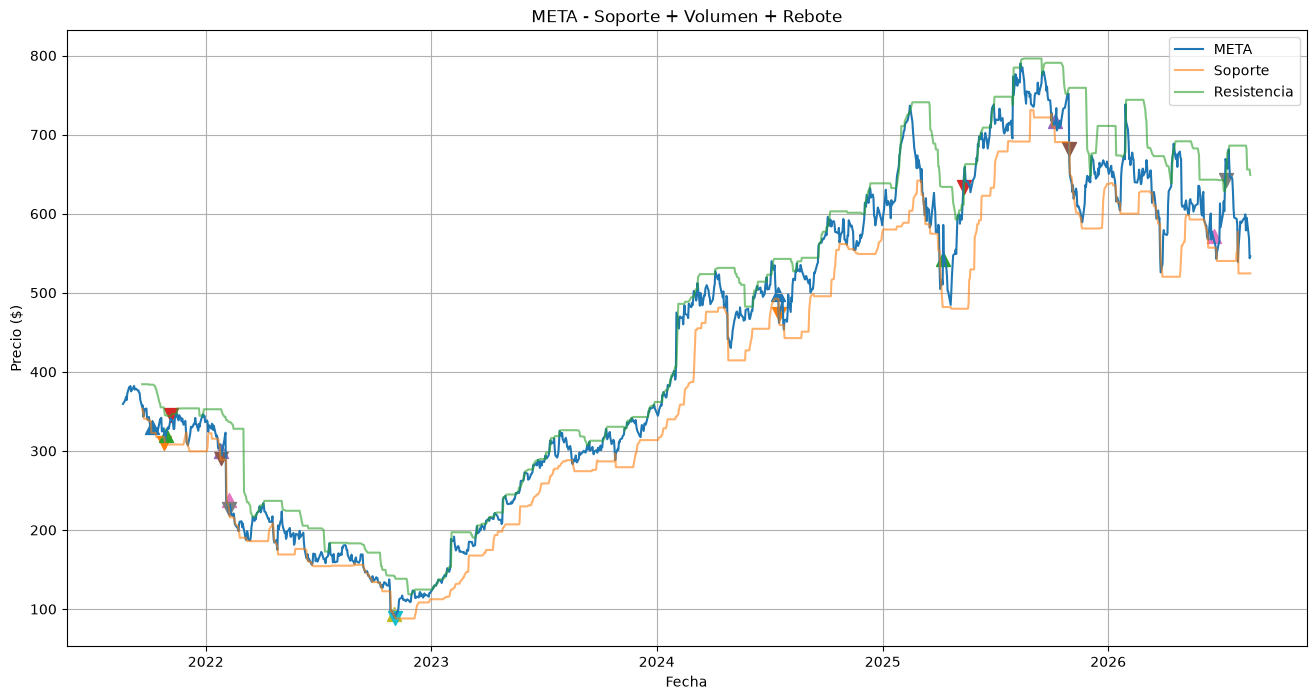


ESTADÍSTICAS
Operaciones cerradas: 9
Ganadoras:            3
Perdedoras:           6
% Aciertos:           33.33%


In [25]:

# ============================================================
# META - ESTRATEGIA SOPORTE + VOLUMEN + REBOTE
# ============================================================
#
# 1. Descarga 5 años de META
# 2. Calcula volumen relativo
# 3. Detecta soportes y resistencias mediante mínimos/máximos
#    recientes
# 4. Compra cuando:
#       - Precio está cerca de un soporte
#       - Volumen es superior a la media
#       - Se confirma el rebote
#
# 5. Vende cuando:
#       - Precio alcanza una resistencia
#
# 6. Stop Loss por debajo del soporte
#
# Capital inicial: 10.000 $
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

CAPITAL_INICIAL = 10000

# Ventana para buscar soportes/resistencias
VENTANA_SR = 20

# Distancia máxima para considerar que estamos cerca
# del soporte/resistencia
DISTANCIA_SOPORTE = 0.015      # 1,5%

# Volumen mínimo respecto a la media de 20 días
VOLUMEN_MINIMO = 1.5           # 1,5 veces

# Stop Loss por debajo del soporte
STOP_LOSS = 0.04               # 4%

# ============================================================
# 1. DESCARGAR DATOS
# ============================================================

print("Descargando META...")

meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=False
)

# Compatibilidad con versiones de yfinance
if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna(
    subset=[
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]
)

print()
print("Datos descargados:", len(meta))
print(
    "Desde:",
    meta.index[0].date()
)
print(
    "Hasta:",
    meta.index[-1].date()
)


# ============================================================
# 2. VOLUMEN MEDIO
# ============================================================

meta["Volumen_MA20"] = (
    meta["Volume"]
    .rolling(20)
    .mean()
)

meta["Volumen_Relativo"] = (
    meta["Volume"] /
    meta["Volumen_MA20"]
)


# ============================================================
# 3. SOPORTES Y RESISTENCIAS
# ============================================================
#
# IMPORTANTE:
#
# Utilizamos SHIFT(1)
#
# Esto significa que para calcular el soporte de HOY
# solamente utilizamos información de días anteriores.
#
# Evitamos así utilizar información del futuro.
# ============================================================

meta["Soporte"] = (
    meta["Low"]
    .rolling(VENTANA_SR)
    .min()
    .shift(1)
)

meta["Resistencia"] = (
    meta["High"]
    .rolling(VENTANA_SR)
    .max()
    .shift(1)
)


# ============================================================
# 4. DETECTAR SI ESTAMOS CERCA DEL SOPORTE
# ============================================================

meta["Cerca_Soporte"] = (

    meta["Low"] <=
    meta["Soporte"] *
    (1 + DISTANCIA_SOPORTE)

)


# ============================================================
# 5. DETECTAR VOLUMEN ALTO
# ============================================================

meta["Volumen_Alto"] = (

    meta["Volumen_Relativo"] >=
    VOLUMEN_MINIMO

)


# ============================================================
# 6. CONFIRMACIÓN DE REBOTE
# ============================================================
#
# Queremos evitar comprar simplemente porque el precio
# está cayendo hacia el soporte.
#
# Consideramos rebote cuando:
#
#       Close > Open
#
# Es decir, vela diaria alcista.
#
# Además exigimos que el cierre esté por encima del
# soporte.
# ============================================================

meta["Rebote"] = (

    (meta["Close"] > meta["Open"]) &

    (meta["Close"] > meta["Soporte"])

)


# ============================================================
# 7. SEÑAL DE COMPRA
# ============================================================

meta["Compra"] = (

    meta["Cerca_Soporte"] &

    meta["Volumen_Alto"] &

    meta["Rebote"]

)


# ============================================================
# 8. BACKTEST
# ============================================================

capital = CAPITAL_INICIAL

acciones = 0

en_posicion = False

precio_entrada = 0

soporte_entrada = 0

resistencia_objetivo = 0

operaciones = []

patrimonio = []


# ============================================================
# 9. RECORRER LOS DATOS
# ============================================================

for i in range(VENTANA_SR + 1, len(meta)):

    fecha = meta.index[i]

    apertura = float(
        meta["Open"].iloc[i]
    )

    maximo = float(
        meta["High"].iloc[i]
    )

    minimo = float(
        meta["Low"].iloc[i]
    )

    cierre = float(
        meta["Close"].iloc[i]
    )


    # ========================================================
    # SI ESTAMOS FUERA
    # ========================================================

    if not en_posicion:

        señal_compra = bool(
            meta["Compra"].iloc[i-1]
        )


        # ----------------------------------------------------
        # IMPORTANTE:
        #
        # La señal se produce al cierre del día anterior.
        #
        # Compramos en la APERTURA de hoy.
        # ----------------------------------------------------

        if señal_compra:

            soporte = float(
                meta["Soporte"].iloc[i-1]
            )

            resistencia = float(
                meta["Resistencia"].iloc[i-1]
            )


            # Evitar resistencias que estén por debajo
            # o demasiado cerca del precio de entrada

            if resistencia > apertura:

                acciones = (
                    capital / apertura
                )

                capital = 0

                en_posicion = True

                precio_entrada = apertura

                soporte_entrada = soporte

                resistencia_objetivo = resistencia

                operaciones.append({

                    "Entrada": fecha,

                    "Precio entrada":
                        apertura,

                    "Soporte":
                        soporte,

                    "Resistencia objetivo":
                        resistencia

                })


    # ========================================================
    # SI ESTAMOS DENTRO
    # ========================================================

    else:

        stop = (
            soporte_entrada *
            (1 - STOP_LOSS)
        )


        # ----------------------------------------------------
        # 1. STOP LOSS
        # ----------------------------------------------------

        if minimo <= stop:

            capital = (
                acciones * stop
            )

            acciones = 0

            en_posicion = False

            operaciones[-1][
                "Salida"
            ] = fecha

            operaciones[-1][
                "Precio salida"
            ] = stop

            operaciones[-1][
                "Rentabilidad %"
            ] = (

                stop /
                precio_entrada
                - 1

            ) * 100

            operaciones[-1][
                "Motivo"
            ] = "STOP LOSS"


        # ----------------------------------------------------
        # 2. RESISTENCIA
        # ----------------------------------------------------

        elif maximo >= resistencia_objetivo:

            capital = (
                acciones *
                resistencia_objetivo
            )

            acciones = 0

            en_posicion = False

            operaciones[-1][
                "Salida"
            ] = fecha

            operaciones[-1][
                "Precio salida"
            ] = resistencia_objetivo

            operaciones[-1][
                "Rentabilidad %"
            ] = (

                resistencia_objetivo /
                precio_entrada
                - 1

            ) * 100

            operaciones[-1][
                "Motivo"
            ] = "RESISTENCIA"


    # ========================================================
    # VALOR DE LA CARTERA
    # ========================================================

    if en_posicion:

        valor = (
            acciones * cierre
        )

    else:

        valor = capital

    patrimonio.append(valor)


# ============================================================
# 10. CERRAR POSICIÓN FINAL
# ============================================================

if en_posicion:

    ultimo_cierre = float(
        meta["Close"].iloc[-1]
    )

    capital_final = (
        acciones *
        ultimo_cierre
    )

else:

    capital_final = capital


# ============================================================
# 11. RESULTADOS
# ============================================================

rentabilidad = (

    capital_final /
    CAPITAL_INICIAL
    - 1

) * 100


print()
print("=" * 70)
print("BACKTEST META - SOPORTE + VOLUMEN + REBOTE")
print("=" * 70)

print(
    f"Capital inicial:   ${CAPITAL_INICIAL:,.2f}"
)

print(
    f"Capital final:     ${capital_final:,.2f}"
)

print(
    f"Rentabilidad:      {rentabilidad:+.2f}%"
)

print(
    f"Nº operaciones:    {len(operaciones)}"
)


# ============================================================
# 12. BUY & HOLD
# ============================================================

precio_inicial = float(
    meta["Close"].iloc[0]
)

precio_final = float(
    meta["Close"].iloc[-1]
)

buy_hold = (

    precio_final /
    precio_inicial
    - 1

) * 100


print(
    f"Buy & Hold:        {buy_hold:+.2f}%"
)


# ============================================================
# 13. TABLA DE OPERACIONES
# ============================================================

operaciones_df = pd.DataFrame(
    operaciones
)

print()
print("=" * 70)
print("OPERACIONES")
print("=" * 70)

if len(operaciones_df) > 0:

    display(
        operaciones_df.style.format({

            "Precio entrada":
                "${:.2f}",

            "Soporte":
                "${:.2f}",

            "Resistencia objetivo":
                "${:.2f}",

            "Precio salida":
                "${:.2f}",

            "Rentabilidad %":
                "{:+.2f}%"

        })
    )

else:

    print(
        "No se generaron operaciones."
    )


# ============================================================
# 14. DRAWDOWN
# ============================================================

patrimonio = pd.Series(
    patrimonio,
    index=meta.index[
        VENTANA_SR + 1:
    ]
)

maximo_patrimonio = (
    patrimonio.cummax()
)

drawdown = (

    patrimonio /
    maximo_patrimonio
    - 1

) * 100

max_drawdown = drawdown.min()


print()
print(
    f"Drawdown máximo:  {max_drawdown:.2f}%"
)


# ============================================================
# 15. GRÁFICO DE PRECIO
# ============================================================

plt.figure(
    figsize=(16, 8)
)

plt.plot(
    meta.index,
    meta["Close"],
    label="META"
)


# Soporte

plt.plot(
    meta.index,
    meta["Soporte"],
    label="Soporte",
    alpha=0.6
)


# Resistencia

plt.plot(
    meta.index,
    meta["Resistencia"],
    label="Resistencia",
    alpha=0.6
)


# ============================================================
# MARCAR COMPRAS Y VENTAS
# ============================================================

for operacion in operaciones:

    if "Entrada" in operacion:

        plt.scatter(
            operacion["Entrada"],
            operacion["Precio entrada"],
            marker="^",
            s=100
        )

    if "Salida" in operacion:

        plt.scatter(
            operacion["Salida"],
            operacion["Precio salida"],
            marker="v",
            s=100
        )


plt.title(
    "META - Soporte + Volumen + Rebote"
)

plt.xlabel(
    "Fecha"
)

plt.ylabel(
    "Precio ($)"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 16. ESTADÍSTICAS
# ============================================================

if len(operaciones_df) > 0:

    operaciones_cerradas = (
        operaciones_df.dropna(
            subset=["Rentabilidad %"]
        )
    )

    if len(operaciones_cerradas) > 0:

        ganadoras = (
            operaciones_cerradas[
                "Rentabilidad %"
            ] > 0
        ).sum()

        perdedoras = (
            operaciones_cerradas[
                "Rentabilidad %"
            ] <= 0
        ).sum()

        aciertos = (

            ganadoras /
            len(operaciones_cerradas)

        ) * 100


        print()
        print("=" * 70)
        print("ESTADÍSTICAS")
        print("=" * 70)

        print(
            f"Operaciones cerradas: {len(operaciones_cerradas)}"
        )

        print(
            f"Ganadoras:            {ganadoras}"
        )

        print(
            f"Perdedoras:           {perdedoras}"
        )

        print(
            f"% Aciertos:           {aciertos:.2f}%"
        )

In [26]:
# ============================================================
# META - ESTRATEGIA SOPORTE CONOCIDO + REBOTE CONFIRMADO
# ============================================================
#
# LÓGICA:
#
# 1. Descargamos 5 años de META
#
# 2. Buscamos soportes conocidos:
#       - mínimo histórico reciente
#       - al menos 2 toques anteriores
#       - los toques están relativamente cerca
#
# 3. Cuando META vuelve al soporte:
#       - volumen >= 1.5 veces la media
#       - NO compramos todavía
#
# 4. Esperamos confirmación:
#       - el cierre supera el máximo del día anterior
#
# 5. Compramos $10.000 en la apertura del día siguiente
#
# 6. Stop Loss = 4%
#
# 7. Vendemos si:
#       A) alcanza una resistencia conocida
#       B) pierde MA20
#
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

CAPITAL_INICIAL = 10000

# Número de días utilizados para buscar zonas de soporte
VENTANA_SOPORTE = 60

# Número mínimo de toques para considerar un soporte conocido
MIN_TOQUES = 2

# Distancia máxima entre precio y soporte
DISTANCIA_SOPORTE = 0.015       # 1,5%

# Volumen necesario para considerar que existe interés
VOLUMEN_MINIMO = 1.5            # 1,5 veces la media

# Stop Loss
STOP_LOSS = 0.04                # 4%

# Media móvil para salida
PERIODO_MA = 20


# ============================================================
# 1. DESCARGAR DATOS
# ============================================================

print("Descargando datos de META...")

meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=False
)

# Compatibilidad con versiones de yfinance
if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna(
    subset=[
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]
).copy()

print()
print("Datos descargados:", len(meta))
print("Desde:", meta.index[0].date())
print("Hasta:", meta.index[-1].date())


# ============================================================
# 2. INDICADORES
# ============================================================

meta["MA20"] = (
    meta["Close"]
    .rolling(PERIODO_MA)
    .mean()
)

meta["Volumen_MA20"] = (
    meta["Volume"]
    .rolling(20)
    .mean()
)

meta["Volumen_Relativo"] = (
    meta["Volume"] /
    meta["Volumen_MA20"]
)


# ============================================================
# FUNCIÓN PARA BUSCAR SOPORTE CONOCIDO
# ============================================================

def buscar_soporte(df, indice):

    inicio = max(
        0,
        indice - VENTANA_SOPORTE
    )

    historico = df.iloc[
        inicio:indice
    ]

    if len(historico) < 20:
        return None

    lows = historico["Low"].values

    precio_actual = float(
        df["Low"].iloc[indice]
    )

    # --------------------------------------------------------
    # Buscamos candidatos a soporte.
    #
    # Un candidato es un mínimo local.
    # --------------------------------------------------------

    candidatos = []

    for j in range(2, len(lows) - 2):

        low = lows[j]

        if (
            low <= lows[j-1]
            and
            low <= lows[j-2]
            and
            low <= lows[j+1]
            and
            low <= lows[j+2]
        ):
            candidatos.append(low)

    if len(candidatos) == 0:
        return None

    # --------------------------------------------------------
    # Agrupamos niveles próximos.
    #
    # Si varios mínimos están dentro de ±1,5%,
    # los consideramos el mismo soporte.
    # --------------------------------------------------------

    candidatos = sorted(candidatos)

    grupos = []

    for precio in candidatos:

        añadido = False

        for grupo in grupos:

            media_grupo = np.mean(grupo)

            if (
                abs(precio - media_grupo)
                / media_grupo
                <= DISTANCIA_SOPORTE
            ):
                grupo.append(precio)
                añadido = True
                break

        if not añadido:
            grupos.append([precio])

    # --------------------------------------------------------
    # Nos quedamos con soportes que tengan al menos
    # MIN_TOQUES
    # --------------------------------------------------------

    soportes_validos = []

    for grupo in grupos:

        if len(grupo) >= MIN_TOQUES:

            nivel = np.mean(grupo)

            soportes_validos.append(
                (nivel, len(grupo))
            )

    if len(soportes_validos) == 0:
        return None

    # --------------------------------------------------------
    # Elegimos el soporte más cercano por debajo
    # del precio actual.
    # --------------------------------------------------------

    soportes_validos = [

        x for x in soportes_validos

        if x[0] <= precio_actual * 1.02

    ]

    if len(soportes_validos) == 0:
        return None

    soportes_validos.sort(
        key=lambda x: abs(
            x[0] - precio_actual
        )
    )

    return soportes_validos[0]


# ============================================================
# FUNCIÓN PARA BUSCAR RESISTENCIA CONOCIDA
# ============================================================

def buscar_resistencia(df, indice):

    inicio = max(
        0,
        indice - VENTANA_SOPORTE
    )

    historico = df.iloc[
        inicio:indice
    ]

    if len(historico) < 20:
        return None

    highs = historico["High"].values

    precio_actual = float(
        df["Close"].iloc[indice]
    )

    candidatos = []

    for j in range(2, len(highs) - 2):

        high = highs[j]

        if (
            high >= highs[j-1]
            and
            high >= highs[j-2]
            and
            high >= highs[j+1]
            and
            high >= highs[j+2]
        ):
            candidatos.append(high)

    if len(candidatos) == 0:
        return None

    candidatos = sorted(candidatos)

    grupos = []

    for precio in candidatos:

        añadido = False

        for grupo in grupos:

            media_grupo = np.mean(grupo)

            if (
                abs(precio - media_grupo)
                / media_grupo
                <= DISTANCIA_SOPORTE
            ):
                grupo.append(precio)
                añadido = True
                break

        if not añadido:
            grupos.append([precio])

    resistencias_validas = []

    for grupo in grupos:

        if len(grupo) >= MIN_TOQUES:

            nivel = np.mean(grupo)

            resistencias_validas.append(
                (nivel, len(grupo))
            )

    if len(resistencias_validas) == 0:
        return None

    # Solo resistencias por encima del precio
    resistencias_validas = [

        x for x in resistencias_validas

        if x[0] > precio_actual

    ]

    if len(resistencias_validas) == 0:
        return None

    resistencias_validas.sort(
        key=lambda x: x[0]
    )

    return resistencias_validas[0]


# ============================================================
# BACKTEST
# ============================================================

capital = CAPITAL_INICIAL

acciones = 0

en_posicion = False

precio_entrada = None

stop_actual = None

resistencia_objetivo = None

operaciones = []

patrimonio = []

# Estado de espera de confirmación
esperando_rebote = False

soporte_detectado = None

fecha_toque = None


# ============================================================
# RECORREMOS LOS DATOS
# ============================================================

for i in range(
    VENTANA_SOPORTE + 5,
    len(meta) - 1
):

    fecha = meta.index[i]

    apertura = float(
        meta["Open"].iloc[i]
    )

    maximo = float(
        meta["High"].iloc[i]
    )

    minimo = float(
        meta["Low"].iloc[i]
    )

    cierre = float(
        meta["Close"].iloc[i]
    )

    volumen_relativo = float(
        meta["Volumen_Relativo"].iloc[i]
    )

    ma20 = float(
        meta["MA20"].iloc[i]
    )


    # ========================================================
    # SI NO ESTAMOS EN POSICIÓN
    # ========================================================

    if not en_posicion:

        # ----------------------------------------------------
        # BUSCAMOS SOPORTE
        # ----------------------------------------------------

        soporte_info = buscar_soporte(
            meta,
            i
        )

        if soporte_info is not None:

            soporte = soporte_info[0]

            toques = soporte_info[1]

            # ------------------------------------------------
            # ¿Estamos tocando el soporte?
            # ------------------------------------------------

            distancia = abs(
                minimo - soporte
            ) / soporte

            cerca_soporte = (
                distancia
                <= DISTANCIA_SOPORTE
            )

            # ------------------------------------------------
            # VOLUMEN ALTO
            # ------------------------------------------------

            volumen_alto = (
                volumen_relativo
                >= VOLUMEN_MINIMO
            )

            # ------------------------------------------------
            # PRIMERA FASE:
            #
            # Tocamos soporte + volumen.
            #
            # NO COMPRAMOS.
            #
            # Esperamos confirmación.
            # ------------------------------------------------

            if (
                cerca_soporte
                and
                volumen_alto
                and
                not esperando_rebote
            ):

                esperando_rebote = True

                soporte_detectado = soporte

                fecha_toque = fecha


        # ====================================================
        # CONFIRMACIÓN DEL REBOTE
        # ====================================================

        if esperando_rebote:

            # Máximo del día anterior
            maximo_anterior = float(
                meta["High"].iloc[i-1]
            )

            # ------------------------------------------------
            # CONFIRMACIÓN:
            #
            # Cierre actual supera máximo anterior
            # ------------------------------------------------

            rebote_confirmado = (

                cierre >
                maximo_anterior

            )

            # El precio debe seguir por encima
            # del soporte

            soporte_valido = (

                cierre >
                soporte_detectado

            )

            if (
                rebote_confirmado
                and
                soporte_valido
            ):

                # ------------------------------------------------
                # Buscamos resistencia
                # ------------------------------------------------

                resistencia_info = (
                    buscar_resistencia(
                        meta,
                        i
                    )
                )

                if resistencia_info is not None:

                    resistencia = (
                        resistencia_info[0]
                    )

                    # ------------------------------------------------
                    # Compramos en apertura del día siguiente
                    # ------------------------------------------------

                    precio_compra = float(
                        meta["Open"].iloc[i+1]
                    )

                    acciones = (
                        CAPITAL_INICIAL /
                        precio_compra
                    )

                    capital = 0

                    precio_entrada = (
                        precio_compra
                    )

                    stop_actual = (

                        precio_entrada *
                        (1 - STOP_LOSS)

                    )

                    resistencia_objetivo = (
                        resistencia
                    )

                    en_posicion = True

                    operaciones.append({

                        "Entrada":
                            meta.index[i+1],

                        "Precio entrada":
                            precio_compra,

                        "Soporte":
                            soporte_detectado,

                        "Toques soporte":
                            soporte_info[1],

                        "Resistencia":
                            resistencia_objetivo,

                        "Volumen relativo":
                            volumen_relativo

                    })

                    esperando_rebote = False

                    soporte_detectado = None


    # ========================================================
    # SI ESTAMOS EN POSICIÓN
    # ========================================================

    else:

        # ----------------------------------------------------
        # STOP LOSS
        # ----------------------------------------------------

        if minimo <= stop_actual:

            precio_salida = stop_actual

            capital = (
                acciones *
                precio_salida
            )

            acciones = 0

            rentabilidad = (

                precio_salida /
                precio_entrada
                - 1

            ) * 100

            operaciones[-1][
                "Salida"
            ] = fecha

            operaciones[-1][
                "Precio salida"
            ] = precio_salida

            operaciones[-1][
                "Rentabilidad %"
            ] = rentabilidad

            operaciones[-1][
                "Motivo"
            ] = "STOP LOSS"

            en_posicion = False


        # ----------------------------------------------------
        # RESISTENCIA
        # ----------------------------------------------------

        elif maximo >= resistencia_objetivo:

            precio_salida = (
                resistencia_objetivo
            )

            capital = (
                acciones *
                precio_salida
            )

            acciones = 0

            rentabilidad = (

                precio_salida /
                precio_entrada
                - 1

            ) * 100

            operaciones[-1][
                "Salida"
            ] = fecha

            operaciones[-1][
                "Precio salida"
            ] = precio_salida

            operaciones[-1][
                "Rentabilidad %"
            ] = rentabilidad

            operaciones[-1][
                "Motivo"
            ] = "RESISTENCIA"

            en_posicion = False


        # ----------------------------------------------------
        # PÉRDIDA DE MA20
        # ----------------------------------------------------

        elif cierre < ma20:

            precio_salida = cierre

            capital = (
                acciones *
                precio_salida
            )

            acciones = 0

            rentabilidad = (

                precio_salida /
                precio_entrada
                - 1

            ) * 100

            operaciones[-1][
                "Salida"
            ] = fecha

            operaciones[-1][
                "Precio salida"
            ] = precio_salida

            operaciones[-1][
                "Rentabilidad %"
            ] = rentabilidad

            operaciones[-1][
                "Motivo"
            ] = "PÉRDIDA MA20"

            en_posicion = False


    # ========================================================
    # VALOR DE CARTERA
    # ========================================================

    if en_posicion:

        valor = (
            acciones *
            cierre
        )

    else:

        valor = capital

    patrimonio.append(valor)


# ============================================================
# CERRAR POSICIÓN FINAL
# ============================================================

if en_posicion:

    ultimo_precio = float(
        meta["Close"].iloc[-1]
    )

    capital_final = (
        acciones *
        ultimo_precio
    )

else:

    capital_final = capital


# ============================================================
# RESULTADOS
# ============================================================

rentabilidad = (

    capital_final /
    CAPITAL_INICIAL
    - 1

) * 100


print()
print("=" * 70)
print("BACKTEST META")
print("SOPORTE CONOCIDO + VOLUMEN + REBOTE CONFIRMADO")
print("=" * 70)

print(
    f"Capital inicial:   ${CAPITAL_INICIAL:,.2f}"
)

print(
    f"Capital final:     ${capital_final:,.2f}"
)

print(
    f"Rentabilidad:      {rentabilidad:+.2f}%"
)

print(
    f"Operaciones:       {len(operaciones)}"
)


# ============================================================
# BUY & HOLD
# ============================================================

precio_inicial = float(
    meta["Close"].iloc[0]
)

precio_final = float(
    meta["Close"].iloc[-1]
)

buy_hold = (

    precio_final /
    precio_inicial
    - 1

) * 100

print(
    f"Buy & Hold:        {buy_hold:+.2f}%"
)


# ============================================================
# TABLA OPERACIONES
# ============================================================

operaciones_df = pd.DataFrame(
    operaciones
)

print()
print("=" * 70)
print("OPERACIONES")
print("=" * 70)

if len(operaciones_df) > 0:

    display(
        operaciones_df.style.format({

            "Precio entrada":
                "${:.2f}",

            "Soporte":
                "${:.2f}",

            "Resistencia":
                "${:.2f}",

            "Precio salida":
                "${:.2f}",

            "Rentabilidad %":
                "{:+.2f}%",

            "Volumen relativo":
                "{:.2f}x"

        })
    )

else:

    print(
        "No se han generado operaciones."
    )


# ============================================================
# ESTADÍSTICAS
# ============================================================

if len(operaciones_df) > 0:

    cerradas = operaciones_df[
        operaciones_df[
            "Rentabilidad %"
        ].notna()
    ]

    if len(cerradas) > 0:

        ganadoras = (
            cerradas[
                "Rentabilidad %"
            ] > 0
        ).sum()

        perdedoras = (
            cerradas[
                "Rentabilidad %"
            ] <= 0
        ).sum()

        porcentaje_aciertos = (

            ganadoras /
            len(cerradas)

        ) * 100

        print()
        print("=" * 70)
        print("ESTADÍSTICAS")
        print("=" * 70)

        print(
            f"Operaciones cerradas: {len(cerradas)}"
        )

        print(
            f"Ganadoras:            {ganadoras}"
        )

        print(
            f"Perdedoras:           {perdedoras}"
        )

        print(
            f"% Aciertos:           {porcentaje_aciertos:.2f}%"
        )


# ============================================================
# GRÁFICO
# ============================================================

plt.figure(
    figsize=(16,8)
)

plt.plot(
    meta.index,
    meta["Close"],
    label="META"
)

plt.plot(
    meta.index,
    meta["MA20"],
    label="MA20",
    alpha=0.6
)

for op in operaciones:

    if "Entrada" in op:

        plt.scatter(
            op["Entrada"],
            op["Precio entrada"],
            marker="^",
            s=100
        )

    if "Salida" in op:

        plt.scatter(
            op["Salida"],
            op["Precio salida"],
            marker="v",
            s=100
        )

plt.title(
    "META - Soportes + Volumen + Rebote"
)

plt.xlabel(
    "Fecha"
)

plt.ylabel(
    "Precio ($)"
)

plt.legend()

plt.grid()

plt.show()

Descargando datos de META...


[*********************100%***********************]  1 of 1 completed


Datos descargados: 1254
Desde: 2021-08-20
Hasta: 2026-08-19


KeyboardInterrupt: 

**META COMPARA 3 ESTRATEGIAS  GANADOR RSI Y BOLLINGER:**

In [ ]:
# ============================================================
# COMPARATIVA DE 3 ESTRATEGIAS - META - ÚLTIMO AÑO
# ============================================================
#
# Capital inicial: $10.000
#
# Estrategias:
#
# 1) EMA20 / EMA50 + RSI
# 2) Breakout Donchian 20
# 3) RSI + Bollinger Bands
#
# Señal al cierre -> ejecución a apertura del día siguiente
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

CAPITAL_INICIAL = 10000


# ============================================================
# DESCARGAR META
# ============================================================

meta = yf.download(
    "META",
    period="1y",
    interval="1d",
    auto_adjust=False
)

if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna().copy()


# ============================================================
# INDICADORES
# ============================================================

# EMA
meta["EMA20"] = (
    meta["Close"]
    .ewm(span=20, adjust=False)
    .mean()
)

meta["EMA50"] = (
    meta["Close"]
    .ewm(span=50, adjust=False)
    .mean()
)


# ============================================================
# RSI 14
# ============================================================

delta = meta["Close"].diff()

ganancia = delta.clip(lower=0)

perdida = -delta.clip(upper=0)

media_ganancia = (
    ganancia
    .rolling(14)
    .mean()
)

media_perdida = (
    perdida
    .rolling(14)
    .mean()
)

RS = (
    media_ganancia /
    media_perdida
)

meta["RSI"] = (
    100 -
    (100 / (1 + RS))
)


# ============================================================
# BOLLINGER
# ============================================================

meta["BB_Media"] = (
    meta["Close"]
    .rolling(20)
    .mean()
)

meta["BB_Std"] = (
    meta["Close"]
    .rolling(20)
    .std()
)

meta["BB_Superior"] = (
    meta["BB_Media"]
    +
    2 * meta["BB_Std"]
)

meta["BB_Inferior"] = (
    meta["BB_Media"]
    -
    2 * meta["BB_Std"]
)


# ============================================================
# DONCHIAN 20
# ============================================================

meta["Donchian_Max"] = (
    meta["High"]
    .rolling(20)
    .max()
    .shift(1)
)

meta["Donchian_Min"] = (
    meta["Low"]
    .rolling(20)
    .min()
    .shift(1)
)


# ============================================================
# FUNCIÓN GENERAL DE BACKTEST
# ============================================================

def backtest_estrategia(
    nombre,
    señal_compra,
    señal_venta
):

    capital = CAPITAL_INICIAL

    acciones = 0

    en_posicion = False

    precio_entrada = 0

    operaciones = []

    patrimonio = []

    for i in range(51, len(meta) - 1):

        fecha = meta.index[i]

        cierre = float(
            meta["Close"].iloc[i]
        )

        # ----------------------------------------------------
        # FUERA DEL MERCADO
        # ----------------------------------------------------

        if not en_posicion:

            if señal_compra(i):

                precio_compra = float(
                    meta["Open"].iloc[i+1]
                )

                acciones = (
                    capital /
                    precio_compra
                )

                capital = 0

                precio_entrada = (
                    precio_compra
                )

                en_posicion = True

                operaciones.append({

                    "Entrada":
                        meta.index[i+1],

                    "Precio entrada":
                        precio_compra

                })


        # ----------------------------------------------------
        # DENTRO DEL MERCADO
        # ----------------------------------------------------

        else:

            if señal_venta(i):

                precio_venta = float(
                    meta["Open"].iloc[i+1]
                )

                capital = (
                    acciones *
                    precio_venta
                )

                acciones = 0

                rentabilidad = (

                    precio_venta /
                    precio_entrada
                    - 1

                ) * 100

                operaciones[-1][
                    "Salida"
                ] = meta.index[i+1]

                operaciones[-1][
                    "Precio salida"
                ] = precio_venta

                operaciones[-1][
                    "Rentabilidad %"
                ] = rentabilidad

                en_posicion = False


        # ----------------------------------------------------
        # PATRIMONIO
        # ----------------------------------------------------

        if en_posicion:

            valor = (
                acciones *
                cierre
            )

        else:

            valor = capital

        patrimonio.append(valor)


    # ========================================================
    # CERRAR AL FINAL
    # ========================================================

    if en_posicion:

        ultimo_precio = float(
            meta["Close"].iloc[-1]
        )

        capital_final = (
            acciones *
            ultimo_precio
        )

    else:

        capital_final = capital


    rentabilidad_total = (

        capital_final /
        CAPITAL_INICIAL
        - 1

    ) * 100


    operaciones_df = pd.DataFrame(
        operaciones
    )

    if len(operaciones_df) > 0:

        cerradas = operaciones_df[
            "Rentabilidad %"
        ].dropna()

        if len(cerradas) > 0:

            aciertos = (
                cerradas > 0
            ).mean() * 100

        else:

            aciertos = 0

    else:

        aciertos = 0


    return {

        "Estrategia":
            nombre,

        "Capital final":
            capital_final,

        "Rentabilidad %":
            rentabilidad_total,

        "Operaciones":
            len(operaciones_df),

        "% Aciertos":
            aciertos,

        "Operaciones detalle":
            operaciones_df

    }


# ============================================================
# ESTRATEGIA 1
#
# EMA20 > EMA50
# RSI entre 45 y 70
#
# Venta:
# EMA20 < EMA50
# ============================================================

def compra_ema(i):

    return (

        float(meta["EMA20"].iloc[i])
        >
        float(meta["EMA50"].iloc[i])

        and

        45
        <
        float(meta["RSI"].iloc[i])
        <
        70

    )


def venta_ema(i):

    return (

        float(meta["EMA20"].iloc[i])
        <
        float(meta["EMA50"].iloc[i])

    )


resultado_ema = backtest_estrategia(
    "EMA20/50 + RSI",
    compra_ema,
    venta_ema
)


# ============================================================
# ESTRATEGIA 2
#
# BREAKOUT DONCHIAN 20
#
# Compra:
# Close > máximo de los últimos 20 días
#
# Venta:
# Close < mínimo de los últimos 20 días
# ============================================================

def compra_donchian(i):

    return (

        float(meta["Close"].iloc[i])
        >
        float(meta["Donchian_Max"].iloc[i])

    )


def venta_donchian(i):

    return (

        float(meta["Close"].iloc[i])
        <
        float(meta["Donchian_Min"].iloc[i])

    )


resultado_donchian = backtest_estrategia(
    "Breakout Donchian 20",
    compra_donchian,
    venta_donchian
)


# ============================================================
# ESTRATEGIA 3
#
# RSI + BOLLINGER
#
# Compra:
# RSI < 30
# Y precio toca banda inferior
#
# Venta:
# RSI > 70
# O precio toca banda superior
# ============================================================

def compra_bollinger(i):

    return (

        float(meta["RSI"].iloc[i])
        < 30

        and

        float(meta["Close"].iloc[i])
        <=
        float(meta["BB_Inferior"].iloc[i])

    )


def venta_bollinger(i):

    return (

        float(meta["RSI"].iloc[i])
        > 70

        or

        float(meta["Close"].iloc[i])
        >=
        float(meta["BB_Superior"].iloc[i])

    )


resultado_bollinger = backtest_estrategia(
    "RSI + Bollinger",
    compra_bollinger,
    venta_bollinger
)


# ============================================================
# RESULTADOS
# ============================================================

resultados = pd.DataFrame([

    resultado_ema,
    resultado_donchian,
    resultado_bollinger

])

resultados_mostrar = resultados[
    [
        "Estrategia",
        "Capital final",
        "Rentabilidad %",
        "Operaciones",
        "% Aciertos"
    ]
].copy()


# ============================================================
# BUY & HOLD
# ============================================================

precio_inicial = float(
    meta["Close"].iloc[0]
)

precio_final = float(
    meta["Close"].iloc[-1]
)

buy_hold = (

    precio_final /
    precio_inicial
    - 1

) * 100


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print()
print("=" * 80)
print("META - ÚLTIMO AÑO")
print("COMPARATIVA DE ESTRATEGIAS")
print("=" * 80)

display(
    resultados_mostrar.style.format({

        "Capital final":
            "${:,.2f}",

        "Rentabilidad %":
            "{:+.2f}%",

        "% Aciertos":
            "{:.1f}%"

    })
)

print()
print(
    f"BUY & HOLD: {buy_hold:+.2f}%"
)


# ============================================================
# MOSTRAR OPERACIONES DE CADA ESTRATEGIA
# ============================================================

for resultado in [

    resultado_ema,
    resultado_donchian,
    resultado_bollinger

]:

    print()
    print("=" * 80)
    print(resultado["Estrategia"])
    print("=" * 80)

    if len(
        resultado["Operaciones detalle"]
    ) > 0:

        display(
            resultado[
                "Operaciones detalle"
            ].style.format({

                "Precio entrada":
                    "${:.2f}",

                "Precio salida":
                    "${:.2f}",

                "Rentabilidad %":
                    "{:+.2f}%"

            })
        )

    else:

        print(
            "No hubo operaciones."
        )

[*********************100%***********************]  1 of 1 completed


META - ÚLTIMO AÑO
COMPARATIVA DE ESTRATEGIAS


,Estrategia,Capital final,Rentabilidad %,Operaciones,% Aciertos
0,EMA20/50 + RSI,"$7,271.43",-27.29%,3,0.0%
1,Breakout Donchian 20,"$6,173.08",-38.27%,4,0.0%
2,RSI + Bollinger,"$13,396.78",+33.97%,4,100.0%



BUY & HOLD: -26.97%

EMA20/50 + RSI


,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %
0,2026-02-02 00:00:00,$714.60,2026-02-19 00:00:00,$638.57,-10.64%
1,2026-04-30 00:00:00,$619.32,2026-05-08 00:00:00,$615.20,-0.67%
2,2026-07-15 00:00:00,$663.60,2026-07-31 00:00:00,$543.60,-18.08%



Breakout Donchian 20


,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %
0,2025-12-05 00:00:00,$664.00,2026-01-14 00:00:00,$626.50,-5.65%
1,2026-01-27 00:00:00,$674.59,2026-03-16 00:00:00,$632.00,-6.31%
2,2026-04-15 00:00:00,$667.00,2026-06-11 00:00:00,$565.83,-15.17%
3,2026-07-10 00:00:00,$660.34,2026-07-31 00:00:00,$543.60,-17.68%



RSI + Bollinger


,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %
0,2025-11-03 00:00:00,$656.00,2025-12-05 00:00:00,$664.00,+1.22%
1,2026-01-15 00:00:00,$618.48,2026-01-30 00:00:00,$727.50,+17.63%
2,2026-03-23 00:00:00,$605.79,2026-04-17 00:00:00,$678.60,+12.02%
3,2026-07-31 00:00:00,$543.60,NaT,$nan,+nan%


**META BACKTEST REBOTE + VOLUMEN (RSI Y BOLLINGER) BLOQUES 6 MESES**

In [ ]:
# ============================================================
# META - BACKTEST REBOTE + VOLUMEN
# ============================================================
#
# Estrategia:
#
# 1. RSI entra en zona de sobreventa
# 2. Precio toca/rompe banda inferior de Bollinger
# 3. Aparece una vela alcista
# 4. El cierre supera el máximo de la vela anterior
# 5. Volumen > media de volumen de 20 días
#
# COMPRA -> apertura del día siguiente
#
# SALIDA:
#   - Stop Loss: 5%
#   - RSI > 65
#   - Precio toca banda superior
#
# Se realizan 10 bloques independientes de 6 meses.
# Cada bloque empieza con 10.000 $
#
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

CAPITAL_INICIAL = 10000

STOP_LOSS = 0.05

RSI_SOBREVENTA = 35

RSI_SALIDA = 65

PERIODO_BOLLINGER = 20

DESVIACIONES_BOLLINGER = 2

PERIODO_RSI = 14

PERIODO_VOLUMEN = 20


# ============================================================
# DESCARGAR DATOS
# ============================================================

print("Descargando META...")

meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=False
)

if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna().copy()

print(
    "Datos descargados:",
    meta.index[0].date(),
    "→",
    meta.index[-1].date()
)


# ============================================================
# RSI
# ============================================================

delta = meta["Close"].diff()

ganancias = delta.clip(lower=0)

perdidas = -delta.clip(upper=0)

media_ganancias = (
    ganancias
    .rolling(PERIODO_RSI)
    .mean()
)

media_perdidas = (
    perdidas
    .rolling(PERIODO_RSI)
    .mean()
)

RS = (
    media_ganancias /
    media_perdidas
)

meta["RSI"] = (
    100 -
    (100 / (1 + RS))
)


# ============================================================
# BOLLINGER
# ============================================================

meta["BB_MEDIA"] = (
    meta["Close"]
    .rolling(PERIODO_BOLLINGER)
    .mean()
)

meta["BB_STD"] = (
    meta["Close"]
    .rolling(PERIODO_BOLLINGER)
    .std()
)

meta["BB_SUPERIOR"] = (
    meta["BB_MEDIA"]
    +
    DESVIACIONES_BOLLINGER *
    meta["BB_STD"]
)

meta["BB_INFERIOR"] = (
    meta["BB_MEDIA"]
    -
    DESVIACIONES_BOLLINGER *
    meta["BB_STD"]
)


# ============================================================
# VOLUMEN
# ============================================================

meta["VOLUMEN_MEDIA"] = (
    meta["Volume"]
    .rolling(PERIODO_VOLUMEN)
    .mean()
)


# ============================================================
# FUNCIÓN BACKTEST
# ============================================================

def backtest_bloque(datos):

    capital = CAPITAL_INICIAL

    acciones = 0

    en_posicion = False

    precio_entrada = 0

    operaciones = []

    max_capital = CAPITAL_INICIAL

    drawdown_maximo = 0


    for i in range(30, len(datos) - 1):

        cierre = float(
            datos["Close"].iloc[i]
        )

        apertura_siguiente = float(
            datos["Open"].iloc[i+1]
        )

        # ====================================================
        # SIN POSICIÓN
        # ====================================================

        if not en_posicion:

            rsi = float(
                datos["RSI"].iloc[i]
            )

            cierre_actual = float(
                datos["Close"].iloc[i]
            )

            cierre_anterior = float(
                datos["Close"].iloc[i-1]
            )

            maximo_anterior = float(
                datos["High"].iloc[i-1]
            )

            minimo_actual = float(
                datos["Low"].iloc[i]
            )

            banda_inferior = float(
                datos["BB_INFERIOR"].iloc[i]
            )

            volumen = float(
                datos["Volume"].iloc[i]
            )

            volumen_medio = float(
                datos["VOLUMEN_MEDIA"].iloc[i]
            )

            # ------------------------------------------------
            # CONDICIONES DE COMPRA
            # ------------------------------------------------

            condicion_rsi = (
                rsi < RSI_SOBREVENTA
            )

            condicion_bollinger = (
                minimo_actual
                <=
                banda_inferior
            )

            condicion_vela = (
                cierre_actual
                >
                cierre_anterior
            )

            condicion_superacion = (
                cierre_actual
                >
                maximo_anterior
            )

            condicion_volumen = (
                volumen
                >
                volumen_medio
            )


            comprar = (

                condicion_rsi

                and

                condicion_bollinger

                and

                condicion_vela

                and

                condicion_superacion

                and

                condicion_volumen

            )


            # ------------------------------------------------
            # COMPRA
            # ------------------------------------------------

            if comprar:

                precio_entrada = (
                    apertura_siguiente
                )

                acciones = (
                    capital /
                    precio_entrada
                )

                capital = 0

                en_posicion = True

                operaciones.append({

                    "Entrada":
                        datos.index[i+1],

                    "Precio entrada":
                        precio_entrada,

                    "RSI entrada":
                        rsi,

                    "Motivo":
                        "REBOTE + VOLUMEN"

                })


        # ====================================================
        # CON POSICIÓN
        # ====================================================

        else:

            precio_actual = float(
                datos["Close"].iloc[i]
            )

            minimo_actual = float(
                datos["Low"].iloc[i]
            )

            rsi = float(
                datos["RSI"].iloc[i]
            )

            banda_superior = float(
                datos["BB_SUPERIOR"].iloc[i]
            )


            # ------------------------------------------------
            # STOP LOSS
            # ------------------------------------------------

            stop = (
                precio_entrada *
                (1 - STOP_LOSS)
            )

            stop_activado = (
                minimo_actual
                <=
                stop
            )


            # ------------------------------------------------
            # TAKE PROFIT / SALIDA
            # ------------------------------------------------

            salida_rsi = (
                rsi >= RSI_SALIDA
            )

            salida_bollinger = (
                precio_actual
                >=
                banda_superior
            )


            # ------------------------------------------------
            # DETERMINAR SALIDA
            # ------------------------------------------------

            motivo_salida = None

            precio_salida = None


            if stop_activado:

                precio_salida = (
                    apertura_siguiente
                )

                motivo_salida = (
                    "STOP LOSS"
                )


            elif (
                salida_rsi
                or
                salida_bollinger
            ):

                precio_salida = (
                    apertura_siguiente
                )

                if salida_rsi:

                    motivo_salida = (
                        "RSI SALIDA"
                    )

                else:

                    motivo_salida = (
                        "BANDA SUPERIOR"
                    )


            # ------------------------------------------------
            # VENTA
            # ------------------------------------------------

            if precio_salida is not None:

                capital = (
                    acciones *
                    precio_salida
                )

                rentabilidad = (

                    precio_salida /
                    precio_entrada
                    - 1

                ) * 100


                operaciones[-1][
                    "Salida"
                ] = datos.index[i+1]


                operaciones[-1][
                    "Precio salida"
                ] = precio_salida


                operaciones[-1][
                    "Rentabilidad %"
                ] = rentabilidad


                operaciones[-1][
                    "Motivo salida"
                ] = motivo_salida


                acciones = 0

                en_posicion = False


        # ====================================================
        # VALOR DE CARTERA
        # ====================================================

        if en_posicion:

            patrimonio = (
                acciones *
                cierre
            )

        else:

            patrimonio = capital


        if patrimonio > max_capital:

            max_capital = patrimonio


        drawdown = (
            patrimonio /
            max_capital
            - 1
        ) * 100


        if drawdown < drawdown_maximo:

            drawdown_maximo = drawdown


    # ========================================================
    # CERRAR POSICIÓN AL FINAL DEL BLOQUE
    # ========================================================

    if en_posicion:

        precio_final = float(
            datos["Close"].iloc[-1]
        )

        capital = (
            acciones *
            precio_final
        )

        rentabilidad = (

            precio_final /
            precio_entrada
            - 1

        ) * 100


        operaciones[-1][
            "Salida"
        ] = datos.index[-1]


        operaciones[-1][
            "Precio salida"
        ] = precio_final


        operaciones[-1][
            "Rentabilidad %"
        ] = rentabilidad


        operaciones[-1][
            "Motivo salida"
        ] = "FIN DEL BLOQUE"


    # ========================================================
    # ESTADÍSTICAS
    # ========================================================

    operaciones_df = pd.DataFrame(
        operaciones
    )


    rentabilidad_total = (

        capital /
        CAPITAL_INICIAL
        - 1

    ) * 100


    if len(operaciones_df) > 0:

        cerradas = operaciones_df[
            "Rentabilidad %"
        ].dropna()

        if len(cerradas) > 0:

            aciertos = (
                cerradas > 0
            ).mean() * 100

        else:

            aciertos = 0

    else:

        aciertos = 0


    return (

        capital,

        rentabilidad_total,

        drawdown_maximo,

        len(operaciones_df),

        aciertos,

        operaciones_df

    )


# ============================================================
# CREAR 10 BLOQUES DE 6 MESES
# ============================================================

fecha_final = meta.index[-1]

fecha_inicio = (
    fecha_final
    -
    pd.DateOffset(years=5)
)


# Buscamos el primer día disponible
# cercano a esa fecha.

fecha_inicio = (
    meta.index[
        meta.index >= fecha_inicio
    ][0]
)


bloques = []


inicio = fecha_inicio


while inicio < fecha_final:

    fin = (
        inicio
        +
        pd.DateOffset(months=6)
    )

    datos_bloque = meta[
        (
            meta.index >= inicio
        )
        &
        (
            meta.index < fin
        )
    ].copy()


    if len(datos_bloque) > 30:

        bloques.append(
            (
                inicio,
                datos_bloque
            )
        )


    inicio = fin


# ============================================================
# EJECUTAR BACKTEST
# ============================================================

resultados = []

detalles = {}


for numero, (
    inicio,
    datos_bloque
) in enumerate(
    bloques,
    start=1
):


    capital_final, rentabilidad, dd, operaciones, aciertos, operaciones_df = backtest_bloque(
        datos_bloque
    )


    resultados.append({

        "Bloque":
            numero,

        "Desde":
            datos_bloque.index[0].date(),

        "Hasta":
            datos_bloque.index[-1].date(),

        "Capital final":
            capital_final,

        "Rentabilidad %":
            rentabilidad,

        "Drawdown máximo %":
            dd,

        "Operaciones":
            operaciones,

        "% Aciertos":
            aciertos

    })


    detalles[numero] = operaciones_df


# ============================================================
# TABLA FINAL
# ============================================================

resultados_df = pd.DataFrame(
    resultados
)


print()
print("=" * 100)
print("META - REBOTE + VOLUMEN")
print("10 BLOQUES INDEPENDIENTES DE 6 MESES")
print("CAPITAL INICIAL POR BLOQUE: $10.000")
print("=" * 100)
print()


display(
    resultados_df.style.format({

        "Capital final":
            "${:,.2f}",

        "Rentabilidad %":
            "{:+.2f}%",

        "Drawdown máximo %":
            "{:+.2f}%",

        "% Aciertos":
            "{:.1f}%"

    })
)


# ============================================================
# RESULTADO GLOBAL DE LOS 10 BLOQUES
# ============================================================

rentabilidad_media = (
    resultados_df[
        "Rentabilidad %"
    ].mean()
)


bloques_ganadores = (
    resultados_df[
        "Rentabilidad %"
    ] > 0
).sum()


bloques_perdedores = (
    resultados_df[
        "Rentabilidad %"
    ] < 0
).sum()


print()
print("=" * 100)
print("RESUMEN")
print("=" * 100)

print(
    f"Rentabilidad media por bloque: "
    f"{rentabilidad_media:+.2f}%"
)

print(
    f"Bloques ganadores: "
    f"{bloques_ganadores} / "
    f"{len(resultados_df)}"
)

print(
    f"Bloques perdedores: "
    f"{bloques_perdedores} / "
    f"{len(resultados_df)}"
)

print()


# ============================================================
# MOSTRAR OPERACIONES
# ============================================================

for numero in detalles:

    print()
    print("=" * 100)
    print(f"BLOQUE {numero}")
    print("=" * 100)

    operaciones_df = detalles[numero]

    if len(operaciones_df) > 0:

        display(
            operaciones_df.style.format({

                "Precio entrada":
                    "${:.2f}",

                "Precio salida":
                    "${:.2f}",

                "Rentabilidad %":
                    "{:+.2f}%",

                "RSI entrada":
                    "{:.1f}"

            })
        )

    else:

        print(
            "No hubo operaciones."
        )

Descargando META...


[*********************100%***********************]  1 of 1 completed


Datos descargados: 2021-08-20 → 2026-08-19

META - REBOTE + VOLUMEN
10 BLOQUES INDEPENDIENTES DE 6 MESES
CAPITAL INICIAL POR BLOQUE: $10.000



,Bloque,Desde,Hasta,Capital final,Rentabilidad %,Drawdown máximo %,Operaciones,% Aciertos
0,1,2021-08-20,2022-02-18,"$10,380.32",+3.80%,-4.74%,1,100.0%
1,2,2022-02-22,2022-08-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
2,3,2022-08-22,2023-02-17,"$10,000.00",+0.00%,+0.00%,0,0.0%
3,4,2023-02-21,2023-08-18,"$10,000.00",+0.00%,+0.00%,0,0.0%
4,5,2023-08-21,2024-02-16,"$10,000.00",+0.00%,+0.00%,0,0.0%
5,6,2024-02-20,2024-08-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
6,7,2024-08-20,2025-02-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
7,8,2025-02-20,2025-08-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
8,9,2025-08-20,2026-02-19,"$11,559.55",+15.60%,-2.60%,1,100.0%
9,10,2026-02-20,2026-08-19,"$9,711.69",-2.88%,-9.26%,1,0.0%



RESUMEN
Rentabilidad media por bloque: +1.65%
Bloques ganadores: 2 / 10
Bloques perdedores: 1 / 10


BLOQUE 1


,Entrada,Precio entrada,RSI entrada,Motivo,Salida,Precio salida,Rentabilidad %,Motivo salida
0,2021-12-07 00:00:00,$321.57,32.0,REBOTE + VOLUMEN,2021-12-22 00:00:00,$333.80,+3.80%,RSI SALIDA



BLOQUE 2
No hubo operaciones.

BLOQUE 3
No hubo operaciones.

BLOQUE 4
No hubo operaciones.

BLOQUE 5
No hubo operaciones.

BLOQUE 6
No hubo operaciones.

BLOQUE 7
No hubo operaciones.

BLOQUE 8
No hubo operaciones.

BLOQUE 9


,Entrada,Precio entrada,RSI entrada,Motivo,Salida,Precio salida,Rentabilidad %,Motivo salida
0,2026-01-22 00:00:00,$629.35,27.1,REBOTE + VOLUMEN,2026-01-30 00:00:00,$727.50,+15.60%,RSI SALIDA



BLOQUE 10


,Entrada,Precio entrada,RSI entrada,Motivo,Salida,Precio salida,Rentabilidad %,Motivo salida
0,2026-08-03 00:00:00,$562.24,22.9,REBOTE + VOLUMEN,2026-08-19 00:00:00,$546.03,-2.88%,FIN DEL BLOQUE


In [ ]:
# ============================================================
# META - BACKTEST REBOTE + VOLUMEN
# ============================================================
#
# Estrategia:
#
# 1. RSI entra en zona de sobreventa
# 2. Precio toca/rompe banda inferior de Bollinger
# 3. Aparece una vela alcista
# 4. El cierre supera el máximo de la vela anterior
# 5. Volumen > media de volumen de 20 días
#
# COMPRA -> apertura del día siguiente
#
# SALIDA:
#   - Stop Loss: 5%
#   - RSI > 65
#   - Precio toca banda superior
#
# Se realizan 10 bloques independientes de 6 meses.
# Cada bloque empieza con 10.000 $
#
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

CAPITAL_INICIAL = 10000

STOP_LOSS = 0.05

RSI_SOBREVENTA = 35

RSI_SALIDA = 65

PERIODO_BOLLINGER = 20

DESVIACIONES_BOLLINGER = 2

PERIODO_RSI = 14

PERIODO_VOLUMEN = 20


# ============================================================
# DESCARGAR DATOS
# ============================================================

print("Descargando META...")

meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=False
)

if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna().copy()

print(
    "Datos descargados:",
    meta.index[0].date(),
    "→",
    meta.index[-1].date()
)


# ============================================================
# RSI
# ============================================================

delta = meta["Close"].diff()

ganancias = delta.clip(lower=0)

perdidas = -delta.clip(upper=0)

media_ganancias = (
    ganancias
    .rolling(PERIODO_RSI)
    .mean()
)

media_perdidas = (
    perdidas
    .rolling(PERIODO_RSI)
    .mean()
)

RS = (
    media_ganancias /
    media_perdidas
)

meta["RSI"] = (
    100 -
    (100 / (1 + RS))
)


# ============================================================
# BOLLINGER
# ============================================================

meta["BB_MEDIA"] = (
    meta["Close"]
    .rolling(PERIODO_BOLLINGER)
    .mean()
)

meta["BB_STD"] = (
    meta["Close"]
    .rolling(PERIODO_BOLLINGER)
    .std()
)

meta["BB_SUPERIOR"] = (
    meta["BB_MEDIA"]
    +
    DESVIACIONES_BOLLINGER *
    meta["BB_STD"]
)

meta["BB_INFERIOR"] = (
    meta["BB_MEDIA"]
    -
    DESVIACIONES_BOLLINGER *
    meta["BB_STD"]
)


# ============================================================
# VOLUMEN
# ============================================================

meta["VOLUMEN_MEDIA"] = (
    meta["Volume"]
    .rolling(PERIODO_VOLUMEN)
    .mean()
)


# ============================================================
# FUNCIÓN BACKTEST
# ============================================================

def backtest_bloque(datos):

    capital = CAPITAL_INICIAL

    acciones = 0

    en_posicion = False

    precio_entrada = 0

    operaciones = []

    max_capital = CAPITAL_INICIAL

    drawdown_maximo = 0


    for i in range(30, len(datos) - 1):

        cierre = float(
            datos["Close"].iloc[i]
        )

        apertura_siguiente = float(
            datos["Open"].iloc[i+1]
        )

        # ====================================================
        # SIN POSICIÓN
        # ====================================================

        if not en_posicion:

            rsi = float(
                datos["RSI"].iloc[i]
            )

            cierre_actual = float(
                datos["Close"].iloc[i]
            )

            cierre_anterior = float(
                datos["Close"].iloc[i-1]
            )

            maximo_anterior = float(
                datos["High"].iloc[i-1]
            )

            minimo_actual = float(
                datos["Low"].iloc[i]
            )

            banda_inferior = float(
                datos["BB_INFERIOR"].iloc[i]
            )

            volumen = float(
                datos["Volume"].iloc[i]
            )

            volumen_medio = float(
                datos["VOLUMEN_MEDIA"].iloc[i]
            )

            # ------------------------------------------------
            # CONDICIONES DE COMPRA
            # ------------------------------------------------

            condicion_rsi = (
                rsi < RSI_SOBREVENTA
            )

            condicion_bollinger = (
                minimo_actual
                <=
                banda_inferior
            )

            condicion_vela = (
                cierre_actual
                >
                cierre_anterior
            )

            condicion_superacion = (
                cierre_actual
                >
                maximo_anterior
            )

            condicion_volumen = (
                volumen
                >
                volumen_medio
            )


            comprar = (

                condicion_rsi

                and

                condicion_bollinger

                and

                condicion_vela

                and

                condicion_superacion

                and

                condicion_volumen

            )


            # ------------------------------------------------
            # COMPRA
            # ------------------------------------------------

            if comprar:

                precio_entrada = (
                    apertura_siguiente
                )

                acciones = (
                    capital /
                    precio_entrada
                )

                capital = 0

                en_posicion = True

                operaciones.append({

                    "Entrada":
                        datos.index[i+1],

                    "Precio entrada":
                        precio_entrada,

                    "RSI entrada":
                        rsi,

                    "Motivo":
                        "REBOTE + VOLUMEN"

                })


        # ====================================================
        # CON POSICIÓN
        # ====================================================

        else:

            precio_actual = float(
                datos["Close"].iloc[i]
            )

            minimo_actual = float(
                datos["Low"].iloc[i]
            )

            rsi = float(
                datos["RSI"].iloc[i]
            )

            banda_superior = float(
                datos["BB_SUPERIOR"].iloc[i]
            )


            # ------------------------------------------------
            # STOP LOSS
            # ------------------------------------------------

            stop = (
                precio_entrada *
                (1 - STOP_LOSS)
            )

            stop_activado = (
                minimo_actual
                <=
                stop
            )


            # ------------------------------------------------
            # TAKE PROFIT / SALIDA
            # ------------------------------------------------

            salida_rsi = (
                rsi >= RSI_SALIDA
            )

            salida_bollinger = (
                precio_actual
                >=
                banda_superior
            )


            # ------------------------------------------------
            # DETERMINAR SALIDA
            # ------------------------------------------------

            motivo_salida = None

            precio_salida = None


            if stop_activado:

                precio_salida = (
                    apertura_siguiente
                )

                motivo_salida = (
                    "STOP LOSS"
                )


            elif (
                salida_rsi
                or
                salida_bollinger
            ):

                precio_salida = (
                    apertura_siguiente
                )

                if salida_rsi:

                    motivo_salida = (
                        "RSI SALIDA"
                    )

                else:

                    motivo_salida = (
                        "BANDA SUPERIOR"
                    )


            # ------------------------------------------------
            # VENTA
            # ------------------------------------------------

            if precio_salida is not None:

                capital = (
                    acciones *
                    precio_salida
                )

                rentabilidad = (

                    precio_salida /
                    precio_entrada
                    - 1

                ) * 100


                operaciones[-1][
                    "Salida"
                ] = datos.index[i+1]


                operaciones[-1][
                    "Precio salida"
                ] = precio_salida


                operaciones[-1][
                    "Rentabilidad %"
                ] = rentabilidad


                operaciones[-1][
                    "Motivo salida"
                ] = motivo_salida


                acciones = 0

                en_posicion = False


        # ====================================================
        # VALOR DE CARTERA
        # ====================================================

        if en_posicion:

            patrimonio = (
                acciones *
                cierre
            )

        else:

            patrimonio = capital


        if patrimonio > max_capital:

            max_capital = patrimonio


        drawdown = (
            patrimonio /
            max_capital
            - 1
        ) * 100


        if drawdown < drawdown_maximo:

            drawdown_maximo = drawdown


    # ========================================================
    # CERRAR POSICIÓN AL FINAL DEL BLOQUE
    # ========================================================

    if en_posicion:

        precio_final = float(
            datos["Close"].iloc[-1]
        )

        capital = (
            acciones *
            precio_final
        )

        rentabilidad = (

            precio_final /
            precio_entrada
            - 1

        ) * 100


        operaciones[-1][
            "Salida"
        ] = datos.index[-1]


        operaciones[-1][
            "Precio salida"
        ] = precio_final


        operaciones[-1][
            "Rentabilidad %"
        ] = rentabilidad


        operaciones[-1][
            "Motivo salida"
        ] = "FIN DEL BLOQUE"


    # ========================================================
    # ESTADÍSTICAS
    # ========================================================

    operaciones_df = pd.DataFrame(
        operaciones
    )


    rentabilidad_total = (

        capital /
        CAPITAL_INICIAL
        - 1

    ) * 100


    if len(operaciones_df) > 0:

        cerradas = operaciones_df[
            "Rentabilidad %"
        ].dropna()

        if len(cerradas) > 0:

            aciertos = (
                cerradas > 0
            ).mean() * 100

        else:

            aciertos = 0

    else:

        aciertos = 0


    return (

        capital,

        rentabilidad_total,

        drawdown_maximo,

        len(operaciones_df),

        aciertos,

        operaciones_df

    )


# ============================================================
# CREAR 10 BLOQUES DE 6 MESES
# ============================================================

fecha_final = meta.index[-1]

fecha_inicio = (
    fecha_final
    -
    pd.DateOffset(years=5)
)


# Buscamos el primer día disponible
# cercano a esa fecha.

fecha_inicio = (
    meta.index[
        meta.index >= fecha_inicio
    ][0]
)


bloques = []


inicio = fecha_inicio


while inicio < fecha_final:

    fin = (
        inicio
        +
        pd.DateOffset(months=6)
    )

    datos_bloque = meta[
        (
            meta.index >= inicio
        )
        &
        (
            meta.index < fin
        )
    ].copy()


    if len(datos_bloque) > 30:

        bloques.append(
            (
                inicio,
                datos_bloque
            )
        )


    inicio = fin


# ============================================================
# EJECUTAR BACKTEST
# ============================================================

resultados = []

detalles = {}


for numero, (
    inicio,
    datos_bloque
) in enumerate(
    bloques,
    start=1
):


    capital_final, rentabilidad, dd, operaciones, aciertos, operaciones_df = backtest_bloque(
        datos_bloque
    )


    resultados.append({

        "Bloque":
            numero,

        "Desde":
            datos_bloque.index[0].date(),

        "Hasta":
            datos_bloque.index[-1].date(),

        "Capital final":
            capital_final,

        "Rentabilidad %":
            rentabilidad,

        "Drawdown máximo %":
            dd,

        "Operaciones":
            operaciones,

        "% Aciertos":
            aciertos

    })


    detalles[numero] = operaciones_df


# ============================================================
# TABLA FINAL
# ============================================================

resultados_df = pd.DataFrame(
    resultados
)


print()
print("=" * 100)
print("META - REBOTE + VOLUMEN")
print("10 BLOQUES INDEPENDIENTES DE 6 MESES")
print("CAPITAL INICIAL POR BLOQUE: $10.000")
print("=" * 100)
print()


display(
    resultados_df.style.format({

        "Capital final":
            "${:,.2f}",

        "Rentabilidad %":
            "{:+.2f}%",

        "Drawdown máximo %":
            "{:+.2f}%",

        "% Aciertos":
            "{:.1f}%"

    })
)


# ============================================================
# RESULTADO GLOBAL DE LOS 10 BLOQUES
# ============================================================

rentabilidad_media = (
    resultados_df[
        "Rentabilidad %"
    ].mean()
)


bloques_ganadores = (
    resultados_df[
        "Rentabilidad %"
    ] > 0
).sum()


bloques_perdedores = (
    resultados_df[
        "Rentabilidad %"
    ] < 0
).sum()


print()
print("=" * 100)
print("RESUMEN")
print("=" * 100)

print(
    f"Rentabilidad media por bloque: "
    f"{rentabilidad_media:+.2f}%"
)

print(
    f"Bloques ganadores: "
    f"{bloques_ganadores} / "
    f"{len(resultados_df)}"
)

print(
    f"Bloques perdedores: "
    f"{bloques_perdedores} / "
    f"{len(resultados_df)}"
)

print()


# ============================================================
# MOSTRAR OPERACIONES
# ============================================================

for numero in detalles:

    print()
    print("=" * 100)
    print(f"BLOQUE {numero}")
    print("=" * 100)

    operaciones_df = detalles[numero]

    if len(operaciones_df) > 0:

        display(
            operaciones_df.style.format({

                "Precio entrada":
                    "${:.2f}",

                "Precio salida":
                    "${:.2f}",

                "Rentabilidad %":
                    "{:+.2f}%",

                "RSI entrada":
                    "{:.1f}"

            })
        )

    else:

        print(
            "No hubo operaciones."
        )

Descargando META...


[*********************100%***********************]  1 of 1 completed

Datos descargados: 2021-08-20 → 2026-08-19



META - REBOTE + VOLUMEN
10 BLOQUES INDEPENDIENTES DE 6 MESES
CAPITAL INICIAL POR BLOQUE: $10.000



,Bloque,Desde,Hasta,Capital final,Rentabilidad %,Drawdown máximo %,Operaciones,% Aciertos
0,1,2021-08-20,2022-02-18,"$10,380.32",+3.80%,-4.74%,1,100.0%
1,2,2022-02-22,2022-08-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
2,3,2022-08-22,2023-02-17,"$10,000.00",+0.00%,+0.00%,0,0.0%
3,4,2023-02-21,2023-08-18,"$10,000.00",+0.00%,+0.00%,0,0.0%
4,5,2023-08-21,2024-02-16,"$10,000.00",+0.00%,+0.00%,0,0.0%
5,6,2024-02-20,2024-08-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
6,7,2024-08-20,2025-02-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
7,8,2025-02-20,2025-08-19,"$10,000.00",+0.00%,+0.00%,0,0.0%
8,9,2025-08-20,2026-02-19,"$11,559.55",+15.60%,-2.60%,1,100.0%
9,10,2026-02-20,2026-08-19,"$9,711.69",-2.88%,-9.26%,1,0.0%


...

,Entrada,Precio entrada,RSI entrada,Motivo,Salida,Precio salida,Rentabilidad %,Motivo salida
0,2021-12-07 00:00:00,$321.57,32.0,REBOTE + VOLUMEN,2021-12-22 00:00:00,$333.80,+3.80%,RSI SALIDA



BLOQUE 2
No hubo operaciones.

BLOQUE 3
No hubo operaciones.

BLOQUE 4
No hubo operaciones.

BLOQUE 5
No hubo operaciones.

BLOQUE 6
No hubo operaciones.

BLOQUE 7
No hubo operaciones.

BLOQUE 8
No hubo operaciones.

BLOQUE 9


,Entrada,Precio entrada,RSI entrada,Motivo,Salida,Precio salida,Rentabilidad %,Motivo salida
0,2026-01-22 00:00:00,$629.35,27.1,REBOTE + VOLUMEN,2026-01-30 00:00:00,$727.50,+15.60%,RSI SALIDA



BLOQUE 10


,Entrada,Precio entrada,RSI entrada,Motivo,Salida,Precio salida,Rentabilidad %,Motivo salida
0,2026-08-03 00:00:00,$562.24,22.9,REBOTE + VOLUMEN,2026-08-19 00:00:00,$546.03,-2.88%,FIN DEL BLOQUE


In [ ]:
# ============================================================
# 2. BACKTEST ÚLTIMO AÑO
# ============================================================

print()
print("=" * 100)
print("BACKTEST META - ÚLTIMO AÑO")
print("=" * 100)

fecha_fin_1y = meta.index[-1]

fecha_inicio_1y = (
    fecha_fin_1y
    - pd.DateOffset(years=1)
)

datos_1y = meta[
    meta.index >= fecha_inicio_1y
].copy()


resultado_1y = ejecutar_backtest(
    datos_1y,
    CAPITAL_INICIAL
)


print()

print(
    f"Periodo:            "
    f"{datos_1y.index[0].date()} → "
    f"{datos_1y.index[-1].date()}"
)

print(
    f"Capital inicial:    "
    f"${CAPITAL_INICIAL:,.2f}"
)

print(
    f"Capital final:      "
    f"${resultado_1y['capital_final']:,.2f}"
)

print(
    f"Rentabilidad:       "
    f"{resultado_1y['rentabilidad']:+.2f}%"
)

print(
    f"Drawdown máximo:    "
    f"{resultado_1y['drawdown']:+.2f}%"
)

print(
    f"Operaciones:        "
    f"{resultado_1y['operaciones']}"
)

print(
    f"% Aciertos:         "
    f"{resultado_1y['aciertos']:.1f}%"
)


# ------------------------------------------------------------
# BUY & HOLD ÚLTIMO AÑO
# ------------------------------------------------------------

precio_inicial_1y = float(
    datos_1y["Close"].iloc[0]
)

precio_final_1y = float(
    datos_1y["Close"].iloc[-1]
)

capital_buy_hold_1y = (
    CAPITAL_INICIAL
    *
    precio_final_1y
    /
    precio_inicial_1y
)

rentabilidad_buy_hold_1y = (
    capital_buy_hold_1y
    /
    CAPITAL_INICIAL
    - 1
) * 100


print()

print(
    f"BUY & HOLD:         "
    f"${capital_buy_hold_1y:,.2f}"
)

print(
    f"Rentabilidad B&H:   "
    f"{rentabilidad_buy_hold_1y:+.2f}%"
)


# ------------------------------------------------------------
# OPERACIONES ÚLTIMO AÑO
# ------------------------------------------------------------

print()
print("=" * 100)
print("OPERACIONES - ÚLTIMO AÑO")
print("=" * 100)

if len(resultado_1y["operaciones_df"]) > 0:

    display(
        resultado_1y[
            "operaciones_df"
        ].style.format({

            "Precio entrada":
                "${:.2f}",

            "Precio salida":
                "${:.2f}",

            "Rentabilidad %":
                "{:+.2f}%",

            "RSI entrada":
                "{:.1f}"

        })
    )

else:

    print("No hubo operaciones.")


BACKTEST META - ÚLTIMO AÑO


TypeError: ejecutar_backtest() takes 1 positional argument but 2 were given

In [ ]:
# ============================================================
# META - BACKTEST REBOTE + VOLUMEN V2
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================

CAPITAL_INICIAL = 10000

STOP_LOSS = 0.05

TRAILING_ACTIVACION = 0.05
TRAILING_DISTANCIA = 0.03

RSI_COMPRA = 35
RSI_SALIDA = 65

PERIODO_RSI = 14
PERIODO_BOLLINGER = 20
DESVIACIONES_BOLLINGER = 2
PERIODO_VOLUMEN = 20


# ============================================================
# DESCARGAR DATOS
# ============================================================

print("Descargando META...")

meta = yf.download(
    "META",
    period="5y",
    interval="1d",
    auto_adjust=False
)

# Corregir columnas si Yahoo devuelve MultiIndex
if isinstance(meta.columns, pd.MultiIndex):
    meta.columns = meta.columns.get_level_values(0)

meta = meta.dropna().copy()

print(
    f"Datos descargados: "
    f"{meta.index[0].date()} → {meta.index[-1].date()}"
)


# ============================================================
# RSI
# ============================================================

delta = meta["Close"].diff()

ganancias = delta.clip(lower=0)
perdidas = -delta.clip(upper=0)

media_ganancias = ganancias.rolling(
    PERIODO_RSI
).mean()

media_perdidas = perdidas.rolling(
    PERIODO_RSI
).mean()

RS = media_ganancias / media_perdidas

meta["RSI"] = 100 - (100 / (1 + RS))


# ============================================================
# BOLLINGER
# ============================================================

meta["BB_MEDIA"] = meta["Close"].rolling(
    PERIODO_BOLLINGER
).mean()

meta["BB_STD"] = meta["Close"].rolling(
    PERIODO_BOLLINGER
).std()

meta["BB_SUPERIOR"] = (
    meta["BB_MEDIA"]
    + DESVIACIONES_BOLLINGER * meta["BB_STD"]
)

meta["BB_INFERIOR"] = (
    meta["BB_MEDIA"]
    - DESVIACIONES_BOLLINGER * meta["BB_STD"]
)


# ============================================================
# VOLUMEN
# ============================================================

meta["VOLUMEN_MEDIA"] = meta["Volume"].rolling(
    PERIODO_VOLUMEN
).mean()


# ============================================================
# FUNCIÓN PRINCIPAL DE BACKTEST
# ============================================================

def ejecutar_backtest(datos, capital_inicial=10000):

    capital = float(capital_inicial)

    acciones = 0.0

    en_posicion = False

    precio_entrada = 0.0

    maximo_desde_entrada = 0.0

    trailing_activo = False

    operaciones = []

    curva_capital = []

    max_capital = capital

    drawdown_maximo = 0.0


    # Necesitamos indicadores ya calculados
    datos = datos.dropna().copy()


    for i in range(30, len(datos) - 1):

        fecha = datos.index[i]

        cierre = float(datos["Close"].iloc[i])
        apertura_siguiente = float(datos["Open"].iloc[i + 1])

        maximo = float(datos["High"].iloc[i])
        minimo = float(datos["Low"].iloc[i])

        rsi = float(datos["RSI"].iloc[i])

        bb_inferior = float(
            datos["BB_INFERIOR"].iloc[i]
        )

        bb_superior = float(
            datos["BB_SUPERIOR"].iloc[i]
        )

        volumen = float(
            datos["Volume"].iloc[i]
        )

        volumen_medio = float(
            datos["VOLUMEN_MEDIA"].iloc[i]
        )


        # ====================================================
        # BUSCAR COMPRA
        # ====================================================

        if not en_posicion:

            cierre_anterior = float(
                datos["Close"].iloc[i - 1]
            )

            # 1. RSI bajo
            condicion_rsi = (
                rsi < RSI_COMPRA
            )

            # 2. El precio toca Bollinger inferior
            condicion_bollinger = (
                minimo <= bb_inferior
            )

            # 3. Rebote: cierre superior al cierre anterior
            condicion_rebote = (
                cierre > cierre_anterior
            )

            # 4. Volumen superior a su media
            condicion_volumen = (
                volumen > volumen_medio
            )


            comprar = (
                condicion_rsi
                and
                condicion_bollinger
                and
                condicion_rebote
                and
                condicion_volumen
            )


            if comprar:

                # Compramos en apertura del día siguiente
                precio_entrada = apertura_siguiente

                acciones = (
                    capital / precio_entrada
                )

                capital = 0.0

                en_posicion = True

                maximo_desde_entrada = (
                    precio_entrada
                )

                trailing_activo = False

                operaciones.append({

                    "Entrada":
                        datos.index[i + 1],

                    "Precio entrada":
                        precio_entrada,

                    "RSI entrada":
                        rsi,

                    "Motivo entrada":
                        "REBOTE + VOLUMEN"

                })


        # ====================================================
        # GESTIONAR POSICIÓN
        # ====================================================

        else:

            # Actualizar máximo alcanzado
            if maximo > maximo_desde_entrada:

                maximo_desde_entrada = maximo


            # Rentabilidad actual
            rentabilidad_actual = (
                cierre / precio_entrada
                - 1
            )


            # Activar trailing al +5%
            if (
                rentabilidad_actual
                >= TRAILING_ACTIVACION
            ):

                trailing_activo = True


            # ------------------------------------------------
            # STOP LOSS
            # ------------------------------------------------

            stop_loss = (
                precio_entrada
                * (1 - STOP_LOSS)
            )

            stop_activado = (
                minimo <= stop_loss
            )


            # ------------------------------------------------
            # TRAILING STOP
            # ------------------------------------------------

            trailing_stop = (
                maximo_desde_entrada
                * (1 - TRAILING_DISTANCIA)
            )

            trailing_activado = (
                trailing_activo
                and
                minimo <= trailing_stop
            )


            # ------------------------------------------------
            # OTRAS SALIDAS
            # ------------------------------------------------

            salida_rsi = (
                rsi >= RSI_SALIDA
            )

            salida_bollinger = (
                cierre >= bb_superior
            )


            precio_salida = None
            motivo_salida = None


            # ------------------------------------------------
            # PRIORIDAD DE SALIDAS
            # ------------------------------------------------

            if stop_activado:

                precio_salida = apertura_siguiente

                motivo_salida = "STOP LOSS"


            elif trailing_activado:

                precio_salida = apertura_siguiente

                motivo_salida = "TRAILING STOP"


            elif salida_rsi:

                precio_salida = apertura_siguiente

                motivo_salida = "RSI >= 65"


            elif salida_bollinger:

                precio_salida = apertura_siguiente

                motivo_salida = "BANDA SUPERIOR"


            # ------------------------------------------------
            # EJECUTAR VENTA
            # ------------------------------------------------

            if precio_salida is not None:

                capital = (
                    acciones * precio_salida
                )

                rentabilidad = (
                    precio_salida / precio_entrada
                    - 1
                ) * 100


                operaciones[-1]["Salida"] = (
                    datos.index[i + 1]
                )

                operaciones[-1]["Precio salida"] = (
                    precio_salida
                )

                operaciones[-1]["Rentabilidad %"] = (
                    rentabilidad
                )

                operaciones[-1]["Motivo salida"] = (
                    motivo_salida
                )


                acciones = 0.0

                en_posicion = False

                trailing_activo = False


        # ====================================================
        # VALOR DE CARTERA
        # ====================================================

        if en_posicion:

            patrimonio = (
                acciones * cierre
            )

        else:

            patrimonio = capital


        curva_capital.append(
            patrimonio
        )


        # ====================================================
        # DRAWDOWN
        # ====================================================

        if patrimonio > max_capital:

            max_capital = patrimonio


        drawdown = (
            patrimonio / max_capital
            - 1
        ) * 100


        if drawdown < drawdown_maximo:

            drawdown_maximo = drawdown


    # ========================================================
    # CERRAR POSICIÓN AL FINAL DEL PERIODO
    # ========================================================

    if en_posicion:

        precio_final = float(
            datos["Close"].iloc[-1]
        )

        capital = (
            acciones * precio_final
        )

        rentabilidad = (
            precio_final / precio_entrada
            - 1
        ) * 100


        operaciones[-1]["Salida"] = (
            datos.index[-1]
        )

        operaciones[-1]["Precio salida"] = (
            precio_final
        )

        operaciones[-1]["Rentabilidad %"] = (
            rentabilidad
        )

        operaciones[-1]["Motivo salida"] = (
            "FIN DEL PERIODO"
        )


    # ========================================================
    # DATAFRAME DE OPERACIONES
    # ========================================================

    operaciones_df = pd.DataFrame(
        operaciones
    )


    # ========================================================
    # RENTABILIDAD
    # ========================================================

    rentabilidad_total = (
        capital / capital_inicial
        - 1
    ) * 100


    # ========================================================
    # PORCENTAJE DE ACIERTOS
    # ========================================================

    if len(operaciones_df) > 0:

        aciertos = (
            operaciones_df["Rentabilidad %"] > 0
        ).mean() * 100

    else:

        aciertos = 0.0


    return {

        "capital_final":
            capital,

        "rentabilidad":
            rentabilidad_total,

        "drawdown":
            drawdown_maximo,

        "operaciones":
            len(operaciones_df),

        "aciertos":
            aciertos,

        "operaciones_df":
            operaciones_df,

        "curva":
            curva_capital
    }


# ============================================================
# FUNCIÓN PARA MOSTRAR RESULTADOS
# ============================================================

def mostrar_resultado(
    titulo,
    resultado,
    datos
):

    print()
    print("=" * 100)
    print(titulo)
    print("=" * 100)

    print(
        f"Periodo:          "
        f"{datos.index[0].date()} → "
        f"{datos.index[-1].date()}"
    )

    print(
        f"Capital inicial:  "
        f"${CAPITAL_INICIAL:,.2f}"
    )

    print(
        f"Capital final:    "
        f"${resultado['capital_final']:,.2f}"
    )

    print(
        f"Rentabilidad:     "
        f"{resultado['rentabilidad']:+.2f}%"
    )

    print(
        f"Drawdown máximo:  "
        f"{resultado['drawdown']:+.2f}%"
    )

    print(
        f"Operaciones:      "
        f"{resultado['operaciones']}"
    )

    print(
        f"% Aciertos:       "
        f"{resultado['aciertos']:.1f}%"
    )


# ============================================================
# 1️⃣ BACKTEST 5 AÑOS COMPLETOS
# ============================================================

resultado_5y = ejecutar_backtest(
    meta,
    CAPITAL_INICIAL
)

mostrar_resultado(
    "META - 5 AÑOS COMPLETOS",
    resultado_5y,
    meta
)


# ============================================================
# BUY & HOLD 5 AÑOS
# ============================================================

precio_inicio = float(
    meta["Close"].iloc[0]
)

precio_final = float(
    meta["Close"].iloc[-1]
)

capital_bh_5y = (
    CAPITAL_INICIAL
    * precio_final
    / precio_inicio
)

rentabilidad_bh_5y = (
    capital_bh_5y
    / CAPITAL_INICIAL
    - 1
) * 100


print(
    f"Buy & Hold 5 años: "
    f"${capital_bh_5y:,.2f} "
    f"({rentabilidad_bh_5y:+.2f}%)"
)


# ============================================================
# OPERACIONES 5 AÑOS
# ============================================================

print()
print("OPERACIONES 5 AÑOS")
print("-" * 100)

if len(resultado_5y["operaciones_df"]) > 0:

    display(
        resultado_5y["operaciones_df"].style.format({

            "Precio entrada":
                "${:.2f}",

            "Precio salida":
                "${:.2f}",

            "Rentabilidad %":
                "{:+.2f}%",

            "RSI entrada":
                "{:.1f}"
        })
    )

else:

    print("No hubo operaciones.")


# ============================================================
# 2️⃣ BACKTEST ÚLTIMO AÑO
# ============================================================

fecha_inicio_1y = (
    meta.index[-1]
    - pd.DateOffset(years=1)
)

datos_1y = meta[
    meta.index >= fecha_inicio_1y
].copy()


resultado_1y = ejecutar_backtest(
    datos_1y,
    CAPITAL_INICIAL
)

mostrar_resultado(
    "META - ÚLTIMO AÑO",
    resultado_1y,
    datos_1y
)


# ============================================================
# BUY & HOLD ÚLTIMO AÑO
# ============================================================

precio_inicio_1y = float(
    datos_1y["Close"].iloc[0]
)

precio_final_1y = float(
    datos_1y["Close"].iloc[-1]
)

capital_bh_1y = (
    CAPITAL_INICIAL
    * precio_final_1y
    / precio_inicio_1y
)

rentabilidad_bh_1y = (
    capital_bh_1y
    / CAPITAL_INICIAL
    - 1
) * 100


print(
    f"Buy & Hold 1 año: "
    f"${capital_bh_1y:,.2f} "
    f"({rentabilidad_bh_1y:+.2f}%)"
)


# ============================================================
# OPERACIONES ÚLTIMO AÑO
# ============================================================

print()
print("OPERACIONES ÚLTIMO AÑO")
print("-" * 100)

if len(resultado_1y["operaciones_df"]) > 0:

    display(
        resultado_1y["operaciones_df"].style.format({

            "Precio entrada":
                "${:.2f}",

            "Precio salida":
                "${:.2f}",

            "Rentabilidad %":
                "{:+.2f}%",

            "RSI entrada":
                "{:.1f}"
        })
    )

else:

    print("No hubo operaciones.")


# ============================================================
# 3️⃣ BLOQUES INDEPENDIENTES DE 6 MESES
# ============================================================

print()
print("=" * 100)
print("META - BLOQUES INDEPENDIENTES DE 6 MESES")
print("=" * 100)


fecha_fin = meta.index[-1]

fecha_inicio = (
    fecha_fin
    - pd.DateOffset(years=5)
)


# Buscar primera fecha disponible
fechas_validas = meta.index[
    meta.index >= fecha_inicio
]

fecha_inicio = fechas_validas[0]


bloques = []

inicio = fecha_inicio


while inicio < fecha_fin:

    fin = (
        inicio
        + pd.DateOffset(months=6)
    )

    bloque = meta[
        (meta.index >= inicio)
        &
        (meta.index < fin)
    ].copy()


    if len(bloque) > 30:

        bloques.append(bloque)


    inicio = fin


resultados_bloques = []

detalle_bloques = {}


for numero, bloque in enumerate(
    bloques,
    start=1
):

    resultado = ejecutar_backtest(
        bloque,
        CAPITAL_INICIAL
    )


    resultados_bloques.append({

        "Bloque":
            numero,

        "Desde":
            bloque.index[0].date(),

        "Hasta":
            bloque.index[-1].date(),

        "Capital final":
            resultado[
                "capital_final"
            ],

        "Rentabilidad %":
            resultado[
                "rentabilidad"
            ],

        "Drawdown máximo %":
            resultado[
                "drawdown"
            ],

        "Operaciones":
            resultado[
                "operaciones"
            ],

        "% Aciertos":
            resultado[
                "aciertos"
            ]

    })


    detalle_bloques[
        numero
    ] = resultado[
        "operaciones_df"
    ]


resultados_bloques_df = pd.DataFrame(
    resultados_bloques
)


display(
    resultados_bloques_df.style.format({

        "Capital final":
            "${:,.2f}",

        "Rentabilidad %":
            "{:+.2f}%",

        "Drawdown máximo %":
            "{:+.2f}%",

        "% Aciertos":
            "{:.1f}%"
    })
)


# ============================================================
# RESUMEN DE LOS BLOQUES
# ============================================================

rentabilidad_media = (
    resultados_bloques_df[
        "Rentabilidad %"
    ].mean()
)

ganadores = (
    resultados_bloques_df[
        "Rentabilidad %"
    ] > 0
).sum()

perdedores = (
    resultados_bloques_df[
        "Rentabilidad %"
    ] < 0
).sum()

sin_operaciones = (
    resultados_bloques_df[
        "Operaciones"
    ] == 0
).sum()


print()
print("=" * 100)
print("RESUMEN BLOQUES")
print("=" * 100)

print(
    f"Rentabilidad media: "
    f"{rentabilidad_media:+.2f}%"
)

print(
    f"Bloques ganadores: "
    f"{ganadores}"
)

print(
    f"Bloques perdedores: "
    f"{perdedores}"
)

print(
    f"Bloques sin operaciones: "
    f"{sin_operaciones}"
)


# ============================================================
# DETALLE DE CADA BLOQUE
# ============================================================

for numero in detalle_bloques:

    print()
    print("=" * 100)
    print(f"BLOQUE {numero}")
    print("=" * 100)

    operaciones = detalle_bloques[numero]

    if len(operaciones) > 0:

        display(
            operaciones.style.format({

                "Precio entrada":
                    "${:.2f}",

                "Precio salida":
                    "${:.2f}",

                "Rentabilidad %":
                    "{:+.2f}%",

                "RSI entrada":
                    "{:.1f}"
            })
        )

    else:

        print("No hubo operaciones.")


# ============================================================
# COMPARACIÓN FINAL
# ============================================================

print()
print("=" * 100)
print("COMPARACIÓN FINAL")
print("=" * 100)

print()

print(
    f"{'Estrategia':<30}"
    f"{'Rentabilidad':>15}"
    f"{'Capital final':>18}"
)

print("-" * 65)

print(
    f"{'REBOTE + VOLUMEN V2 - 5 años':<30}"
    f"{resultado_5y['rentabilidad']:>14.2f}%"
    f"${resultado_5y['capital_final']:>16,.2f}"
)

print(
    f"{'BUY & HOLD - 5 años':<30}"
    f"{rentabilidad_bh_5y:>14.2f}%"
    f"${capital_bh_5y:>16,.2f}"
)

print()

print(
    f"{'REBOTE + VOLUMEN V2 - 1 año':<30}"
    f"{resultado_1y['rentabilidad']:>14.2f}%"
    f"${resultado_1y['capital_final']:>16,.2f}"
)

print(
    f"{'BUY & HOLD - 1 año':<30}"
    f"{rentabilidad_bh_1y:>14.2f}%"
    f"${capital_bh_1y:>16,.2f}"
)

print()
print("=" * 100)
print("FIN DEL BACKTEST")
print("=" * 100)

In [ ]:
# ============================================================
# 2. BACKTEST ÚLTIMO AÑO
# ============================================================

print()
print("=" * 100)
print("BACKTEST META - ÚLTIMO AÑO")
print("=" * 100)

fecha_fin_1y = meta.index[-1]

fecha_inicio_1y = (
    fecha_fin_1y
    - pd.DateOffset(years=1)
)

datos_1y = meta[
    meta.index >= fecha_inicio_1y
].copy()


resultado_1y = ejecutar_backtest(
    datos_1y,
    CAPITAL_INICIAL
)


print()

print(
    f"Periodo:            "
    f"{datos_1y.index[0].date()} → "
    f"{datos_1y.index[-1].date()}"
)

print(
    f"Capital inicial:    "
    f"${CAPITAL_INICIAL:,.2f}"
)

print(
    f"Capital final:      "
    f"${resultado_1y['capital_final']:,.2f}"
)

print(
    f"Rentabilidad:       "
    f"{resultado_1y['rentabilidad']:+.2f}%"
)

print(
    f"Drawdown máximo:    "
    f"{resultado_1y['drawdown']:+.2f}%"
)

print(
    f"Operaciones:        "
    f"{resultado_1y['operaciones']}"
)

print(
    f"% Aciertos:         "
    f"{resultado_1y['aciertos']:.1f}%"
)


# ------------------------------------------------------------
# BUY & HOLD ÚLTIMO AÑO
# ------------------------------------------------------------

precio_inicial_1y = float(
    datos_1y["Close"].iloc[0]
)

precio_final_1y = float(
    datos_1y["Close"].iloc[-1]
)

capital_buy_hold_1y = (
    CAPITAL_INICIAL
    *
    precio_final_1y
    /
    precio_inicial_1y
)

rentabilidad_buy_hold_1y = (
    capital_buy_hold_1y
    /
    CAPITAL_INICIAL
    - 1
) * 100


print()

print(
    f"BUY & HOLD:         "
    f"${capital_buy_hold_1y:,.2f}"
)

print(
    f"Rentabilidad B&H:   "
    f"{rentabilidad_buy_hold_1y:+.2f}%"
)


# ------------------------------------------------------------
# OPERACIONES ÚLTIMO AÑO
# ------------------------------------------------------------

print()
print("=" * 100)
print("OPERACIONES - ÚLTIMO AÑO")
print("=" * 100)

if len(resultado_1y["operaciones_df"]) > 0:

    display(
        resultado_1y[
            "operaciones_df"
        ].style.format({

            "Precio entrada":
                "${:.2f}",

            "Precio salida":
                "${:.2f}",

            "Rentabilidad %":
                "{:+.2f}%",

            "RSI entrada":
                "{:.1f}"

        })
    )

else:

    print("No hubo operaciones.")

In [ ]:
# =============================================================================
# BACKTEST REBOTE + VOLUMEN V2
# META + NVIDIA + AMAZON
# ÚLTIMO AÑO + 4 ÚLTIMOS BLOQUES DE 6 MESES
# =============================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

# =============================================================================
# CONFIGURACIÓN
# =============================================================================

TICKERS = {
    "META": "META",
    "NVIDIA": "NVDA",
    "AMAZON": "AMZN"
}

CAPITAL_INICIAL = 10000

# Parámetros de la estrategia V2
RSI_PERIOD = 14

# RSI máximo para considerar sobreventa
RSI_ENTRADA = 35

# Volumen mínimo respecto a la media
VOLUMEN_MULTIPLICADOR = 1.20

# Stop Loss
STOP_LOSS = 0.06

# Trailing Stop
TRAILING_STOP = 0.05

# Salida por RSI
RSI_SALIDA = 65


# =============================================================================
# RSI
# =============================================================================

def calcular_rsi(precios, periodo=14):

    delta = precios.diff()

    ganancias = delta.clip(lower=0)
    perdidas = -delta.clip(upper=0)

    media_ganancias = ganancias.rolling(periodo).mean()
    media_perdidas = perdidas.rolling(periodo).mean()

    rs = media_ganancias / media_perdidas

    rsi = 100 - (100 / (1 + rs))

    return rsi


# =============================================================================
# PREPARAR DATOS
# =============================================================================

def preparar_datos(ticker):

    print(f"Descargando {ticker}...")

    datos = yf.download(
        ticker,
        period="5y",
        interval="1d",
        auto_adjust=True,
        progress=False
    )

    # Evitar problemas con MultiIndex de yfinance
    if isinstance(datos.columns, pd.MultiIndex):
        datos.columns = datos.columns.get_level_values(0)

    datos = datos.dropna()

    datos["RSI"] = calcular_rsi(
        datos["Close"],
        RSI_PERIOD
    )

    datos["Volumen_MA20"] = (
        datos["Volume"]
        .rolling(20)
        .mean()
    )

    datos["Volumen_Relativo"] = (
        datos["Volume"] /
        datos["Volumen_MA20"]
    )

    # Media de máximos de los últimos días
    datos["Max_20"] = (
        datos["High"]
        .rolling(20)
        .max()
        .shift(1)
    )

    return datos


# =============================================================================
# BACKTEST
# =============================================================================

def ejecutar_backtest(datos):

    capital = CAPITAL_INICIAL

    en_posicion = False

    acciones = 0

    precio_entrada = 0
    maximo_desde_entrada = 0

    operaciones = []

    curva_capital = []

    for i in range(1, len(datos)):

        fecha = datos.index[i]

        close = float(datos["Close"].iloc[i])
        high = float(datos["High"].iloc[i])
        low = float(datos["Low"].iloc[i])

        rsi = float(datos["RSI"].iloc[i])
        volumen_relativo = float(
            datos["Volumen_Relativo"].iloc[i]
        )

        # =============================================================
        # SI NO TENEMOS POSICIÓN
        # =============================================================

        if not en_posicion:

            # Condición de entrada:
            #
            # 1. RSI <= 35
            # 2. Volumen >= 1.20 veces la media de 20 días
            #
            # Además exigimos que el precio del día sea superior
            # al cierre anterior -> confirmación básica de rebote.

            close_anterior = float(
                datos["Close"].iloc[i-1]
            )

            rsi_anterior = float(
                datos["RSI"].iloc[i-1]
            )

            rebote = close > close_anterior

            sobreventa = rsi <= RSI_ENTRADA

            volumen_fuerte = (
                volumen_relativo >= VOLUMEN_MULTIPLICADOR
            )

            # El RSI debe haber estado bajo
            # y comenzar a recuperarse.
            confirmacion_rsi = (
                rsi > rsi_anterior
            )

            if (
                sobreventa
                and volumen_fuerte
                and rebote
                and confirmacion_rsi
            ):

                precio_entrada = close

                acciones = capital / precio_entrada

                capital = 0

                en_posicion = True

                maximo_desde_entrada = precio_entrada

                fecha_entrada = fecha

                rsi_entrada = rsi

        # =============================================================
        # SI TENEMOS POSICIÓN
        # =============================================================

        else:

            # Actualizamos máximo
            if high > maximo_desde_entrada:
                maximo_desde_entrada = high

            # ---------------------------------------------------------
            # STOP LOSS
            # ---------------------------------------------------------

            stop = precio_entrada * (1 - STOP_LOSS)

            # ---------------------------------------------------------
            # TRAILING STOP
            # ---------------------------------------------------------

            trailing = (
                maximo_desde_entrada *
                (1 - TRAILING_STOP)
            )

            precio_salida = None
            motivo = None

            # STOP LOSS
            if low <= stop:

                precio_salida = stop
                motivo = "STOP LOSS"

            # TRAILING STOP
            elif low <= trailing and maximo_desde_entrada > precio_entrada:

                precio_salida = trailing
                motivo = "TRAILING STOP"

            # RSI alto
            elif rsi >= RSI_SALIDA:

                precio_salida = close
                motivo = "RSI >= 65"

            # ---------------------------------------------------------
            # EJECUTAR VENTA
            # ---------------------------------------------------------

            if precio_salida is not None:

                capital = acciones * precio_salida

                rentabilidad = (
                    precio_salida /
                    precio_entrada
                    - 1
                ) * 100

                operaciones.append({

                    "Entrada": fecha_entrada,
                    "Precio entrada": precio_entrada,
                    "RSI entrada": rsi_entrada,
                    "Salida": fecha,
                    "Precio salida": precio_salida,
                    "Rentabilidad %": rentabilidad,
                    "Motivo salida": motivo

                })

                acciones = 0

                en_posicion = False

                precio_entrada = 0

                maximo_desde_entrada = 0

        # =============================================================
        # VALOR DE LA CARTERA
        # =============================================================

        if en_posicion:

            valor = acciones * close

        else:

            valor = capital

        curva_capital.append(
            (fecha, valor)
        )

    # =============================================================
    # CERRAR POSICIÓN AL FINAL
    # =============================================================

    if en_posicion:

        ultimo_precio = float(
            datos["Close"].iloc[-1]
        )

        capital = acciones * ultimo_precio

        rentabilidad = (
            ultimo_precio /
            precio_entrada
            - 1
        ) * 100

        operaciones.append({

            "Entrada": fecha_entrada,
            "Precio entrada": precio_entrada,
            "RSI entrada": rsi_entrada,
            "Salida": datos.index[-1],
            "Precio salida": ultimo_precio,
            "Rentabilidad %": rentabilidad,
            "Motivo salida": "FIN DEL PERIODO"

        })

    # =============================================================
    # RESULTADOS
    # =============================================================

    operaciones_df = pd.DataFrame(operaciones)

    if len(operaciones_df) > 0:

        aciertos = (
            operaciones_df["Rentabilidad %"] > 0
        ).sum()

        porcentaje_aciertos = (
            aciertos /
            len(operaciones_df)
        ) * 100

    else:

        porcentaje_aciertos = 0

    # Drawdown

    if len(curva_capital) > 0:

        curva = pd.DataFrame(
            curva_capital,
            columns=["Fecha", "Capital"]
        )

        curva["Maximo"] = (
            curva["Capital"].cummax()
        )

        curva["Drawdown"] = (
            curva["Capital"] /
            curva["Maximo"]
            - 1
        ) * 100

        drawdown_maximo = curva["Drawdown"].min()

    else:

        drawdown_maximo = 0

    rentabilidad_total = (
        capital /
        CAPITAL_INICIAL
        - 1
    ) * 100

    return {
        "capital_final": capital,
        "rentabilidad": rentabilidad_total,
        "drawdown": drawdown_maximo,
        "operaciones": len(operaciones_df),
        "aciertos": porcentaje_aciertos,
        "operaciones_df": operaciones_df
    }


# =============================================================================
# BUY & HOLD
# =============================================================================

def buy_hold(datos):

    precio_inicial = float(
        datos["Close"].iloc[0]
    )

    precio_final = float(
        datos["Close"].iloc[-1]
    )

    rentabilidad = (
        precio_final /
        precio_inicial
        - 1
    ) * 100

    return rentabilidad


# =============================================================================
# OBTENER ÚLTIMO AÑO
# =============================================================================

def ultimo_año(datos):

    fecha_final = datos.index[-1]

    fecha_inicio = fecha_final - pd.DateOffset(years=1)

    return datos[
        datos.index >= fecha_inicio
    ].copy()


# =============================================================================
# CREAR 4 BLOQUES DE 6 MESES
# =============================================================================

def crear_bloques(datos):

    fecha_final = datos.index[-1]

    bloques = []

    for n in range(4):

        hasta = (
            fecha_final -
            pd.DateOffset(months=6*n)
        )

        desde = (
            hasta -
            pd.DateOffset(months=6)
        )

        bloque = datos[
            (datos.index > desde) &
            (datos.index <= hasta)
        ].copy()

        if len(bloque) > 20:

            bloques.append(
                (4-n, desde, hasta, bloque)
            )

    bloques.reverse()

    return bloques


# =============================================================================
# EJECUTAR TODO
# =============================================================================

todos_los_datos = {}

resultados_finales = []

operaciones_todas = {}


for nombre, ticker in TICKERS.items():

    print("\n")
    print("=" * 100)
    print(f"{nombre}")
    print("=" * 100)

    datos = preparar_datos(ticker)

    todos_los_datos[nombre] = datos

    # =================================================================
    # ÚLTIMO AÑO
    # =================================================================

    datos_1y = ultimo_año(datos)

    resultado = ejecutar_backtest(datos_1y)

    bh = buy_hold(datos_1y)

    resultados_finales.append({

        "Acción": nombre,
        "Periodo": "ÚLTIMO AÑO",
        "Desde": datos_1y.index[0].date(),
        "Hasta": datos_1y.index[-1].date(),
        "Capital final": resultado["capital_final"],
        "Rentabilidad %": resultado["rentabilidad"],
        "Buy & Hold %": bh,
        "Drawdown %": resultado["drawdown"],
        "Operaciones": resultado["operaciones"],
        "% Aciertos": resultado["aciertos"]

    })

    operaciones_todas[
        f"{nombre} - ÚLTIMO AÑO"
    ] = resultado["operaciones_df"]

    print("\nÚLTIMO AÑO")
    print("-" * 100)

    print(
        f"Capital final:       ${resultado['capital_final']:,.2f}"
    )

    print(
        f"Rentabilidad:        {resultado['rentabilidad']:+.2f}%"
    )

    print(
        f"Buy & Hold:          {bh:+.2f}%"
    )

    print(
        f"Drawdown máximo:     {resultado['drawdown']:+.2f}%"
    )

    print(
        f"Operaciones:         {resultado['operaciones']}"
    )

    print(
        f"% Aciertos:          {resultado['aciertos']:.1f}%"
    )

    if len(resultado["operaciones_df"]) > 0:

        print("\nOPERACIONES")

        print(
            resultado["operaciones_df"].to_string(
                index=False
            )
        )

    # =================================================================
    # 4 BLOQUES DE 6 MESES
    # =================================================================

    print("\n")
    print("4 ÚLTIMOS BLOQUES DE 6 MESES")
    print("-" * 100)

    bloques = crear_bloques(datos)

    for numero, desde, hasta, bloque in bloques:

        resultado_bloque = ejecutar_backtest(
            bloque
        )

        bh_bloque = buy_hold(
            bloque
        )

        resultados_finales.append({

            "Acción": nombre,
            "Periodo": f"BLOQUE {numero}",
            "Desde": bloque.index[0].date(),
            "Hasta": bloque.index[-1].date(),
            "Capital final": resultado_bloque["capital_final"],
            "Rentabilidad %": resultado_bloque["rentabilidad"],
            "Buy & Hold %": bh_bloque,
            "Drawdown %": resultado_bloque["drawdown"],
            "Operaciones": resultado_bloque["operaciones"],
            "% Aciertos": resultado_bloque["aciertos"]

        })

        operaciones_todas[
            f"{nombre} - BLOQUE {numero}"
        ] = resultado_bloque["operaciones_df"]

    # =================================================================
    # MOSTRAR BLOQUES
    # =================================================================

    tabla_accion = pd.DataFrame([
        r for r in resultados_finales
        if r["Acción"] == nombre
        and r["Periodo"] != "ÚLTIMO AÑO"
    ])

    print(
        tabla_accion[
            [
                "Periodo",
                "Desde",
                "Hasta",
                "Capital final",
                "Rentabilidad %",
                "Buy & Hold %",
                "Drawdown %",
                "Operaciones",
                "% Aciertos"
            ]
        ].to_string(index=False)
    )


# =============================================================================
# COMPARACIÓN FINAL
# =============================================================================

print("\n")
print("=" * 120)
print("COMPARACIÓN FINAL - META vs NVIDIA vs AMAZON")
print("=" * 120)

tabla_final = pd.DataFrame(
    resultados_finales
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

print(
    tabla_final.to_string(
        index=False
    )
)


# =============================================================================
# RESUMEN SOLO ÚLTIMO AÑO
# =============================================================================

print("\n")
print("=" * 100)
print("RESUMEN ÚLTIMO AÑO")
print("=" * 100)

resumen_1y = tabla_final[
    tabla_final["Periodo"] == "ÚLTIMO AÑO"
].copy()

print(
    resumen_1y[
        [
            "Acción",
            "Capital final",
            "Rentabilidad %",
            "Buy & Hold %",
            "Drawdown %",
            "Operaciones",
            "% Aciertos"
        ]
    ].to_string(index=False)
)


# =============================================================================
# RESUMEN 4 BLOQUES
# =============================================================================

print("\n")
print("=" * 100)
print("RESUMEN 4 ÚLTIMOS BLOQUES DE 6 MESES")
print("=" * 100)

for nombre in TICKERS.keys():

    print("\n")
    print(nombre)
    print("-" * 100)

    tabla = tabla_final[
        (tabla_final["Acción"] == nombre) &
        (tabla_final["Periodo"] != "ÚLTIMO AÑO")
    ]

    print(
        tabla[
            [
                "Periodo",
                "Desde",
                "Hasta",
                "Rentabilidad %",
                "Buy & Hold %",
                "Drawdown %",
                "Operaciones",
                "% Aciertos"
            ]
        ].to_string(index=False)
    )


# =============================================================================
# OPERACIONES DETALLADAS
# =============================================================================

print("\n")
print("=" * 120)
print("OPERACIONES DETALLADAS")
print("=" * 120)

for nombre_operacion, operaciones in operaciones_todas.items():

    print("\n")
    print(nombre_operacion)
    print("-" * 100)

    if len(operaciones) == 0:

        print("No hubo operaciones.")

    else:

        print(
            operaciones.to_string(
                index=False
            )
        )

print("\n")
print("=" * 120)
print("FIN DEL BACKTEST")
print("=" * 120)

### **ESTRATEGIA META RSI + BOLLINGUER CON VENTANAS SOLAPADAS ( el que mejor funciona)**:::

In [ ]:
# ================================================================
# META - RSI + BOLLINGER
# BACKTEST CON VENTANAS SOLAPADAS
# 3, 6, 9, 12, 15 y 18 MESES
# ================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta

CAPITAL_INICIAL = 10000

print("Descargando META...")

datos = yf.download(
    "META",
    period="5y",
    auto_adjust=True,
    progress=False
)

# ------------------------------------------------
# Limpiar columnas
# ------------------------------------------------

if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

datos = datos.dropna().copy()

print(f"Datos descargados: {datos.index[0].date()} → {datos.index[-1].date()}")

# ================================================================
# INDICADORES
# ================================================================

datos["MA20"] = datos["Close"].rolling(20).mean()
datos["STD20"] = datos["Close"].rolling(20).std()

datos["BB_SUP"] = datos["MA20"] + 2 * datos["STD20"]
datos["BB_INF"] = datos["MA20"] - 2 * datos["STD20"]

# RSI 14
delta = datos["Close"].diff()

ganancias = delta.clip(lower=0)
perdidas = -delta.clip(upper=0)

media_ganancias = ganancias.rolling(14).mean()
media_perdidas = perdidas.rolling(14).mean()

RS = media_ganancias / media_perdidas

datos["RSI"] = 100 - (100 / (1 + RS))

# Volumen medio
datos["VOL_MA20"] = datos["Volume"].rolling(20).mean()

# ================================================================
# ESTRATEGIA
#
# ENTRADA:
#
# 1. RSI < 35
# 2. Precio toca Bollinger inferior
# 3. Al día siguiente aparece confirmación de rebote
#
# La señal se genera HOY
# La compra se realiza MAÑANA a la apertura.
#
# SALIDA:
#
# - RSI >= 65
# - Precio alcanza Bollinger superior
# - STOP LOSS 5%
# - TRAILING STOP 6%
#
# ================================================================

def backtest(datos_periodo):

    df = datos_periodo.copy()

    capital = CAPITAL_INICIAL

    acciones = 0
    precio_entrada = None
    max_precio = None

    operaciones = []

    equity = []

    for i in range(1, len(df)):

        fecha = df.index[i]

        precio = float(df["Close"].iloc[i])
        apertura = float(df["Open"].iloc[i])

        rsi = float(df["RSI"].iloc[i])
        bb_inf = float(df["BB_INF"].iloc[i])
        bb_sup = float(df["BB_SUP"].iloc[i])

        # ------------------------------------------------
        # SI ESTAMOS FUERA
        # ------------------------------------------------

        if acciones == 0:

            # Señal generada el día anterior
            rsi_anterior = float(df["RSI"].iloc[i-1])
            cierre_anterior = float(df["Close"].iloc[i-1])
            bb_inf_anterior = float(df["BB_INF"].iloc[i-1])

            # Confirmación de rebote:
            # RSI estaba sobrevendido y el precio empieza
            # a recuperar respecto al día anterior.

            señal = (
                rsi_anterior < 35
                and cierre_anterior <= bb_inf_anterior
                and precio > cierre_anterior
            )

            if señal:

                precio_entrada = apertura

                acciones = capital / precio_entrada

                max_precio = precio_entrada

                fecha_entrada = fecha

                continue

        # ------------------------------------------------
        # SI ESTAMOS DENTRO
        # ------------------------------------------------

        else:

            max_precio = max(max_precio, precio)

            rentabilidad = (precio / precio_entrada) - 1

            trailing = (precio / max_precio) - 1

            motivo = None

            # STOP LOSS
            if rentabilidad <= -0.05:
                motivo = "STOP LOSS"

            # RSI
            elif rsi >= 65:
                motivo = "RSI >= 65"

            # Bollinger superior
            elif precio >= bb_sup:
                motivo = "BOLLINGER SUPERIOR"

            # TRAILING STOP
            elif trailing <= -0.06:
                motivo = "TRAILING STOP"

            if motivo:

                precio_salida = precio

                capital = acciones * precio_salida

                rentabilidad_operacion = (
                    precio_salida / precio_entrada - 1
                ) * 100

                operaciones.append({
                    "Entrada": fecha_entrada,
                    "Precio entrada": precio_entrada,
                    "Salida": fecha,
                    "Precio salida": precio_salida,
                    "Rentabilidad %": rentabilidad_operacion,
                    "Motivo": motivo
                })

                acciones = 0
                precio_entrada = None
                max_precio = None

        # ------------------------------------------------
        # EQUITY
        # ------------------------------------------------

        if acciones > 0:
            valor = acciones * precio
        else:
            valor = capital

        equity.append(valor)

    # ------------------------------------------------
    # CERRAR POSICIÓN AL FINAL
    # ------------------------------------------------

    if acciones > 0:

        precio_salida = float(df["Close"].iloc[-1])

        capital = acciones * precio_salida

        rentabilidad_operacion = (
            precio_salida / precio_entrada - 1
        ) * 100

        operaciones.append({
            "Entrada": fecha_entrada,
            "Precio entrada": precio_entrada,
            "Salida": df.index[-1],
            "Precio salida": precio_salida,
            "Rentabilidad %": rentabilidad_operacion,
            "Motivo": "FIN DEL PERIODO"
        })

    # ------------------------------------------------
    # RESULTADOS
    # ------------------------------------------------

    rentabilidad = (
        capital / CAPITAL_INICIAL - 1
    ) * 100

    # Drawdown
    if len(equity) > 0:

        equity_series = pd.Series(equity)

        max_equity = equity_series.cummax()

        drawdown = (
            equity_series / max_equity - 1
        )

        max_drawdown = drawdown.min() * 100

    else:

        max_drawdown = 0

    operaciones_df = pd.DataFrame(operaciones)

    if len(operaciones_df) > 0:

        aciertos = (
            operaciones_df["Rentabilidad %"] > 0
        ).sum()

        porcentaje_aciertos = (
            aciertos / len(operaciones_df)
        ) * 100

    else:

        porcentaje_aciertos = 0

    # ------------------------------------------------
    # BUY & HOLD
    # ------------------------------------------------

    precio_inicial = float(df["Close"].iloc[0])
    precio_final = float(df["Close"].iloc[-1])

    buy_hold = (
        precio_final / precio_inicial - 1
    ) * 100

    return {
        "capital_final": capital,
        "rentabilidad": rentabilidad,
        "drawdown": max_drawdown,
        "operaciones": len(operaciones_df),
        "aciertos": porcentaje_aciertos,
        "buy_hold": buy_hold,
        "operaciones_df": operaciones_df
    }


# ================================================================
# VENTANAS
# ================================================================

hoy = datos.index[-1]

ventanas = [3, 6, 9, 12, 15, 18]

resultados = []

print()
print("=" * 100)
print("META - RSI + BOLLINGER")
print("VENTANAS SOLAPADAS")
print("=" * 100)

for meses in ventanas:

    fecha_inicio = hoy - relativedelta(months=meses)

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    resultado = backtest(df_periodo)

    resultados.append({
        "Periodo": f"{meses} meses",
        "Desde": df_periodo.index[0].date(),
        "Hasta": df_periodo.index[-1].date(),
        "Capital final": resultado["capital_final"],
        "Rentabilidad %": resultado["rentabilidad"],
        "Buy & Hold %": resultado["buy_hold"],
        "Diferencia vs B&H %":
            resultado["rentabilidad"] - resultado["buy_hold"],
        "Drawdown máximo %": resultado["drawdown"],
        "Operaciones": resultado["operaciones"],
        "% Aciertos": resultado["aciertos"]
    })

# ================================================================
# TABLA FINAL
# ================================================================

tabla = pd.DataFrame(resultados)

print()
print("=" * 100)
print("RESULTADOS")
print("=" * 100)

print(
    tabla.to_string(
        index=False,
        formatters={
            "Capital final": lambda x: f"${x:,.2f}",
            "Rentabilidad %": lambda x: f"{x:+.2f}%",
            "Buy & Hold %": lambda x: f"{x:+.2f}%",
            "Diferencia vs B&H %": lambda x: f"{x:+.2f}%",
            "Drawdown máximo %": lambda x: f"{x:.2f}%",
            "% Aciertos": lambda x: f"{x:.1f}%"
        }
    )
)

# ================================================================
# OPERACIONES DE CADA VENTANA
# ================================================================

for meses in ventanas:

    fecha_inicio = hoy - relativedelta(months=meses)

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    resultado = backtest(df_periodo)

    print()
    print("=" * 100)
    print(f"OPERACIONES - ÚLTIMOS {meses} MESES")
    print("=" * 100)

    if len(resultado["operaciones_df"]) > 0:

        print(
            resultado["operaciones_df"].to_string(
                index=False,
                formatters={
                    "Precio entrada":
                        lambda x: f"${x:,.2f}",
                    "Precio salida":
                        lambda x: f"${x:,.2f}",
                    "Rentabilidad %":
                        lambda x: f"{x:+.2f}%"
                }
            )
        )

    else:

        print("No hubo operaciones.")

print()
print("=" * 100)
print("FIN DEL BACKTEST")
print("=" * 100)

**Ventanas Solapadas Microsoft**

In [ ]:
# ================================================================
# MICROSOFT (MSFT) - RSI + BOLLINGER
# VENTANAS SOLAPADAS: 3 / 6 / 9 / 12 / 15 / 18 MESES
# MISMA ESTRATEGIA UTILIZADA EN META
# CAPITAL INICIAL: $10.000
# ================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta

CAPITAL_INICIAL = 10000

print("Descargando MICROSOFT...")

datos = yf.download(
    "MSFT",
    period="5y",
    auto_adjust=True,
    progress=False
)

if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

datos = datos.dropna().copy()

print(
    f"Datos descargados: "
    f"{datos.index[0].date()} → {datos.index[-1].date()}"
)

# ================================================================
# INDICADORES
# ================================================================

datos["MA20"] = datos["Close"].rolling(20).mean()
datos["STD20"] = datos["Close"].rolling(20).std()

datos["BB_SUP"] = datos["MA20"] + 2 * datos["STD20"]
datos["BB_INF"] = datos["MA20"] - 2 * datos["STD20"]

# RSI 14

delta = datos["Close"].diff()

ganancias = delta.clip(lower=0)
perdidas = -delta.clip(upper=0)

media_ganancias = ganancias.rolling(14).mean()
media_perdidas = perdidas.rolling(14).mean()

RS = media_ganancias / media_perdidas

datos["RSI"] = 100 - (100 / (1 + RS))

# ================================================================
# BACKTEST
# ================================================================

def backtest(datos_periodo):

    df = datos_periodo.copy()

    capital = CAPITAL_INICIAL

    acciones = 0
    precio_entrada = None
    max_precio = None

    operaciones = []
    equity = []

    for i in range(1, len(df)):

        fecha = df.index[i]

        precio = float(df["Close"].iloc[i])
        apertura = float(df["Open"].iloc[i])

        rsi = float(df["RSI"].iloc[i])
        bb_sup = float(df["BB_SUP"].iloc[i])

        # ========================================================
        # FUERA DEL MERCADO
        # ========================================================

        if acciones == 0:

            rsi_anterior = float(df["RSI"].iloc[i-1])
            cierre_anterior = float(df["Close"].iloc[i-1])
            bb_inf_anterior = float(df["BB_INF"].iloc[i-1])

            # ----------------------------------------------------
            # SEÑAL DE COMPRA
            #
            # RSI < 35
            # Precio toca Bollinger inferior
            # Día siguiente confirma rebote
            # ----------------------------------------------------

            señal = (
                rsi_anterior < 35
                and cierre_anterior <= bb_inf_anterior
                and precio > cierre_anterior
            )

            if señal:

                precio_entrada = apertura

                acciones = capital / precio_entrada

                max_precio = precio_entrada

                fecha_entrada = fecha

                continue

        # ========================================================
        # DENTRO DEL MERCADO
        # ========================================================

        else:

            max_precio = max(max_precio, precio)

            rentabilidad = (
                precio / precio_entrada
            ) - 1

            trailing = (
                precio / max_precio
            ) - 1

            motivo = None

            # STOP LOSS 5%

            if rentabilidad <= -0.05:

                motivo = "STOP LOSS"

            # RSI SOBRECOMPRADO

            elif rsi >= 65:

                motivo = "RSI >= 65"

            # BOLLINGER SUPERIOR

            elif precio >= bb_sup:

                motivo = "BOLLINGER SUPERIOR"

            # TRAILING STOP 6%

            elif trailing <= -0.06:

                motivo = "TRAILING STOP"

            # ----------------------------------------------------
            # VENTA
            # ----------------------------------------------------

            if motivo:

                precio_salida = precio

                capital = acciones * precio_salida

                rentabilidad_operacion = (
                    precio_salida / precio_entrada - 1
                ) * 100

                operaciones.append({

                    "Entrada": fecha_entrada,

                    "Precio entrada": precio_entrada,

                    "Salida": fecha,

                    "Precio salida": precio_salida,

                    "Rentabilidad %":
                        rentabilidad_operacion,

                    "Motivo": motivo

                })

                acciones = 0
                precio_entrada = None
                max_precio = None

        # ========================================================
        # EQUITY
        # ========================================================

        if acciones > 0:

            valor = acciones * precio

        else:

            valor = capital

        equity.append(valor)

    # ============================================================
    # CERRAR OPERACIÓN AL FINAL DEL PERIODO
    # ============================================================

    if acciones > 0:

        precio_salida = float(df["Close"].iloc[-1])

        capital = acciones * precio_salida

        rentabilidad_operacion = (
            precio_salida / precio_entrada - 1
        ) * 100

        operaciones.append({

            "Entrada": fecha_entrada,

            "Precio entrada": precio_entrada,

            "Salida": df.index[-1],

            "Precio salida": precio_salida,

            "Rentabilidad %":
                rentabilidad_operacion,

            "Motivo": "FIN DEL PERIODO"

        })

    # ============================================================
    # RENTABILIDAD
    # ============================================================

    rentabilidad = (
        capital / CAPITAL_INICIAL - 1
    ) * 100

    # ============================================================
    # DRAWDOWN
    # ============================================================

    if len(equity) > 0:

        equity_series = pd.Series(equity)

        max_equity = equity_series.cummax()

        drawdown = (
            equity_series / max_equity - 1
        )

        max_drawdown = drawdown.min() * 100

    else:

        max_drawdown = 0

    # ============================================================
    # OPERACIONES
    # ============================================================

    operaciones_df = pd.DataFrame(operaciones)

    if len(operaciones_df) > 0:

        aciertos = (
            operaciones_df["Rentabilidad %"] > 0
        ).sum()

        porcentaje_aciertos = (
            aciertos /
            len(operaciones_df)
        ) * 100

    else:

        porcentaje_aciertos = 0

    # ============================================================
    # BUY & HOLD
    # ============================================================

    precio_inicial = float(df["Close"].iloc[0])

    precio_final = float(df["Close"].iloc[-1])

    buy_hold = (
        precio_final /
        precio_inicial - 1
    ) * 100

    return {

        "capital_final": capital,

        "rentabilidad": rentabilidad,

        "drawdown": max_drawdown,

        "operaciones": len(operaciones_df),

        "aciertos": porcentaje_aciertos,

        "buy_hold": buy_hold,

        "operaciones_df":
            operaciones_df
    }


# ================================================================
# VENTANAS SOLAPADAS
# ================================================================

hoy = datos.index[-1]

ventanas = [3, 6, 9, 12, 15, 18]

resultados = []

print()
print("=" * 100)
print("MICROSOFT - RSI + BOLLINGER")
print("VENTANAS SOLAPADAS")
print("=" * 100)

for meses in ventanas:

    fecha_inicio = (
        hoy -
        relativedelta(months=meses)
    )

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    resultado = backtest(df_periodo)

    resultados.append({

        "Periodo":
            f"{meses} meses",

        "Desde":
            df_periodo.index[0].date(),

        "Hasta":
            df_periodo.index[-1].date(),

        "Capital final":
            resultado["capital_final"],

        "Rentabilidad %":
            resultado["rentabilidad"],

        "Buy & Hold %":
            resultado["buy_hold"],

        "Diferencia vs B&H %":
            resultado["rentabilidad"]
            - resultado["buy_hold"],

        "Drawdown máximo %":
            resultado["drawdown"],

        "Operaciones":
            resultado["operaciones"],

        "% Aciertos":
            resultado["aciertos"]
    })


# ================================================================
# RESULTADOS
# ================================================================

tabla = pd.DataFrame(resultados)

print()
print("=" * 100)
print("RESULTADOS")
print("=" * 100)

print(
    tabla.to_string(
        index=False,

        formatters={

            "Capital final":
                lambda x:
                f"${x:,.2f}",

            "Rentabilidad %":
                lambda x:
                f"{x:+.2f}%",

            "Buy & Hold %":
                lambda x:
                f"{x:+.2f}%",

            "Diferencia vs B&H %":
                lambda x:
                f"{x:+.2f}%",

            "Drawdown máximo %":
                lambda x:
                f"{x:.2f}%",

            "% Aciertos":
                lambda x:
                f"{x:.1f}%"
        }
    )
)


# ================================================================
# OPERACIONES DE CADA VENTANA
# ================================================================

for meses in ventanas:

    fecha_inicio = (
        hoy -
        relativedelta(months=meses)
    )

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    resultado = backtest(df_periodo)

    print()
    print("=" * 100)
    print(
        f"OPERACIONES - ÚLTIMOS {meses} MESES"
    )
    print("=" * 100)

    if len(resultado["operaciones_df"]) > 0:

        print(
            resultado["operaciones_df"].to_string(

                index=False,

                formatters={

                    "Precio entrada":
                        lambda x:
                        f"${x:,.2f}",

                    "Precio salida":
                        lambda x:
                        f"${x:,.2f}",

                    "Rentabilidad %":
                        lambda x:
                        f"{x:+.2f}%"
                }
            )
        )

    else:

        print("No hubo operaciones.")


print()
print("=" * 100)
print("FIN DEL BACKTEST")
print("=" * 100)

**Test Varias estrategias 5 valores**


In [ ]:
# ==================================================================================================
# LABORATORIO DE ESTRATEGIAS - IBEX
# SAN / BBVA / INDITEX / IBERDROLA
#
# Ventanas: 3, 6, 9, 12, 15 y 18 meses
# Datos: Yahoo Finance
#
# Estrategias:
# 1. RSI + Bollinger
# 2. MA20 / MA50
# 3. MA10 / MA20
# 4. Breakout Donchian 20
# 5. Precio > MA20
# 6. RSI + MA20
# 7. Soporte + rebote + volumen
# 8. Momentum
# 9. EMA20 / EMA50 + RSI
# 10. Soporte / resistencia + volumen
#
# Además:
# - Drawdown máximo
# - % aciertos
# - Diferencia contra Buy & Hold
# - Consistencia
# ==================================================================================================

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings

warnings.filterwarnings("ignore")

CAPITAL_INICIAL = 10000
MESES = [3, 6, 9, 12, 15, 18]

ACTIVOS = {
    "Santander": "SAN.MC",
    "BBVA": "BBVA.MC",
    "Inditex": "ITX.MC",
    "Iberdrola": "IBE.MC"
}


# ==================================================================================================
# DESCARGA DE DATOS
# ==================================================================================================

print("=" * 100)
print("DESCARGANDO DATOS")
print("=" * 100)

fecha_hoy = pd.Timestamp.today().normalize()
fecha_inicio = fecha_hoy - relativedelta(years=5, months=1)

datos_activos = {}

for nombre, ticker in ACTIVOS.items():

    print(f"\nDescargando {nombre} ({ticker})...")

    try:

        df = yf.download(
            ticker,
            start=fecha_inicio.strftime("%Y-%m-%d"),
            end=(fecha_hoy + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            auto_adjust=False,
            progress=False
        )

        if df.empty:
            print("❌ NO SE HAN RECIBIDO DATOS")
            continue

        # Arreglar MultiIndex de Yahoo
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df = df.copy()

        columnas_necesarias = ["Open", "High", "Low", "Close", "Volume"]

        for c in columnas_necesarias:
            if c not in df.columns:
                print(f"❌ Falta columna {c}")
                df = pd.DataFrame()
                break

        if df.empty:
            continue

        df = df[columnas_necesarias].dropna()

        print(
            f"Datos: {df.index.min().date()} → "
            f"{df.index.max().date()} | "
            f"{len(df)} sesiones"
        )

        if len(df) < 400:
            print(
                "⚠️ AVISO: Yahoo ha devuelto muy pocos datos para este valor."
            )

        datos_activos[nombre] = df

    except Exception as e:
        print(f"❌ Error descargando {nombre}: {e}")


# ==================================================================================================
# INDICADORES
# ==================================================================================================

def preparar_indicadores(df):

    df = df.copy()

    # Medias
    df["MA10"] = df["Close"].rolling(10).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    # EMA
    df["EMA20"] = df["Close"].ewm(span=20, adjust=False).mean()
    df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()

    # RSI
    delta = df["Close"].diff()

    ganancias = delta.clip(lower=0)
    perdidas = -delta.clip(upper=0)

    media_ganancias = ganancias.rolling(14).mean()
    media_perdidas = perdidas.rolling(14).mean()

    rs = media_ganancias / media_perdidas

    df["RSI"] = 100 - (100 / (1 + rs))

    # Bollinger
    df["BB_MID"] = df["Close"].rolling(20).mean()
    df["BB_STD"] = df["Close"].rolling(20).std()

    df["BB_UPPER"] = df["BB_MID"] + 2 * df["BB_STD"]
    df["BB_LOWER"] = df["BB_MID"] - 2 * df["BB_STD"]

    # Volumen medio
    df["VOL_MA20"] = df["Volume"].rolling(20).mean()

    # Donchian
    df["DONCHIAN_HIGH"] = df["High"].rolling(20).max().shift(1)

    # Momentum
    df["MOMENTUM"] = df["Close"].pct_change(20)

    # Soporte 20 días
    df["SUPPORT"] = df["Low"].rolling(20).min().shift(1)

    # Resistencia 20 días
    df["RESISTANCE"] = df["High"].rolling(20).max().shift(1)

    return df


# ==================================================================================================
# BACKTEST GENÉRICO
# ==================================================================================================

def backtest(df, estrategia):

    df = preparar_indicadores(df).copy()

    capital = CAPITAL_INICIAL
    posicion = False
    acciones = 0
    precio_entrada = 0

    capital_historial = []
    operaciones = []

    for i in range(len(df)):

        row = df.iloc[i]

        precio = row["Close"]

        if pd.isna(precio):
            continue

        # ------------------------------------------------------------------------------------------
        # ENTRADAS
        # ------------------------------------------------------------------------------------------

        entrada = False

        # 1 RSI + Bollinger
        if estrategia == "RSI + Bollinger":

            if (
                row["RSI"] < 30
                and row["Close"] < row["BB_LOWER"]
            ):
                entrada = True

        # 2 MA20 / MA50
        elif estrategia == "MA20 / MA50":

            if i > 0:

                prev = df.iloc[i - 1]

                if (
                    prev["MA20"] <= prev["MA50"]
                    and row["MA20"] > row["MA50"]
                ):
                    entrada = True

        # 3 MA10 / MA20
        elif estrategia == "MA10 / MA20":

            if i > 0:

                prev = df.iloc[i - 1]

                if (
                    prev["MA10"] <= prev["MA20"]
                    and row["MA10"] > row["MA20"]
                ):
                    entrada = True

        # 4 Donchian
        elif estrategia == "Breakout Donchian 20":

            if (
                not pd.isna(row["DONCHIAN_HIGH"])
                and row["Close"] > row["DONCHIAN_HIGH"]
            ):
                entrada = True

        # 5 Precio > MA20
        elif estrategia == "Precio > MA20":

            if (
                not pd.isna(row["MA20"])
                and row["Close"] > row["MA20"]
            ):
                entrada = True

        # 6 RSI + MA20
        elif estrategia == "RSI + MA20":

            if (
                row["RSI"] < 35
                and row["Close"] > row["MA20"]
            ):
                entrada = True

        # 7 Soporte + rebote + volumen
        elif estrategia == "Soporte + rebote + volumen":

            if i > 0:

                prev = df.iloc[i - 1]

                soporte = row["SUPPORT"]

                if (
                    not pd.isna(soporte)
                    and row["Low"] <= soporte * 1.02
                    and row["Close"] > row["Open"]
                    and row["Volume"] > row["VOL_MA20"] * 1.20
                    and row["Close"] > prev["Close"]
                ):
                    entrada = True

        # 8 Momentum
        elif estrategia == "Momentum":

            if (
                not pd.isna(row["MOMENTUM"])
                and row["MOMENTUM"] > 0.05
                and row["Close"] > row["MA20"]
            ):
                entrada = True

        # 9 EMA20 / EMA50 + RSI
        elif estrategia == "EMA20 / EMA50 + RSI":

            if (
                row["EMA20"] > row["EMA50"]
                and row["RSI"] > 40
                and row["RSI"] < 65
            ):
                entrada = True

        # 10 Soporte / resistencia + volumen
        elif estrategia == "Soporte / resistencia + volumen":

            if i > 0:

                soporte = row["SUPPORT"]

                if (
                    not pd.isna(soporte)
                    and row["Low"] <= soporte * 1.02
                    and row["Close"] > row["Open"]
                    and row["Volume"] > row["VOL_MA20"] * 1.20
                ):
                    entrada = True


        # ------------------------------------------------------------------------------------------
        # EJECUCIÓN DE ENTRADA
        # ------------------------------------------------------------------------------------------

        if not posicion and entrada:

            acciones = capital / precio
            precio_entrada = precio
            posicion = True

        # ------------------------------------------------------------------------------------------
        # SALIDAS
        # ------------------------------------------------------------------------------------------

        if posicion:

            salida = False
            motivo = ""

            rentabilidad = (precio / precio_entrada) - 1

            # STOP LOSS 7%
            if rentabilidad <= -0.07:

                salida = True
                motivo = "STOP LOSS"

            # RSI alto
            elif row["RSI"] >= 65:

                salida = True
                motivo = "RSI >= 65"

            # Cruce bajista
            elif estrategia == "MA20 / MA50":

                if row["MA20"] < row["MA50"]:
                    salida = True
                    motivo = "CRUCE BAJISTA"

            elif estrategia == "MA10 / MA20":

                if row["MA10"] < row["MA20"]:
                    salida = True
                    motivo = "CRUCE BAJISTA"

            elif estrategia == "EMA20 / EMA50 + RSI":

                if row["EMA20"] < row["EMA50"]:
                    salida = True
                    motivo = "CRUCE EMA BAJISTA"

            # Precio pierde MA20
            elif estrategia == "Precio > MA20":

                if row["Close"] < row["MA20"]:
                    salida = True
                    motivo = "PRECIO < MA20"

            # Donchian
            elif estrategia == "Breakout Donchian 20":

                if (
                    not pd.isna(row["SUPPORT"])
                    and row["Close"] < row["SUPPORT"]
                ):
                    salida = True
                    motivo = "PERDIDA SOPORTE"

            # RSI+Bollinger
            elif estrategia == "RSI + Bollinger":

                if row["RSI"] >= 65:
                    salida = True
                    motivo = "RSI >= 65"

            # Soporte / rebote
            elif estrategia in [
                "Soporte + rebote + volumen",
                "Soporte / resistencia + volumen"
            ]:

                if (
                    not pd.isna(row["RESISTANCE"])
                    and row["Close"] >= row["RESISTANCE"] * 0.98
                ):
                    salida = True
                    motivo = "RESISTENCIA"

            # Momentum
            elif estrategia == "Momentum":

                if row["MOMENTUM"] < 0:
                    salida = True
                    motivo = "MOMENTUM NEGATIVO"

            # RSI MA20
            elif estrategia == "RSI + MA20":

                if row["RSI"] >= 65:
                    salida = True
                    motivo = "RSI >= 65"


            # --------------------------------------------------------------------------------------
            # EJECUTAR VENTA
            # --------------------------------------------------------------------------------------

            if salida:

                capital = acciones * precio

                operaciones.append({
                    "Entrada": precio_entrada,
                    "Salida": precio,
                    "Rentabilidad": rentabilidad * 100,
                    "Motivo": motivo
                })

                posicion = False
                acciones = 0


        # Valor de la cartera
        if posicion:
            valor = acciones * precio
        else:
            valor = capital

        capital_historial.append(valor)


    # ----------------------------------------------------------------------------------------------
    # CERRAR POSICIÓN AL FINAL
    # ----------------------------------------------------------------------------------------------

    if posicion:

        precio_final = df["Close"].iloc[-1]

        capital = acciones * precio_final

        rentabilidad = (precio_final / precio_entrada) - 1

        operaciones.append({
            "Entrada": precio_entrada,
            "Salida": precio_final,
            "Rentabilidad": rentabilidad * 100,
            "Motivo": "FIN DEL PERIODO"
        })

        capital_historial[-1] = capital


    # ----------------------------------------------------------------------------------------------
    # MÉTRICAS
    # ----------------------------------------------------------------------------------------------

    capital_final = capital_historial[-1] if capital_historial else CAPITAL_INICIAL

    rentabilidad_total = (
        capital_final / CAPITAL_INICIAL - 1
    ) * 100

    serie = pd.Series(capital_historial)

    max_acumulado = serie.cummax()

    drawdown = (
        serie / max_acumulado - 1
    ) * 100

    drawdown_max = drawdown.min()

    if len(operaciones) > 0:

        aciertos = sum(
            1 for x in operaciones
            if x["Rentabilidad"] > 0
        )

        porcentaje_aciertos = (
            aciertos / len(operaciones)
        ) * 100

    else:

        porcentaje_aciertos = 0


    return {
        "capital_final": capital_final,
        "rentabilidad": rentabilidad_total,
        "drawdown": drawdown_max,
        "operaciones": len(operaciones),
        "aciertos": porcentaje_aciertos,
        "operaciones_detalle": operaciones
    }


# ==================================================================================================
# ESTRATEGIAS
# ==================================================================================================

ESTRATEGIAS = [

    "RSI + Bollinger",
    "MA20 / MA50",
    "MA10 / MA20",
    "Breakout Donchian 20",
    "Precio > MA20",
    "RSI + MA20",
    "Soporte + rebote + volumen",
    "Momentum",
    "EMA20 / EMA50 + RSI",
    "Soporte / resistencia + volumen"

]


# ==================================================================================================
# BUY & HOLD
# ==================================================================================================

def calcular_buy_hold(df):

    precio_inicial = df["Close"].iloc[0]
    precio_final = df["Close"].iloc[-1]

    rentabilidad = (
        precio_final / precio_inicial - 1
    ) * 100

    return rentabilidad


# ==================================================================================================
# EJECUTAR LABORATORIO
# ==================================================================================================

resultados = []

print("\n")
print("=" * 100)
print("EJECUTANDO LABORATORIO")
print("=" * 100)


for nombre, df in datos_activos.items():

    print(f"\n{'=' * 100}")
    print(nombre)
    print(f"{'=' * 100}")

    if len(df) < 400:

        print(
            f"⚠️ {nombre} NO TIENE SUFICIENTES DATOS "
            f"({len(df)} sesiones). Se omite."
        )

        continue

    fecha_final = df.index.max()

    for meses in MESES:

        fecha_inicio_periodo = (
            fecha_final - relativedelta(months=meses)
        )

        periodo = df[
            df.index >= fecha_inicio_periodo
        ].copy()

        if len(periodo) < 50:

            continue

        buy_hold = calcular_buy_hold(periodo)

        for estrategia in ESTRATEGIAS:

            resultado = backtest(
                periodo,
                estrategia
            )

            diferencia = (
                resultado["rentabilidad"]
                - buy_hold
            )

            resultados.append({

                "Valor": nombre,
                "Periodo": f"{meses} meses",

                "Desde":
                    periodo.index.min().date(),

                "Hasta":
                    periodo.index.max().date(),

                "Estrategia":
                    estrategia,

                "Capital final":
                    round(
                        resultado["capital_final"],
                        2
                    ),

                "Rentabilidad %":
                    round(
                        resultado["rentabilidad"],
                        2
                    ),

                "Buy & Hold %":
                    round(
                        buy_hold,
                        2
                    ),

                "Diferencia vs B&H %":
                    round(
                        diferencia,
                        2
                    ),

                "Drawdown máximo %":
                    round(
                        resultado["drawdown"],
                        2
                    ),

                "Operaciones":
                    resultado["operaciones"],

                "% Aciertos":
                    round(
                        resultado["aciertos"],
                        1
                    )

            })


# ==================================================================================================
# RESULTADOS
# ==================================================================================================

df_resultados = pd.DataFrame(resultados)


print("\n")
print("=" * 120)
print("RESULTADOS COMPLETOS")
print("=" * 120)

if df_resultados.empty:

    print("❌ NO HAY RESULTADOS")

else:

    print(
        df_resultados.to_string(index=False)
    )


# ==================================================================================================
# MEJOR ESTRATEGIA POR VALOR Y PERIODO
# ==================================================================================================

print("\n")
print("=" * 120)
print("🏆 MEJOR ESTRATEGIA POR VALOR Y PERIODO")
print("=" * 120)

if not df_resultados.empty:

    mejores = (
        df_resultados
        .sort_values(
            ["Valor", "Periodo", "Rentabilidad %"],
            ascending=[True, True, False]
        )
        .groupby(
            ["Valor", "Periodo"]
        )
        .head(1)
    )

    print(
        mejores.to_string(index=False)
    )


# ==================================================================================================
# RANKING GENERAL
# ==================================================================================================

print("\n")
print("=" * 120)
print("📊 RANKING GENERAL POR ACCIÓN")
print("=" * 120)

if not df_resultados.empty:

    ranking = (
        df_resultados
        .groupby(
            ["Valor", "Estrategia"]
        )
        .agg({

            "Rentabilidad %": "mean",

            "Diferencia vs B&H %": "mean",

            "Drawdown máximo %": "mean",

            "Operaciones": "mean",

            "% Aciertos": "mean"

        })
        .reset_index()
    )

    ranking = ranking.sort_values(
        ["Valor", "Rentabilidad %"],
        ascending=[True, False]
    )

    print(
        ranking.to_string(index=False)
    )


# ==================================================================================================
# CONSISTENCIA
# ==================================================================================================

print("\n")
print("=" * 120)
print("🎯 CONSISTENCIA DE CADA ESTRATEGIA")
print("=" * 120)

if not df_resultados.empty:

    consistencia = []

    for (valor, estrategia), grupo in df_resultados.groupby(
        ["Valor", "Estrategia"]
    ):

        ventanas = len(grupo)

        # Ventanas con rentabilidad positiva
        positivas = (
            grupo["Rentabilidad %"] > 0
        ).sum()

        # Ventanas en las que supera Buy & Hold
        supera_bh = (
            grupo["Diferencia vs B&H %"] > 0
        ).sum()

        # Ventanas con drawdown <= 10%
        drawdown_controlado = (
            grupo["Drawdown máximo %"] >= -10
        ).sum()

        # Ventanas con operaciones
        con_operaciones = (
            grupo["Operaciones"] > 0
        ).sum()

        consistencia.append({

            "Valor":
                valor,

            "Estrategia":
                estrategia,

            "Ventanas positivas":
                positivas,

            "Ventanas totales":
                ventanas,

            "Consistencia %":
                round(
                    positivas / ventanas * 100,
                    1
                ),

            "Supera B&H":
                supera_bh,

            "Drawdown <= 10%":
                drawdown_controlado,

            "Ventanas con operaciones":
                con_operaciones

        })

    df_consistencia = pd.DataFrame(
        consistencia
    )

    df_consistencia = df_consistencia.sort_values(
        ["Valor", "Consistencia %"],
        ascending=[True, False]
    )

    print(
        df_consistencia.to_string(index=False)
    )


# ==================================================================================================
# 🏆 MEJOR ESTRATEGIA GLOBAL DE CADA ACCIÓN
# ==================================================================================================

print("\n")
print("=" * 120)
print("🏆 MEJOR ESTRATEGIA GLOBAL POR ACCIÓN")
print("=" * 120)

if not df_resultados.empty:

    ranking_global = (
        df_resultados
        .groupby(
            ["Valor", "Estrategia"]
        )
        .agg({

            "Rentabilidad %": "mean",

            "Diferencia vs B&H %": "mean",

            "Drawdown máximo %": "mean",

            "Operaciones": "mean",

            "% Aciertos": "mean"

        })
        .reset_index()
    )

    ranking_global = ranking_global.merge(
        df_consistencia[
            [
                "Valor",
                "Estrategia",
                "Consistencia %",
                "Supera B&H",
                "Drawdown <= 10%"
            ]
        ],
        on=["Valor", "Estrategia"],
        how="left"
    )

    # Puntuación:
    # Rentabilidad media
    # + consistencia
    # + supera B&H
    # - penalización por drawdown
    ranking_global["Puntuacion"] = (

        ranking_global["Rentabilidad %"] * 0.40

        + ranking_global["Consistencia %"] * 0.30

        + (
            ranking_global["Supera B&H"]
            / 6 * 100
        ) * 0.20

        + (
            ranking_global["Drawdown <= 10%"]
            / 6 * 100
        ) * 0.10

    )

    mejores_globales = (
        ranking_global
        .sort_values(
            ["Valor", "Puntuacion"],
            ascending=[True, False]
        )
        .groupby("Valor")
        .head(1)
    )

    print(
        mejores_globales.to_string(index=False)
    )


# ==================================================================================================
# RESUMEN FINAL
# ==================================================================================================

print("\n")
print("=" * 120)
print("📌 RESUMEN FINAL")
print("=" * 120)

if not df_resultados.empty:

    for valor in df_resultados["Valor"].unique():

        sub = mejores_globales[
            mejores_globales["Valor"] == valor
        ]

        if len(sub) == 0:
            continue

        fila = sub.iloc[0]

        print(f"\n{valor}")
        print("-" * 60)

        print(
            f"Estrategia: {fila['Estrategia']}"
        )

        print(
            f"Rentabilidad media: "
            f"{fila['Rentabilidad %']:.2f}%"
        )

        print(
            f"Diferencia media vs B&H: "
            f"{fila['Diferencia vs B&H %']:.2f}%"
        )

        print(
            f"Consistencia: "
            f"{fila['Consistencia %']:.1f}%"
        )

        print(
            f"Supera B&H en: "
            f"{int(fila['Supera B&H'])}/6 ventanas"
        )

        print(
            f"Drawdown medio: "
            f"{fila['Drawdown máximo %']:.2f}%"
        )

        print(
            f"Operaciones medias: "
            f"{fila['Operaciones']:.1f}"
        )

print("\n")
print("=" * 120)
print("FIN DEL LABORATORIO")
print("=" * 120)

Estragias de tendencia para Iberdrola (no van las anteriores, son peores que Buy and Hold)

In [ ]:
# ================================================================
# IBERDROLA - ESTRATEGIA DE TENDENCIA
# Ventanas: 3 / 6 / 9 / 12 / 15 / 18 meses
# Comparación contra BUY & HOLD
# ================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# ================================================================
# CONFIGURACIÓN
# ================================================================

TICKER = "IBE.MC"
NOMBRE = "IBERDROLA"
CAPITAL_INICIAL = 10000

PERIODOS = {
    "3 meses": 3,
    "6 meses": 6,
    "9 meses": 9,
    "12 meses": 12,
    "15 meses": 15,
    "18 meses": 18
}

# ================================================================
# DESCARGAR DATOS
# ================================================================

print("=" * 100)
print("DESCARGANDO DATOS DE IBERDROLA")
print("=" * 100)

datos = yf.download(
    TICKER,
    start="2021-08-01",
    end=(datetime.now() + timedelta(days=1)).strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=True
)

if datos.empty:
    raise ValueError("No se han podido descargar los datos.")

# Arreglar columnas de yfinance
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

datos = datos.dropna().copy()

print(
    f"\nDatos descargados: "
    f"{datos.index.min().date()} → {datos.index.max().date()} "
    f"| {len(datos)} sesiones"
)

# ================================================================
# INDICADORES
# ================================================================

datos["MA20"] = datos["Close"].rolling(20).mean()
datos["MA50"] = datos["Close"].rolling(50).mean()
datos["MA100"] = datos["Close"].rolling(100).mean()
datos["MA200"] = datos["Close"].rolling(200).mean()

# Pendiente de MA50
datos["MA50_PREV"] = datos["MA50"].shift(5)

# Pendiente de MA200
datos["MA200_PREV"] = datos["MA200"].shift(10)

# ADX simplificado mediante fuerza de tendencia
datos["RET_20"] = datos["Close"].pct_change(20)

# ================================================================
# ESTRATEGIA
#
# COMPRA:
#   Precio > MA50
#   MA50 > MA100
#   MA50 subiendo
#
# VENTA:
#   Precio < MA50
#   O MA50 < MA100
#
# Esto intenta capturar tendencias sostenidas y evitar
# comprar simplemente porque el precio rebota.
# ================================================================

def ejecutar_tendencia(datos_periodo, capital_inicial=10000):

    df = datos_periodo.copy()

    capital = capital_inicial
    acciones = 0
    precio_entrada = None
    operaciones = []

    patrimonio = []

    for i in range(len(df)):

        fila = df.iloc[i]
        fecha = df.index[i]

        precio = float(fila["Close"])

        if pd.isna(fila["MA50"]) or pd.isna(fila["MA100"]):
            patrimonio.append(capital)
            continue

        ma50 = float(fila["MA50"])
        ma100 = float(fila["MA100"])
        ma50_prev = float(fila["MA50_PREV"])

        # ========================================================
        # ENTRADA
        # ========================================================

        señal_compra = (
            acciones == 0
            and precio > ma50
            and ma50 > ma100
            and ma50 > ma50_prev
        )

        if señal_compra:

            acciones = capital / precio
            precio_entrada = precio

            operaciones.append({
                "Entrada": fecha,
                "Precio entrada": precio,
                "Salida": None,
                "Precio salida": None,
                "Rentabilidad %": None,
                "Motivo": None
            })

            capital = 0

        # ========================================================
        # SALIDA
        # ========================================================

        elif acciones > 0:

            señal_venta = (
                precio < ma50
                or ma50 < ma100
            )

            if señal_venta:

                valor_venta = acciones * precio

                rentabilidad = (
                    (precio / precio_entrada) - 1
                ) * 100

                capital = valor_venta

                operaciones[-1]["Salida"] = fecha
                operaciones[-1]["Precio salida"] = precio
                operaciones[-1]["Rentabilidad %"] = rentabilidad
                operaciones[-1]["Motivo"] = "CAMBIO DE TENDENCIA"

                acciones = 0
                precio_entrada = None

        # ========================================================
        # PATRIMONIO
        # ========================================================

        if acciones > 0:
            patrimonio.append(acciones * precio)
        else:
            patrimonio.append(capital)

    # ============================================================
    # CERRAR POSICIÓN AL FINAL DEL PERIODO
    # ============================================================

    if acciones > 0:

        precio_final = float(df["Close"].iloc[-1])
        fecha_final = df.index[-1]

        valor_final = acciones * precio_final

        rentabilidad = (
            (precio_final / precio_entrada) - 1
        ) * 100

        capital = valor_final

        operaciones[-1]["Salida"] = fecha_final
        operaciones[-1]["Precio salida"] = precio_final
        operaciones[-1]["Rentabilidad %"] = rentabilidad
        operaciones[-1]["Motivo"] = "FIN DEL PERIODO"

        acciones = 0

    # ============================================================
    # ESTADÍSTICAS
    # ============================================================

    patrimonio = pd.Series(
        patrimonio,
        index=df.index
    )

    maximo = patrimonio.cummax()

    drawdown = (
        patrimonio / maximo - 1
    ) * 100

    drawdown_max = drawdown.min()

    operaciones_validas = [
        x for x in operaciones
        if x["Rentabilidad %"] is not None
    ]

    numero_operaciones = len(operaciones_validas)

    if numero_operaciones > 0:

        aciertos = sum(
            1 for x in operaciones_validas
            if x["Rentabilidad %"] > 0
        )

        porcentaje_aciertos = (
            aciertos / numero_operaciones
        ) * 100

    else:
        porcentaje_aciertos = 0

    rentabilidad_total = (
        capital / capital_inicial - 1
    ) * 100

    return {
        "capital_final": capital,
        "rentabilidad": rentabilidad_total,
        "drawdown": drawdown_max,
        "operaciones": operaciones_validas,
        "num_operaciones": numero_operaciones,
        "aciertos": porcentaje_aciertos
    }


# ================================================================
# BUY & HOLD
# ================================================================

def calcular_buy_hold(df, capital_inicial):

    precio_inicio = float(df["Close"].iloc[0])
    precio_final = float(df["Close"].iloc[-1])

    rentabilidad = (
        precio_final / precio_inicio - 1
    ) * 100

    capital_final = (
        capital_inicial *
        (1 + rentabilidad / 100)
    )

    return capital_final, rentabilidad


# ================================================================
# EJECUTAR PERIODOS
# ================================================================

resultados = []
operaciones_por_periodo = {}

fecha_final_global = datos.index.max()

print("\n")
print("=" * 100)
print("IBERDROLA - ESTRATEGIA DE TENDENCIA")
print("VENTANAS SOLAPADAS")
print("=" * 100)

for nombre_periodo, meses in PERIODOS.items():

    fecha_inicio = (
        fecha_final_global -
        pd.DateOffset(months=meses)
    )

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    if len(df_periodo) < 100:
        print(
            f"\n{nombre_periodo}: "
            f"datos insuficientes"
        )
        continue

    # ============================================================
    # ESTRATEGIA
    # ============================================================

    resultado = ejecutar_tendencia(
        df_periodo,
        CAPITAL_INICIAL
    )

    # ============================================================
    # BUY & HOLD
    # ============================================================

    bh_capital, bh_rentabilidad = calcular_buy_hold(
        df_periodo,
        CAPITAL_INICIAL
    )

    diferencia = (
        resultado["rentabilidad"]
        - bh_rentabilidad
    )

    resultados.append({
        "Periodo": nombre_periodo,
        "Desde": df_periodo.index.min().date(),
        "Hasta": df_periodo.index.max().date(),
        "Capital final": resultado["capital_final"],
        "Rentabilidad %": resultado["rentabilidad"],
        "Buy & Hold %": bh_rentabilidad,
        "Diferencia vs B&H %": diferencia,
        "Drawdown máximo %": resultado["drawdown"],
        "Operaciones": resultado["num_operaciones"],
        "% Aciertos": resultado["aciertos"]
    })

    operaciones_por_periodo[nombre_periodo] = (
        resultado["operaciones"]
    )


# ================================================================
# RESULTADOS
# ================================================================

df_resultados = pd.DataFrame(resultados)

print("\n")
print("=" * 120)
print("RESULTADOS")
print("=" * 120)

if not df_resultados.empty:

    mostrar = df_resultados.copy()

    mostrar["Capital final"] = mostrar[
        "Capital final"
    ].map(lambda x: f"${x:,.2f}")

    for columna in [
        "Rentabilidad %",
        "Buy & Hold %",
        "Diferencia vs B&H %",
        "Drawdown máximo %",
        "% Aciertos"
    ]:
        mostrar[columna] = mostrar[
            columna
        ].map(lambda x: f"{x:+.2f}%")

    print(
        mostrar.to_string(index=False)
    )

else:

    print("No se han obtenido resultados.")


# ================================================================
# OPERACIONES DE CADA PERIODO
# ================================================================

for periodo in PERIODOS.keys():

    print("\n")
    print("=" * 100)
    print(f"OPERACIONES - {periodo.upper()}")
    print("=" * 100)

    operaciones = operaciones_por_periodo.get(
        periodo,
        []
    )

    if not operaciones:

        print("No hubo operaciones.")

    else:

        df_ops = pd.DataFrame(
            operaciones
        )

        df_ops["Entrada"] = pd.to_datetime(
            df_ops["Entrada"]
        ).dt.date

        df_ops["Salida"] = pd.to_datetime(
            df_ops["Salida"]
        ).dt.date

        df_ops["Precio entrada"] = (
            df_ops["Precio entrada"]
            .map(lambda x: f"${x:,.2f}")
        )

        df_ops["Precio salida"] = (
            df_ops["Precio salida"]
            .map(lambda x: f"${x:,.2f}")
        )

        df_ops["Rentabilidad %"] = (
            df_ops["Rentabilidad %"]
            .map(lambda x: f"{x:+.2f}%")
        )

        print(
            df_ops.to_string(index=False)
        )


# ================================================================
# MEJOR ESTRATEGIA POR PERIODO
# ================================================================

print("\n")
print("=" * 100)
print("RESUMEN FINAL")
print("=" * 100)

if not df_resultados.empty:

    # IMPORTANTE:
    # No utilizamos sort_values sobre un índice llamado Periodo.
    # Periodo es una columna normal del DataFrame.

    orden_periodos = [
        "3 meses",
        "6 meses",
        "9 meses",
        "12 meses",
        "15 meses",
        "18 meses"
    ]

    df_resultados["Orden"] = (
        df_resultados["Periodo"]
        .map({
            "3 meses": 3,
            "6 meses": 6,
            "9 meses": 9,
            "12 meses": 12,
            "15 meses": 15,
            "18 meses": 18
        })
    )

    resumen = (
        df_resultados
        .sort_values(
            "Orden"
        )
        [
            [
                "Periodo",
                "Desde",
                "Hasta",
                "Capital final",
                "Rentabilidad %",
                "Buy & Hold %",
                "Diferencia vs B&H %",
                "Drawdown máximo %",
                "Operaciones",
                "% Aciertos"
            ]
        ]
    )

    print(
        resumen.to_string(
            index=False
        )
    )


# ================================================================
# CONCLUSIÓN
# ================================================================

print("\n")
print("=" * 100)
print("CONCLUSIÓN")
print("=" * 100)

if not df_resultados.empty:

    media_rentabilidad = (
        df_resultados["Rentabilidad %"].mean()
    )

    media_bh = (
        df_resultados["Buy & Hold %"].mean()
    )

    media_diferencia = (
        df_resultados["Diferencia vs B&H %"].mean()
    )

    print(
        f"\nRentabilidad media estrategia: "
        f"{media_rentabilidad:+.2f}%"
    )

    print(
        f"Rentabilidad media Buy & Hold: "
        f"{media_bh:+.2f}%"
    )

    print(
        f"Diferencia media frente a B&H: "
        f"{media_diferencia:+.2f}%"
    )

    ganadoras = (
        df_resultados[
            df_resultados["Diferencia vs B&H %"] > 0
        ]
    )

    print(
        f"\nVentanas en las que la estrategia "
        f"supera a Buy & Hold: "
        f"{len(ganadoras)} de "
        f"{len(df_resultados)}"
    )

    print("\nIMPORTANTE:")
    print(
        "Esto es un backtest histórico. "
        "No garantiza que la estrategia funcione "
        "igual en el futuro."
    )

print("\n")
print("=" * 100)
print("FIN DEL BACKTEST")
print("=" * 100)

**META jugar en Corto (SHORT)**

In [ ]:
# ================================================================
# META - LABORATORIO DE ESTRATEGIAS SHORT
# ================================================================
#
# Compara varias estrategias exclusivamente en corto (SHORT)
# contra BUY & HOLD.
#
# Capital inicial: $10.000
# Datos: Yahoo Finance
# Ejecución: señal al cierre -> operación en apertura del día siguiente
#
# Ventanas:
# 3, 6, 9, 12, 15 y 18 meses
#
# ================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta


# ================================================================
# CONFIGURACIÓN
# ================================================================

TICKER = "META"
CAPITAL_INICIAL = 10000

STOP_LOSS = 0.07       # 7% contra nuestra posición
COMISION = 0.000       # 0% por defecto

VENTANAS = [3, 6, 9, 12, 15, 18]


# ================================================================
# DESCARGAR DATOS
# ================================================================

print("=" * 100)
print("DESCARGANDO DATOS")
print("=" * 100)

datos = yf.download(
    TICKER,
    period="5y",
    interval="1d",
    auto_adjust=False,
    progress=True
)

if datos.empty:
    raise Exception("No se pudieron descargar los datos.")

# Por si Yahoo devuelve MultiIndex
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

datos = datos[["Open", "High", "Low", "Close", "Volume"]].copy()

datos.dropna(inplace=True)

print()
print(f"Datos descargados: {datos.index[0].date()} → {datos.index[-1].date()}")
print(f"Sesiones: {len(datos)}")


# ================================================================
# INDICADORES
# ================================================================

def preparar_indicadores(df):

    df = df.copy()

    # ------------------------------------------------------------
    # MEDIAS
    # ------------------------------------------------------------

    df["MA10"] = df["Close"].rolling(10).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    df["EMA20"] = df["Close"].ewm(span=20, adjust=False).mean()
    df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()

    # ------------------------------------------------------------
    # RSI
    # ------------------------------------------------------------

    delta = df["Close"].diff()

    subida = delta.clip(lower=0)
    bajada = -delta.clip(upper=0)

    media_subida = subida.rolling(14).mean()
    media_bajada = bajada.rolling(14).mean()

    rs = media_subida / media_bajada

    df["RSI"] = 100 - (100 / (1 + rs))

    # ------------------------------------------------------------
    # BOLLINGER
    # ------------------------------------------------------------

    df["BB_MIDDLE"] = df["Close"].rolling(20).mean()
    df["BB_STD"] = df["Close"].rolling(20).std()

    df["BB_UPPER"] = (
        df["BB_MIDDLE"] +
        2 * df["BB_STD"]
    )

    df["BB_LOWER"] = (
        df["BB_MIDDLE"] -
        2 * df["BB_STD"]
    )

    # ------------------------------------------------------------
    # DONCHIAN
    # ------------------------------------------------------------

    # IMPORTANTE:
    # shift(1) evita utilizar el día actual para determinar
    # si estamos rompiendo el mínimo.

    df["DONCHIAN_LOW20"] = (
        df["Low"]
        .rolling(20)
        .min()
        .shift(1)
    )

    df["DONCHIAN_HIGH20"] = (
        df["High"]
        .rolling(20)
        .max()
        .shift(1)
    )

    return df


datos = preparar_indicadores(datos)


# ================================================================
# ESTRATEGIAS SHORT
# ================================================================

def senal_short(df, estrategia):

    d = df.copy()

    d["ENTRY"] = False
    d["EXIT"] = False

    # ============================================================
    # 1. RSI + BOLLINGER SHORT
    # ============================================================

    if estrategia == "RSI + Bollinger SHORT":

        d["ENTRY"] = (
            (d["RSI"] > 70) &
            (d["Close"] > d["BB_UPPER"])
        )

        d["EXIT"] = (
            (d["RSI"] < 50) |
            (d["Close"] < d["BB_MIDDLE"])
        )


    # ============================================================
    # 2. MA20 / MA50 SHORT
    # ============================================================

    elif estrategia == "MA20 / MA50 SHORT":

        cruce_bajista = (
            (d["MA20"] < d["MA50"]) &
            (d["MA20"].shift(1) >= d["MA50"].shift(1))
        )

        cruce_alcista = (
            (d["MA20"] > d["MA50"]) &
            (d["MA20"].shift(1) <= d["MA50"].shift(1))
        )

        d["ENTRY"] = cruce_bajista
        d["EXIT"] = cruce_alcista


    # ============================================================
    # 3. EMA20 / EMA50 + RSI SHORT
    # ============================================================

    elif estrategia == "EMA20 / EMA50 + RSI SHORT":

        cruce_bajista = (
            (d["EMA20"] < d["EMA50"]) &
            (d["EMA20"].shift(1) >= d["EMA50"].shift(1))
        )

        cruce_alcista = (
            (d["EMA20"] > d["EMA50"]) &
            (d["EMA20"].shift(1) <= d["EMA50"].shift(1))
        )

        d["ENTRY"] = (
            cruce_bajista &
            (d["RSI"] < 50)
        )

        d["EXIT"] = (
            cruce_alcista |
            (d["RSI"] > 60)
        )


    # ============================================================
    # 4. DONCHIAN BREAKDOWN SHORT
    # ============================================================

    elif estrategia == "Donchian 20 SHORT":

        d["ENTRY"] = (
            d["Close"] < d["DONCHIAN_LOW20"]
        )

        d["EXIT"] = (
            d["Close"] >
            d["DONCHIAN_HIGH20"]
        )


    # ============================================================
    # 5. PRECIO < MA20 SHORT
    # ============================================================

    elif estrategia == "Precio < MA20 SHORT":

        d["ENTRY"] = (
            (d["Close"] < d["MA20"]) &
            (d["RSI"] < 45)
        )

        d["EXIT"] = (
            d["Close"] > d["MA20"]
        )


    # ============================================================
    # 6. RSI EXTREMO SHORT
    # ============================================================

    elif estrategia == "RSI > 70 SHORT":

        d["ENTRY"] = (
            d["RSI"] > 70
        )

        d["EXIT"] = (
            d["RSI"] < 50
        )


    # ============================================================
    # 7. BOLLINGER RECHAZO SHORT
    # ============================================================

    elif estrategia == "Bollinger SHORT":

        # El precio supera la banda superior
        # y posteriormente vuelve a meterse dentro.

        d["ENTRY"] = (
            (d["Close"].shift(1) > d["BB_UPPER"].shift(1)) &
            (d["Close"] < d["BB_UPPER"])
        )

        d["EXIT"] = (
            d["Close"] < d["BB_MIDDLE"]
        )


    return d


# ================================================================
# BACKTEST SHORT
# ================================================================

def ejecutar_short(df, estrategia, capital=10000):

    d = senal_short(df, estrategia)

    efectivo = capital

    en_corto = False
    precio_entrada = None
    fecha_entrada = None

    operaciones = []

    equity = []

    for i in range(1, len(d)):

        fecha = d.index[i]
        fila = d.iloc[i]

        # --------------------------------------------------------
        # PRECIO DE APERTURA
        # --------------------------------------------------------

        apertura = float(fila["Open"])
        maximo = float(fila["High"])
        minimo = float(fila["Low"])

        # --------------------------------------------------------
        # NO ESTAMOS EN CORTO
        # --------------------------------------------------------

        if not en_corto:

            if bool(d["ENTRY"].iloc[i - 1]):

                precio_entrada = apertura
                fecha_entrada = fecha

                en_corto = True

        # --------------------------------------------------------
        # ESTAMOS EN CORTO
        # --------------------------------------------------------

        else:

            # ----------------------------------------------------
            # STOP LOSS
            #
            # Si vendimos en corto a 100,
            # stop = 107
            # ----------------------------------------------------

            stop = precio_entrada * (1 + STOP_LOSS)

            salida = None
            motivo = None

            # Stop intradía
            if maximo >= stop:

                salida = stop
                motivo = "STOP LOSS"

            # Señal de salida
            elif bool(d["EXIT"].iloc[i - 1]):

                salida = apertura
                motivo = "SEÑAL SALIDA"

            # ----------------------------------------------------
            # CERRAR
            # ----------------------------------------------------

            if salida is not None:

                # Rentabilidad SHORT
                rentabilidad = (
                    (precio_entrada - salida)
                    / precio_entrada
                )

                rentabilidad_neta = (
                    rentabilidad - COMISION
                )

                efectivo *= (
                    1 + rentabilidad_neta
                )

                operaciones.append({
                    "Entrada": fecha_entrada,
                    "Precio entrada": precio_entrada,
                    "Salida": fecha,
                    "Precio salida": salida,
                    "Rentabilidad %": rentabilidad_neta * 100,
                    "Motivo": motivo
                })

                en_corto = False
                precio_entrada = None
                fecha_entrada = None

        # --------------------------------------------------------
        # VALOR DE LA CARTERA
        # --------------------------------------------------------

        if en_corto:

            precio_actual = float(fila["Close"])

            rentabilidad_actual = (
                (precio_entrada - precio_actual)
                / precio_entrada
            )

            valor = efectivo * (
                1 + rentabilidad_actual
            )

        else:

            valor = efectivo

        equity.append({
            "Fecha": fecha,
            "Equity": valor
        })

    # ------------------------------------------------------------
    # SI TERMINA EL PERIODO CON UNA POSICIÓN ABIERTA
    # ------------------------------------------------------------

    if en_corto:

        precio_salida = float(d["Close"].iloc[-1])
        fecha_salida = d.index[-1]

        rentabilidad = (
            (precio_entrada - precio_salida)
            / precio_entrada
        )

        efectivo *= (
            1 + rentabilidad
        )

        operaciones.append({
            "Entrada": fecha_entrada,
            "Precio entrada": precio_entrada,
            "Salida": fecha_salida,
            "Precio salida": precio_salida,
            "Rentabilidad %": rentabilidad * 100,
            "Motivo": "FIN DEL PERIODO"
        })

    # ------------------------------------------------------------
    # EQUITY / DRAWDOWN
    # ------------------------------------------------------------

    if equity:

        eq = pd.DataFrame(equity)

        eq["Max"] = eq["Equity"].cummax()

        eq["Drawdown"] = (
            eq["Equity"] / eq["Max"] - 1
        )

        drawdown_max = eq["Drawdown"].min() * 100

    else:

        drawdown_max = 0

    # ------------------------------------------------------------
    # OPERACIONES
    # ------------------------------------------------------------

    num_operaciones = len(operaciones)

    if num_operaciones > 0:

        aciertos = sum(
            x["Rentabilidad %"] > 0
            for x in operaciones
        )

        porcentaje_aciertos = (
            aciertos /
            num_operaciones *
            100
        )

    else:

        porcentaje_aciertos = 0

    rentabilidad_total = (
        efectivo / capital - 1
    ) * 100

    return {
        "Capital final": efectivo,
        "Rentabilidad %": rentabilidad_total,
        "Drawdown máximo %": drawdown_max,
        "Operaciones": num_operaciones,
        "% Aciertos": porcentaje_aciertos,
        "Operaciones detalle": operaciones
    }


# ================================================================
# BUY & HOLD
# ================================================================

def calcular_buy_hold(df, capital=10000):

    if len(df) < 2:
        return capital, 0

    precio_inicial = float(df["Close"].iloc[0])
    precio_final = float(df["Close"].iloc[-1])

    capital_final = (
        capital *
        precio_final /
        precio_inicial
    )

    rentabilidad = (
        capital_final / capital - 1
    ) * 100

    return capital_final, rentabilidad


# ================================================================
# VENTANAS TEMPORALES
# ================================================================

fecha_final = datos.index[-1]

estrategias = [
    "RSI + Bollinger SHORT",
    "MA20 / MA50 SHORT",
    "EMA20 / EMA50 + RSI SHORT",
    "Donchian 20 SHORT",
    "Precio < MA20 SHORT",
    "RSI > 70 SHORT",
    "Bollinger SHORT"
]


resultados = []


# ================================================================
# EJECUTAR TODO
# ================================================================

for meses in VENTANAS:

    fecha_inicio = fecha_final - relativedelta(
        months=meses
    )

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    if len(df_periodo) < 60:
        continue

    # ------------------------------------------------------------
    # BUY & HOLD
    # ------------------------------------------------------------

    bh_capital, bh_rentabilidad = calcular_buy_hold(
        df_periodo,
        CAPITAL_INICIAL
    )

    # ------------------------------------------------------------
    # ESTRATEGIAS SHORT
    # ------------------------------------------------------------

    for estrategia in estrategias:

        resultado = ejecutar_short(
            df_periodo,
            estrategia,
            CAPITAL_INICIAL
        )

        diferencia = (
            resultado["Rentabilidad %"]
            - bh_rentabilidad
        )

        resultados.append({
            "Periodo": f"{meses} meses",
            "Desde": df_periodo.index[0].date(),
            "Hasta": df_periodo.index[-1].date(),
            "Estrategia": estrategia,
            "Capital final": resultado["Capital final"],
            "Rentabilidad %": resultado["Rentabilidad %"],
            "Buy & Hold %": bh_rentabilidad,
            "Diferencia vs B&H %": diferencia,
            "Drawdown máximo %": resultado["Drawdown máximo %"],
            "Operaciones": resultado["Operaciones"],
            "% Aciertos": resultado["% Aciertos"]
        })


# ================================================================
# DATAFRAME RESULTADOS
# ================================================================

df_resultados = pd.DataFrame(resultados)


# ================================================================
# RESULTADOS COMPLETOS
# ================================================================

print()
print("=" * 120)
print("META - ESTRATEGIAS EXCLUSIVAMENTE SHORT")
print("=" * 120)

print(
    df_resultados.to_string(
        index=False,
        formatters={
            "Capital final": "${:,.2f}".format,
            "Rentabilidad %": "{:+.2f}%".format,
            "Buy & Hold %": "{:+.2f}%".format,
            "Diferencia vs B&H %": "{:+.2f}%".format,
            "Drawdown máximo %": "{:+.2f}%".format,
            "% Aciertos": "{:.1f}%".format
        }
    )
)


# ================================================================
# MEJOR SHORT POR PERIODO
# ================================================================

print()
print("=" * 120)
print("🏆 MEJOR ESTRATEGIA SHORT POR PERIODO")
print("=" * 120)

mejores = (
    df_resultados
    .sort_values(
        ["Periodo", "Rentabilidad %"],
        ascending=[True, False]
    )
    .groupby("Periodo", as_index=False)
    .first()
)

print(
    mejores.to_string(
        index=False,
        formatters={
            "Capital final": "${:,.2f}".format,
            "Rentabilidad %": "{:+.2f}%".format,
            "Buy & Hold %": "{:+.2f}%".format,
            "Diferencia vs B&H %": "{:+.2f}%".format,
            "Drawdown máximo %": "{:+.2f}%".format,
            "% Aciertos": "{:.1f}%".format
        }
    )
)


# ================================================================
# RANKING GLOBAL
# ================================================================

print()
print("=" * 120)
print("🏆 RANKING GLOBAL DE ESTRATEGIAS SHORT")
print("=" * 120)

ranking = (
    df_resultados
    .groupby("Estrategia")
    .agg({
        "Rentabilidad %": "mean",
        "Buy & Hold %": "mean",
        "Diferencia vs B&H %": "mean",
        "Drawdown máximo %": "mean",
        "Operaciones": "mean",
        "% Aciertos": "mean"
    })
    .sort_values(
        "Rentabilidad %",
        ascending=False
    )
)

print(
    ranking.to_string(
        formatters={
            "Rentabilidad %": "{:+.2f}%".format,
            "Buy & Hold %": "{:+.2f}%".format,
            "Diferencia vs B&H %": "{:+.2f}%".format,
            "Drawdown máximo %": "{:+.2f}%".format,
            "Operaciones": "{:.1f}".format,
            "% Aciertos": "{:.1f}%".format
        }
    )
)


# ================================================================
# RESUMEN
# ================================================================

print()
print("=" * 120)
print("CONCLUSIÓN")
print("=" * 120)

mejor_estrategia = ranking.index[0]

print()
print(f"🥇 Mejor estrategia SHORT por rentabilidad media:")
print(f"   {mejor_estrategia}")

print()
print(
    f"Rentabilidad media SHORT: "
    f"{ranking.iloc[0]['Rentabilidad %']:+.2f}%"
)

print(
    f"Rentabilidad media Buy & Hold: "
    f"{ranking.iloc[0]['Buy & Hold %']:+.2f}%"
)

print(
    f"Diferencia media frente a B&H: "
    f"{ranking.iloc[0]['Diferencia vs B&H %']:+.2f}%"
)

print()
print(
    "IMPORTANTE: un resultado negativo frente a Buy & Hold "
    "no significa necesariamente que la estrategia SHORT sea mala. "
    "Si META ha tenido una tendencia alcista durante el periodo, "
    "Buy & Hold parte con una ventaja estructural."
)

print()
print(
    "Este backtest no incluye costes de préstamo de acciones, "
    "intereses, dividendos cobrados por el prestamista ni "
    "deslizamiento (slippage). En operaciones SHORT reales estos "
    "costes pueden ser importantes."
)

print()
print("=" * 120)
print("FIN DEL BACKTEST")
print("=" * 120)

**META combinando SHORT Y LONG A LA VEZ ( Sorprende)**

In [ ]:
# ================================================================
# META - SISTEMA COMBINADO LONG + SHORT
# ================================================================
#
# LONG:
#   RSI + Bollinger
#
# SHORT:
#   RSI > 70
#
# El sistema decide si estar:
#   LONG
#   SHORT
#   LIQUIDO
#
# Señal al cierre -> ejecución en apertura del día siguiente
#
# Ventanas:
#   3, 6, 9, 12, 15 y 18 meses
#
# Capital inicial:
#   $10.000 por ventana
#
# ================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

from dateutil.relativedelta import relativedelta


# ================================================================
# CONFIGURACIÓN
# ================================================================

TICKER = "META"

CAPITAL_INICIAL = 10000

STOP_LONG = 0.07
STOP_SHORT = 0.07

COMISION = 0.000

VENTANAS = [3, 6, 9, 12, 15, 18]


# ================================================================
# DESCARGAR DATOS
# ================================================================

print("=" * 100)
print("DESCARGANDO DATOS")
print("=" * 100)

datos = yf.download(
    TICKER,
    period="5y",
    interval="1d",
    auto_adjust=False,
    progress=True
)

if datos.empty:
    raise Exception("No se pudieron descargar los datos.")

if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

datos = datos[
    ["Open", "High", "Low", "Close", "Volume"]
].copy()

datos.dropna(inplace=True)

print()
print(
    f"Datos descargados: "
    f"{datos.index[0].date()} → {datos.index[-1].date()}"
)

print(f"Sesiones: {len(datos)}")


# ================================================================
# INDICADORES
# ================================================================

def preparar_indicadores(df):

    d = df.copy()

    # ------------------------------------------------------------
    # RSI 14
    # ------------------------------------------------------------

    delta = d["Close"].diff()

    subida = delta.clip(lower=0)
    bajada = -delta.clip(upper=0)

    media_subida = subida.rolling(14).mean()
    media_bajada = bajada.rolling(14).mean()

    rs = media_subida / media_bajada

    d["RSI"] = 100 - (
        100 / (1 + rs)
    )

    # ------------------------------------------------------------
    # BOLLINGER 20 / 2
    # ------------------------------------------------------------

    d["BB_MIDDLE"] = (
        d["Close"].rolling(20).mean()
    )

    d["BB_STD"] = (
        d["Close"].rolling(20).std()
    )

    d["BB_UPPER"] = (
        d["BB_MIDDLE"]
        + 2 * d["BB_STD"]
    )

    d["BB_LOWER"] = (
        d["BB_MIDDLE"]
        - 2 * d["BB_STD"]
    )

    return d


datos = preparar_indicadores(datos)


# ================================================================
# SEÑALES
# ================================================================

def preparar_senales(df):

    d = df.copy()

    # ------------------------------------------------------------
    # LONG
    #
    # RSI sobrevendido + precio en banda inferior
    # ------------------------------------------------------------

    d["LONG_ENTRY"] = (
        (d["RSI"] < 30) &
        (d["Close"] <= d["BB_LOWER"])
    )

    # Salida LONG
    #
    # RSI recupera 65
    # o vuelve sobre la media de Bollinger
    # ------------------------------------------------------------

    d["LONG_EXIT"] = (
        (d["RSI"] >= 65) |
        (d["Close"] >= d["BB_MIDDLE"])
    )

    # ------------------------------------------------------------
    # SHORT
    #
    # RSI > 70
    # ------------------------------------------------------------

    d["SHORT_ENTRY"] = (
        d["RSI"] > 70
    )

    # Salida SHORT
    #
    # RSI vuelve por debajo de 50
    # ------------------------------------------------------------

    d["SHORT_EXIT"] = (
        d["RSI"] < 50
    )

    return d


# ================================================================
# BACKTEST COMBINADO
# ================================================================

def ejecutar_backtest(df, capital_inicial=10000):

    d = preparar_senales(df)

    capital = capital_inicial

    posicion = None

    precio_entrada = None
    fecha_entrada = None

    operaciones = []

    equity = []

    # ============================================================
    # RECORRER DÍAS
    # ============================================================

    for i in range(1, len(d)):

        fecha = d.index[i]

        fila = d.iloc[i]

        apertura = float(fila["Open"])
        maximo = float(fila["High"])
        minimo = float(fila["Low"])
        cierre = float(fila["Close"])

        # ========================================================
        # SIN POSICIÓN
        # ========================================================

        if posicion is None:

            señal_anterior = d.iloc[i - 1]

            # ----------------------------------------------------
            # ENTRADA LONG
            # ----------------------------------------------------

            if bool(señal_anterior["LONG_ENTRY"]):

                posicion = "LONG"

                precio_entrada = apertura
                fecha_entrada = fecha

            # ----------------------------------------------------
            # ENTRADA SHORT
            # ----------------------------------------------------

            elif bool(señal_anterior["SHORT_ENTRY"]):

                posicion = "SHORT"

                precio_entrada = apertura
                fecha_entrada = fecha

        # ========================================================
        # POSICIÓN LONG
        # ========================================================

        elif posicion == "LONG":

            stop = precio_entrada * (
                1 - STOP_LONG
            )

            salida = None
            motivo = None

            # ----------------------------------------------------
            # STOP LOSS LONG
            # ----------------------------------------------------

            if minimo <= stop:

                salida = stop

                motivo = "STOP LOSS LONG"

            # ----------------------------------------------------
            # SEÑAL SALIDA LONG
            # ----------------------------------------------------

            elif bool(d.iloc[i - 1]["LONG_EXIT"]):

                salida = apertura

                motivo = "SEÑAL SALIDA LONG"

            # ----------------------------------------------------
            # CERRAR LONG
            # ----------------------------------------------------

            if salida is not None:

                rentabilidad = (
                    (salida - precio_entrada)
                    / precio_entrada
                )

                rentabilidad_neta = (
                    rentabilidad - COMISION
                )

                capital *= (
                    1 + rentabilidad_neta
                )

                operaciones.append({

                    "Tipo": "LONG",

                    "Entrada": fecha_entrada,

                    "Precio entrada":
                        precio_entrada,

                    "Salida": fecha,

                    "Precio salida":
                        salida,

                    "Rentabilidad %":
                        rentabilidad_neta * 100,

                    "Motivo":
                        motivo
                })

                posicion = None

                precio_entrada = None
                fecha_entrada = None

        # ========================================================
        # POSICIÓN SHORT
        # ========================================================

        elif posicion == "SHORT":

            stop = precio_entrada * (
                1 + STOP_SHORT
            )

            salida = None
            motivo = None

            # ----------------------------------------------------
            # STOP LOSS SHORT
            # ----------------------------------------------------

            if maximo >= stop:

                salida = stop

                motivo = "STOP LOSS SHORT"

            # ----------------------------------------------------
            # SEÑAL SALIDA SHORT
            # ----------------------------------------------------

            elif bool(d.iloc[i - 1]["SHORT_EXIT"]):

                salida = apertura

                motivo = "SEÑAL SALIDA SHORT"

            # ----------------------------------------------------
            # CERRAR SHORT
            # ----------------------------------------------------

            if salida is not None:

                rentabilidad = (
                    (precio_entrada - salida)
                    / precio_entrada
                )

                rentabilidad_neta = (
                    rentabilidad - COMISION
                )

                capital *= (
                    1 + rentabilidad_neta
                )

                operaciones.append({

                    "Tipo": "SHORT",

                    "Entrada": fecha_entrada,

                    "Precio entrada":
                        precio_entrada,

                    "Salida": fecha,

                    "Precio salida":
                        salida,

                    "Rentabilidad %":
                        rentabilidad_neta * 100,

                    "Motivo":
                        motivo
                })

                posicion = None

                precio_entrada = None
                fecha_entrada = None

        # ========================================================
        # EQUITY
        # ========================================================

        if posicion == "LONG":

            rent_actual = (
                (cierre - precio_entrada)
                / precio_entrada
            )

            valor = capital * (
                1 + rent_actual
            )

        elif posicion == "SHORT":

            rent_actual = (
                (precio_entrada - cierre)
                / precio_entrada
            )

            valor = capital * (
                1 + rent_actual
            )

        else:

            valor = capital

        equity.append({

            "Fecha": fecha,

            "Equity": valor
        })

    # ============================================================
    # CERRAR POSICIÓN AL FINAL
    # ============================================================

    if posicion is not None:

        precio_salida = float(
            d["Close"].iloc[-1]
        )

        fecha_salida = d.index[-1]

        if posicion == "LONG":

            rentabilidad = (
                (precio_salida - precio_entrada)
                / precio_entrada
            )

        else:

            rentabilidad = (
                (precio_entrada - precio_salida)
                / precio_entrada
            )

        capital *= (
            1 + rentabilidad
        )

        operaciones.append({

            "Tipo": posicion,

            "Entrada": fecha_entrada,

            "Precio entrada":
                precio_entrada,

            "Salida": fecha_salida,

            "Precio salida":
                precio_salida,

            "Rentabilidad %":
                rentabilidad * 100,

            "Motivo":
                "FIN DEL PERIODO"
        })

    # ============================================================
    # DRAWDOWN
    # ============================================================

    if len(equity) > 0:

        eq = pd.DataFrame(equity)

        eq["Max"] = (
            eq["Equity"].cummax()
        )

        eq["Drawdown"] = (
            eq["Equity"]
            / eq["Max"]
            - 1
        )

        drawdown_max = (
            eq["Drawdown"].min()
            * 100
        )

    else:

        drawdown_max = 0

    # ============================================================
    # ESTADÍSTICAS
    # ============================================================

    num_operaciones = len(operaciones)

    if num_operaciones > 0:

        aciertos = sum(
            op["Rentabilidad %"] > 0
            for op in operaciones
        )

        porcentaje_aciertos = (
            aciertos
            / num_operaciones
            * 100
        )

    else:

        porcentaje_aciertos = 0

    rentabilidad_total = (
        capital
        / capital_inicial
        - 1
    ) * 100

    return {

        "Capital final":
            capital,

        "Rentabilidad %":
            rentabilidad_total,

        "Drawdown máximo %":
            drawdown_max,

        "Operaciones":
            num_operaciones,

        "% Aciertos":
            porcentaje_aciertos,

        "Operaciones detalle":
            operaciones
    }


# ================================================================
# BUY & HOLD
# ================================================================

def calcular_buy_hold(df):

    precio_inicial = float(
        df["Close"].iloc[0]
    )

    precio_final = float(
        df["Close"].iloc[-1]
    )

    capital_final = (
        CAPITAL_INICIAL
        * precio_final
        / precio_inicial
    )

    rentabilidad = (
        capital_final
        / CAPITAL_INICIAL
        - 1
    ) * 100

    return capital_final, rentabilidad


# ================================================================
# EJECUTAR VENTANAS
# ================================================================

fecha_final = datos.index[-1]

resultados = {}

filas_resultado = []


for meses in VENTANAS:

    fecha_inicio = (
        fecha_final
        - relativedelta(months=meses)
    )

    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()

    if len(df_periodo) < 60:
        continue

    resultado = ejecutar_backtest(
        df_periodo,
        CAPITAL_INICIAL
    )

    bh_capital, bh_rentabilidad = (
        calcular_buy_hold(df_periodo)
    )

    diferencia = (
        resultado["Rentabilidad %"]
        - bh_rentabilidad
    )

    resultados[meses] = {

        "datos": df_periodo,

        "resultado": resultado,

        "bh_capital":
            bh_capital,

        "bh_rentabilidad":
            bh_rentabilidad
    }

    filas_resultado.append({

        "Periodo":
            f"{meses} meses",

        "Desde":
            df_periodo.index[0].date(),

        "Hasta":
            df_periodo.index[-1].date(),

        "Capital final":
            resultado["Capital final"],

        "Rentabilidad %":
            resultado["Rentabilidad %"],

        "Buy & Hold %":
            bh_rentabilidad,

        "Diferencia vs B&H %":
            diferencia,

        "Drawdown máximo %":
            resultado["Drawdown máximo %"],

        "Operaciones":
            resultado["Operaciones"],

        "% Aciertos":
            resultado["% Aciertos"]
    })


# ================================================================
# TABLA FINAL
# ================================================================

df_resultados = pd.DataFrame(
    filas_resultado
)


print()
print("=" * 120)
print("META - LONG RSI+BOLLINGER + SHORT RSI>70")
print("=" * 120)

print()

print(
    df_resultados.to_string(
        index=False,
        formatters={

            "Capital final":
                "${:,.2f}".format,

            "Rentabilidad %":
                "{:+.2f}%".format,

            "Buy & Hold %":
                "{:+.2f}%".format,

            "Diferencia vs B&H %":
                "{:+.2f}%".format,

            "Drawdown máximo %":
                "{:+.2f}%".format,

            "% Aciertos":
                "{:.1f}%".format
        }
    )
)


# ================================================================
# OPERACIONES DE CADA VENTANA
# ================================================================

for meses in VENTANAS:

    if meses not in resultados:
        continue

    resultado = resultados[meses]["resultado"]

    print()
    print("=" * 120)
    print(
        f"OPERACIONES - ÚLTIMOS {meses} MESES"
    )
    print("=" * 120)

    operaciones = resultado[
        "Operaciones detalle"
    ]

    if len(operaciones) == 0:

        print("No hubo operaciones.")

    else:

        df_ops = pd.DataFrame(
            operaciones
        )

        print(
            df_ops.to_string(
                index=False,
                formatters={
                    "Precio entrada":
                        "${:,.2f}".format,

                    "Precio salida":
                        "${:,.2f}".format,

                    "Rentabilidad %":
                        "{:+.2f}%".format
                }
            )
        )


# ================================================================
# RESUMEN DE TIPOS DE OPERACIÓN
# ================================================================

print()
print("=" * 120)
print("RESUMEN LONG vs SHORT")
print("=" * 120)

for meses in VENTANAS:

    if meses not in resultados:
        continue

    operaciones = resultados[
        meses
    ]["resultado"]["Operaciones detalle"]

    if not operaciones:
        continue

    df_ops = pd.DataFrame(
        operaciones
    )

    longs = df_ops[
        df_ops["Tipo"] == "LONG"
    ]

    shorts = df_ops[
        df_ops["Tipo"] == "SHORT"
    ]

    rent_long = (
        longs["Rentabilidad %"].sum()
        if len(longs) > 0
        else 0
    )

    rent_short = (
        shorts["Rentabilidad %"].sum()
        if len(shorts) > 0
        else 0
    )

    print()
    print(
        f"{meses} meses:"
    )

    print(
        f"   LONGS : {len(longs):2d} "
        f"| suma operaciones: "
        f"{rent_long:+.2f}%"
    )

    print(
        f"   SHORTS: {len(shorts):2d} "
        f"| suma operaciones: "
        f"{rent_short:+.2f}%"
    )


# ================================================================
# CONCLUSIÓN
# ================================================================

print()
print("=" * 120)
print("CONCLUSIÓN")
print("=" * 120)

media_estrategia = (
    df_resultados[
        "Rentabilidad %"
    ].mean()
)

media_bh = (
    df_resultados[
        "Buy & Hold %"
    ].mean()
)

media_diferencia = (
    df_resultados[
        "Diferencia vs B&H %"
    ].mean()
)

veces_supera = sum(
    df_resultados[
        "Diferencia vs B&H %"
    ] > 0
)

print()

print(
    f"Rentabilidad media "
    f"LONG + SHORT: "
    f"{media_estrategia:+.2f}%"
)

print(
    f"Rentabilidad media "
    f"Buy & Hold: "
    f"{media_bh:+.2f}%"
)

print(
    f"Diferencia media frente "
    f"a B&H: "
    f"{media_diferencia:+.2f}%"
)

print()

print(
    f"La estrategia combinada supera "
    f"a Buy & Hold en "
    f"{veces_supera} de "
    f"{len(df_resultados)} ventanas."
)

print()
print(
    "LONG  = RSI + Bollinger"
)

print(
    "SHORT = RSI > 70"
)

print()
print(
    "IMPORTANTE: este backtest es histórico "
    "y no garantiza resultados futuros."
)

print()
print(
    "Además, el SHORT real puede tener costes "
    "de préstamo, intereses, dividendos y "
    "slippage que aquí no se han incluido."
)

print()
print("=" * 120)
print("FIN DEL BACKTEST")
print("=" * 120)


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


DESCARGANDO DATOS


[*********************100%***********************]  1 of 1 completed


Datos descargados: 2021-08-20 → 2026-08-19
Sesiones: 1254

META - LONG RSI+BOLLINGER + SHORT RSI>70

 Periodo      Desde      Hasta Capital final Rentabilidad % Buy & Hold % Diferencia vs B&H % Drawdown máximo %  Operaciones % Aciertos
 3 meses 2026-05-19 2026-08-19    $11,083.76        +10.84%       -9.39%             +20.23%            -9.26%            2     100.0%
 6 meses 2026-02-19 2026-08-19    $13,092.76        +30.93%      -15.32%             +46.24%            -9.48%            5      80.0%
 9 meses 2025-11-19 2026-08-19    $14,131.61        +41.32%       -7.50%             +48.82%           -11.02%            8      75.0%
12 meses 2025-08-19 2026-08-19    $14,275.75        +42.76%      -27.34%             +70.10%           -15.52%           11      72.7%
15 meses 2025-05-19 2026-08-19    $12,347.10        +23.47%      -14.74%             +38.21%           -21.73%           13      61.5%
18 meses 2025-02-19 2026-08-19    $12,739.03        +27.39%      -22.41%             +49

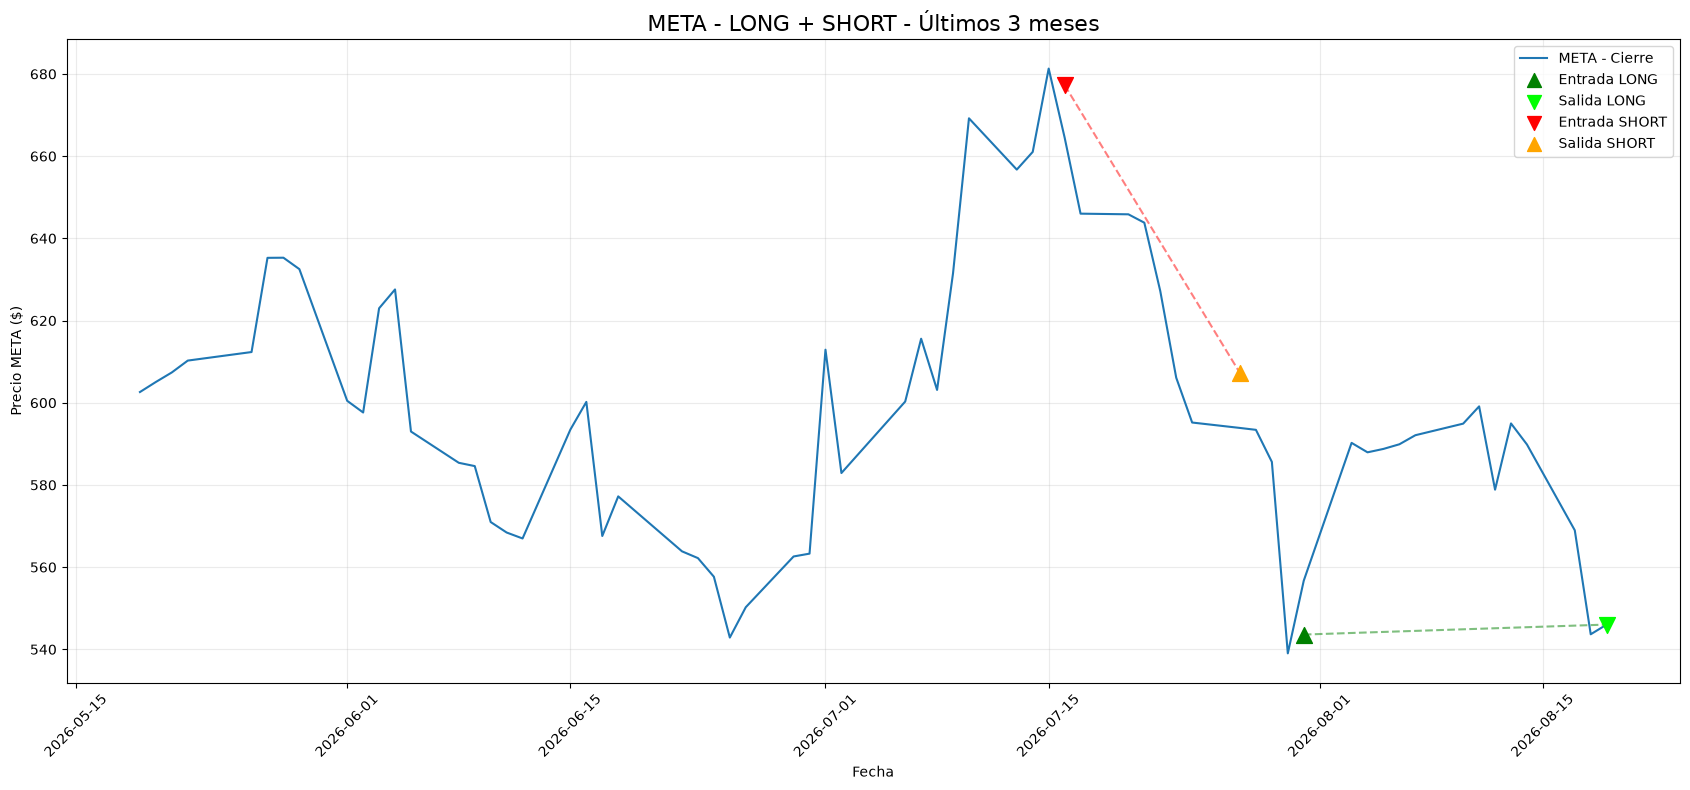

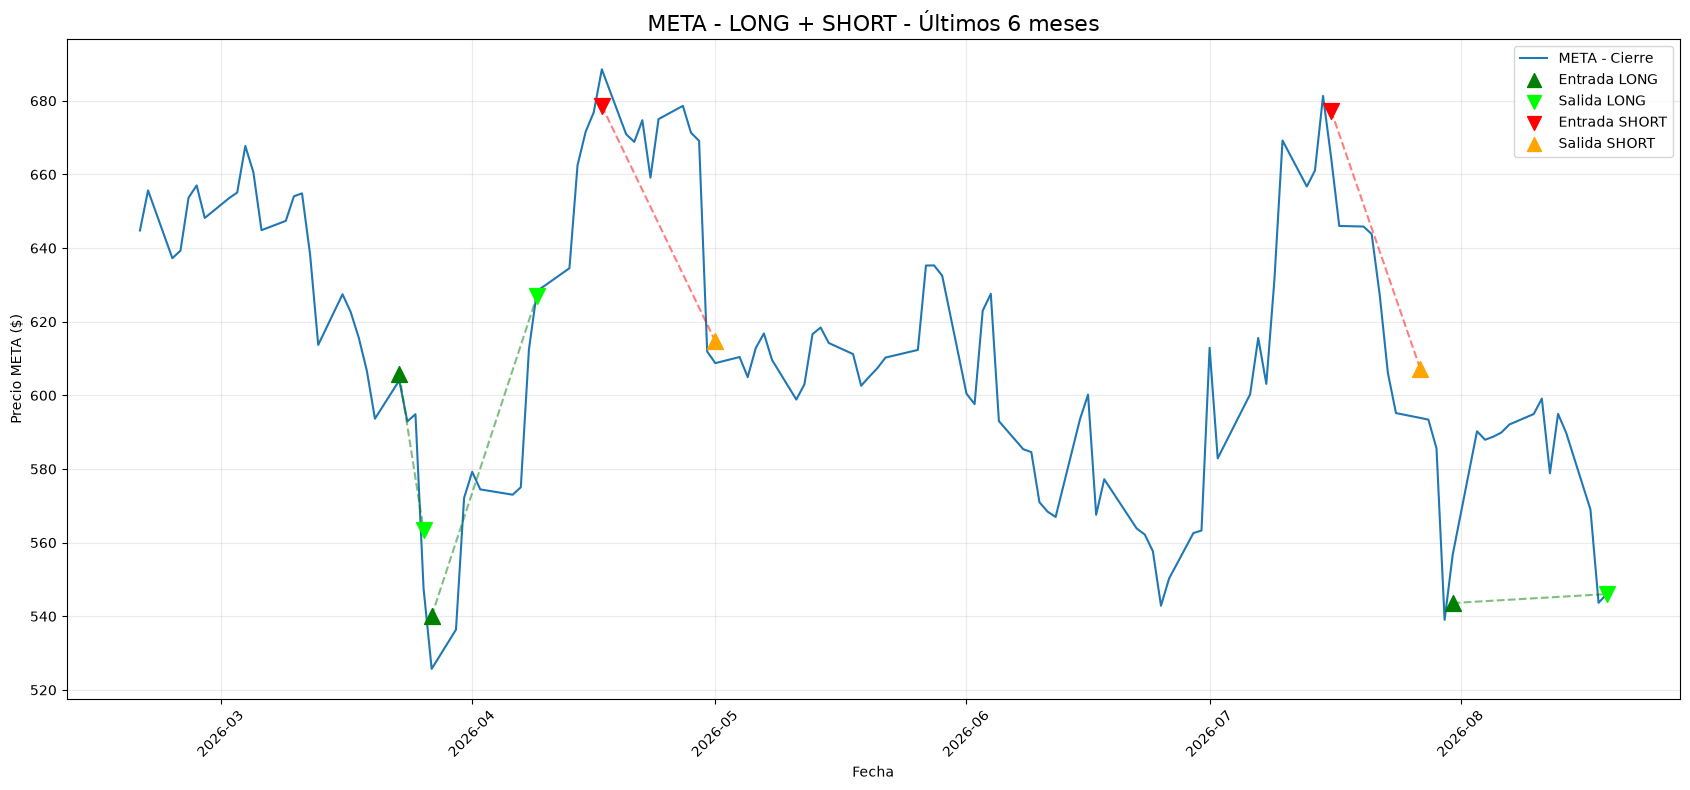

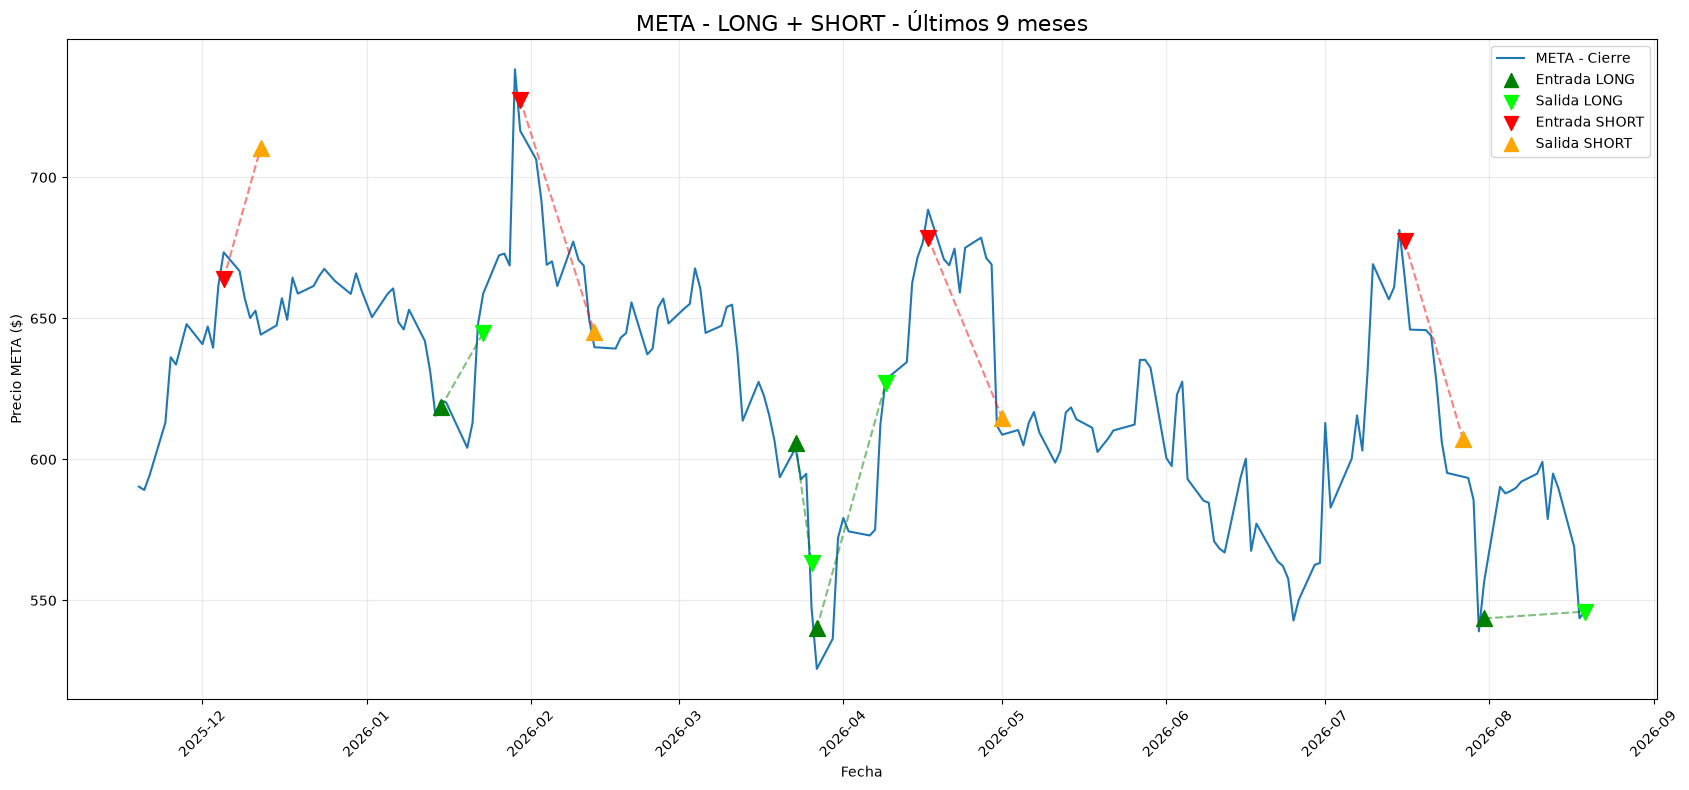

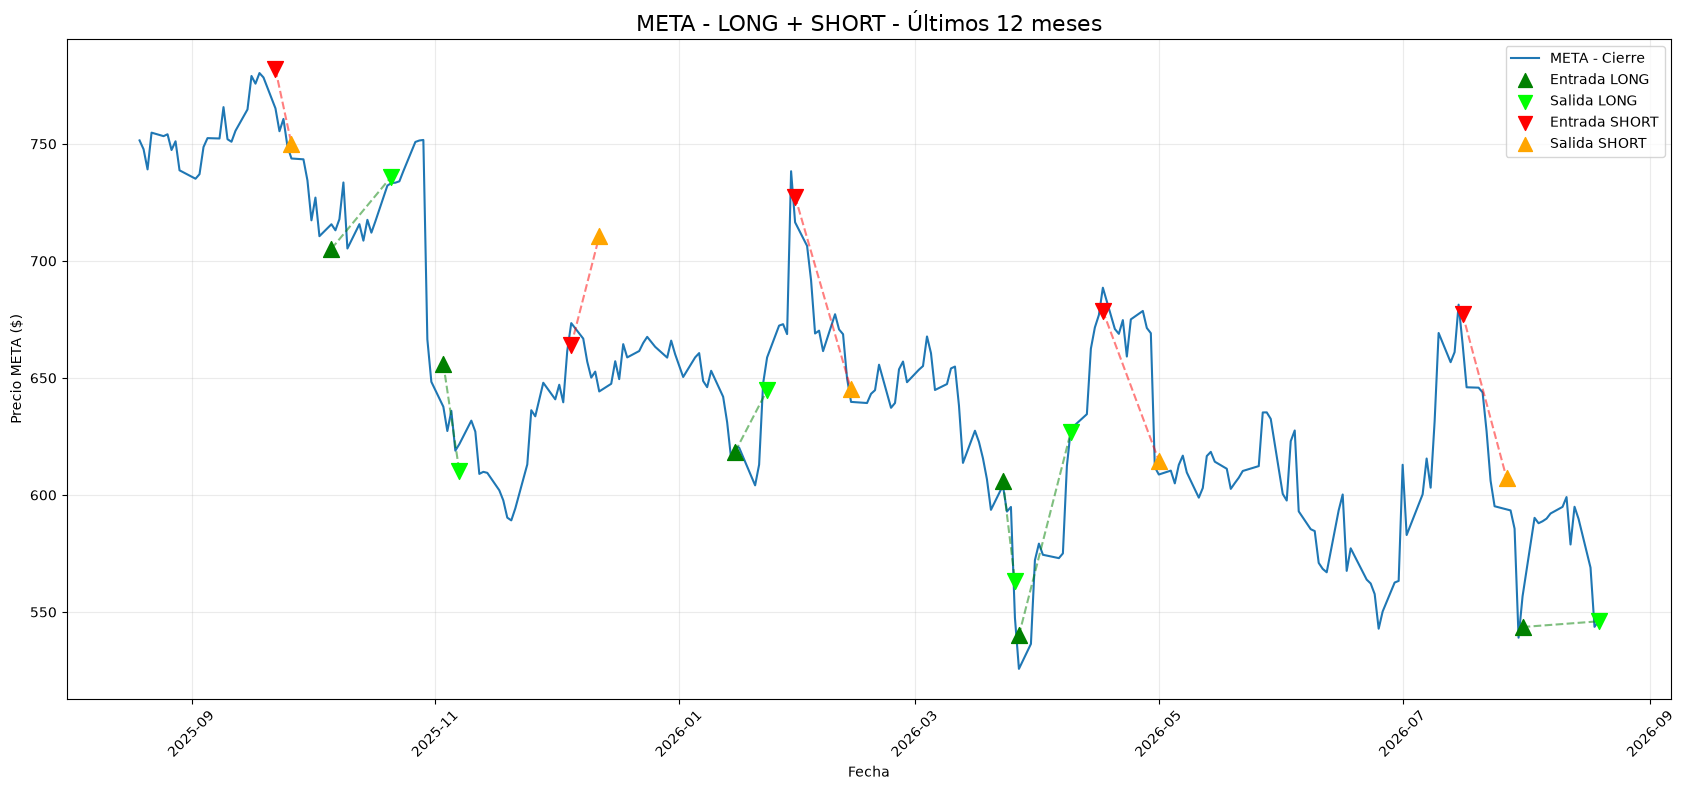

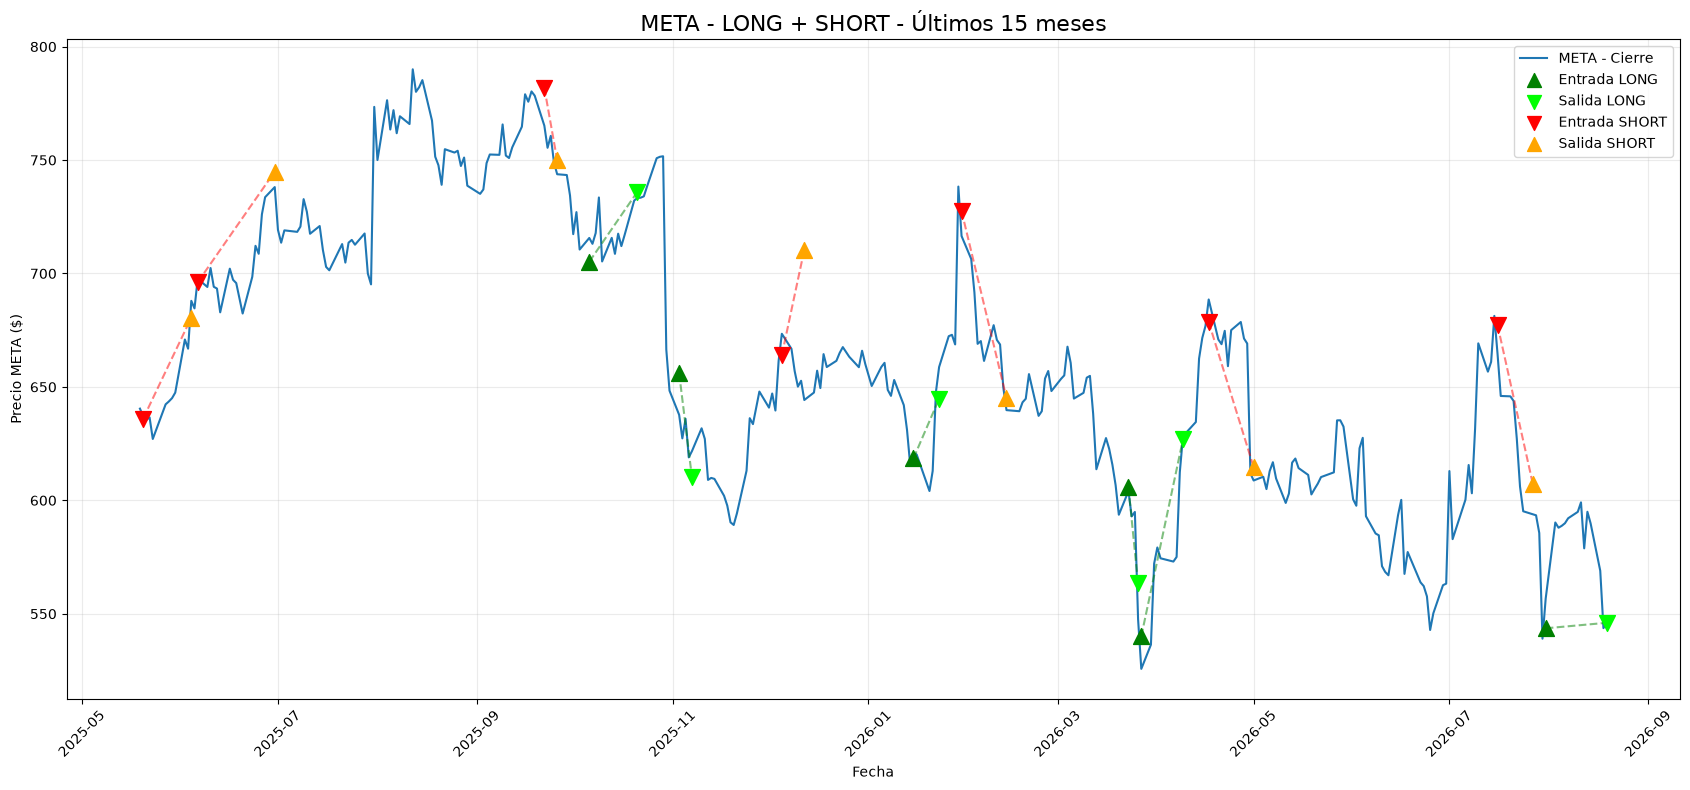

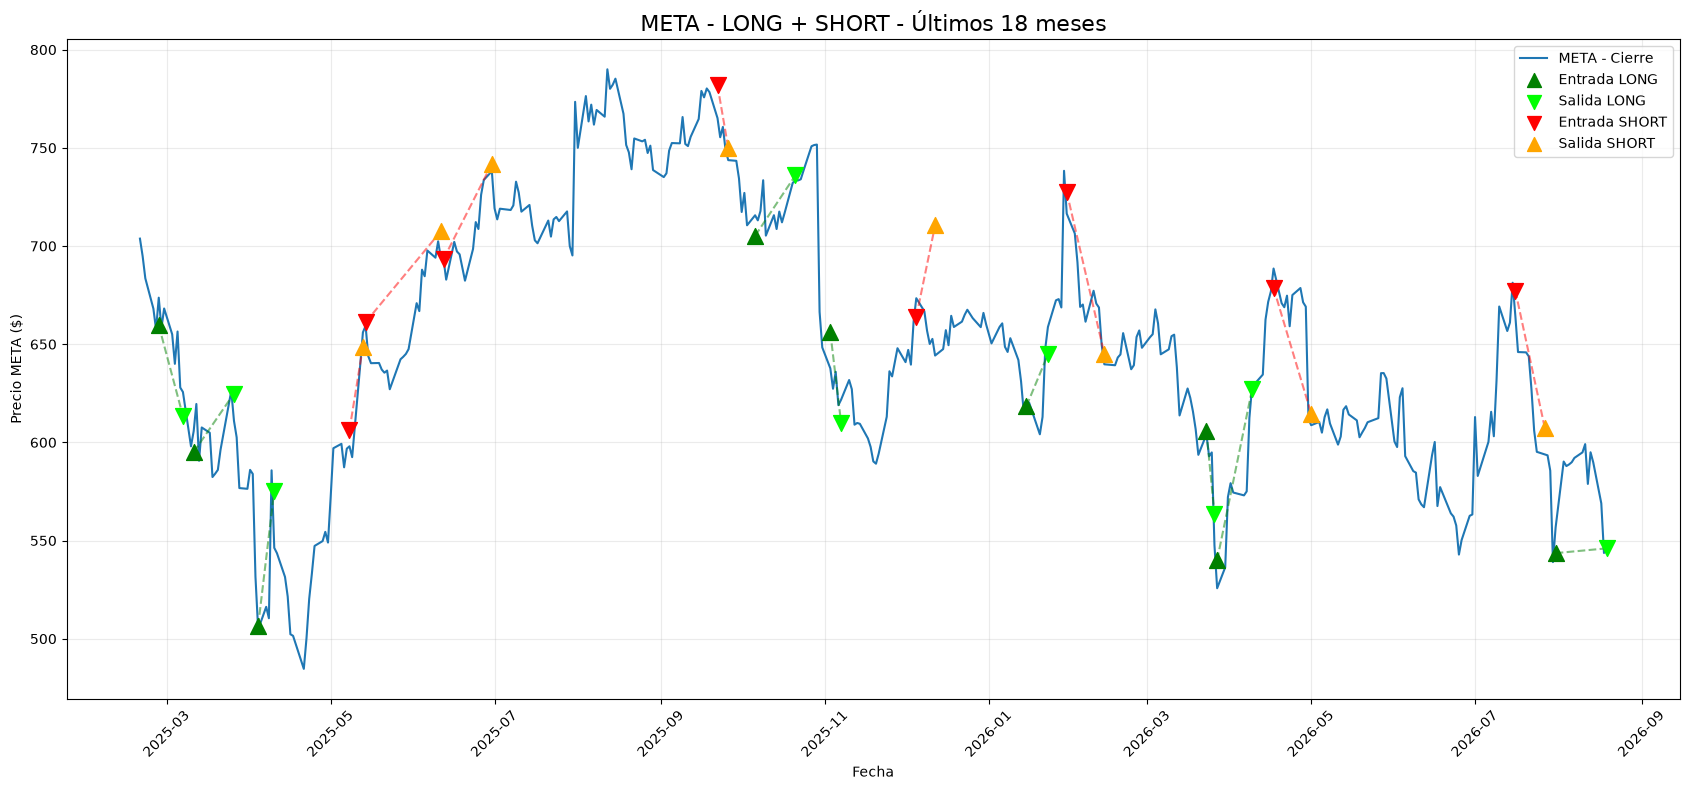

In [ ]:
# ================================================================
# GRÁFICAS DE OPERACIONES LONG / SHORT
# ================================================================

import matplotlib.pyplot as plt


def graficar_operaciones(meses, datos_periodo, operaciones):

    fig, ax = plt.subplots(figsize=(17, 8))

    # ------------------------------------------------------------
    # PRECIO META
    # ------------------------------------------------------------

    ax.plot(
        datos_periodo.index,
        datos_periodo["Close"],
        linewidth=1.5,
        label="META - Cierre"
    )

    # ------------------------------------------------------------
    # RECORRER OPERACIONES
    # ------------------------------------------------------------

    for op in operaciones:

        fecha_entrada = op["Entrada"]
        precio_entrada = op["Precio entrada"]

        fecha_salida = op["Salida"]
        precio_salida = op["Precio salida"]

        tipo = op["Tipo"]


        # ========================================================
        # LONG
        # ========================================================

        if tipo == "LONG":

            # Entrada LONG
            ax.scatter(
                fecha_entrada,
                precio_entrada,
                color="green",
                marker="^",
                s=130,
                zorder=5
            )

            # Salida LONG
            ax.scatter(
                fecha_salida,
                precio_salida,
                color="lime",
                marker="v",
                s=130,
                zorder=5
            )

            # Línea entre entrada y salida
            ax.plot(
                [fecha_entrada, fecha_salida],
                [precio_entrada, precio_salida],
                color="green",
                linestyle="--",
                alpha=0.5
            )


        # ========================================================
        # SHORT
        # ========================================================

        elif tipo == "SHORT":

            # Entrada SHORT
            ax.scatter(
                fecha_entrada,
                precio_entrada,
                color="red",
                marker="v",
                s=130,
                zorder=5
            )

            # Salida SHORT
            ax.scatter(
                fecha_salida,
                precio_salida,
                color="orange",
                marker="^",
                s=130,
                zorder=5
            )

            # Línea entre entrada y salida
            ax.plot(
                [fecha_entrada, fecha_salida],
                [precio_entrada, precio_salida],
                color="red",
                linestyle="--",
                alpha=0.5
            )


    # ------------------------------------------------------------
    # LEYENDA PERSONALIZADA
    # ------------------------------------------------------------

    ax.scatter(
        [], [],
        color="green",
        marker="^",
        s=100,
        label="Entrada LONG"
    )

    ax.scatter(
        [], [],
        color="lime",
        marker="v",
        s=100,
        label="Salida LONG"
    )

    ax.scatter(
        [], [],
        color="red",
        marker="v",
        s=100,
        label="Entrada SHORT"
    )

    ax.scatter(
        [], [],
        color="orange",
        marker="^",
        s=100,
        label="Salida SHORT"
    )


    # ------------------------------------------------------------
    # FORMATO
    # ------------------------------------------------------------

    ax.set_title(
        f"META - LONG + SHORT - Últimos {meses} meses",
        fontsize=16
    )

    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio META ($)")

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend(
        loc="best"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


# ================================================================
# GENERAR GRÁFICAS PARA TODAS LAS VENTANAS
# ================================================================

for meses in VENTANAS:

    if meses not in resultados:
        continue

    datos_periodo = resultados[meses]["datos"]

    operaciones = resultados[
        meses
    ]["resultado"]["Operaciones detalle"]

    graficar_operaciones(
        meses,
        datos_periodo,
        operaciones
    )


META - LONG ORIGINAL + SHORT MEJORADO (RSI > 70 + RUPTURA 20 DÍAS + VOLUMEN)

 Periodo Capital final Rentabilidad % Buy & Hold % Diferencia vs B&H % Drawdown máximo %  Operaciones % Aciertos  Short RSI  Short ruptura
 3 meses    $11,083.76        +10.84%       -9.39%             +20.23%            -9.26%            2     100.0%          1              0
 6 meses    $13,855.38        +38.55%      -15.32%             +53.87%            -9.26%            6      66.7%          2              2
 9 meses    $15,103.10        +51.03%       -7.50%             +58.53%           -10.70%           11      72.7%          4              4
12 meses    $15,522.89        +55.23%      -27.34%             +82.57%           -16.27%           16      68.8%          5              6
15 meses    $13,425.75        +34.26%      -14.74%             +49.00%           -20.09%           18      61.1%          7              6
18 meses    $13,851.92        +38.52%      -22.41%             +60.93%           -26.31

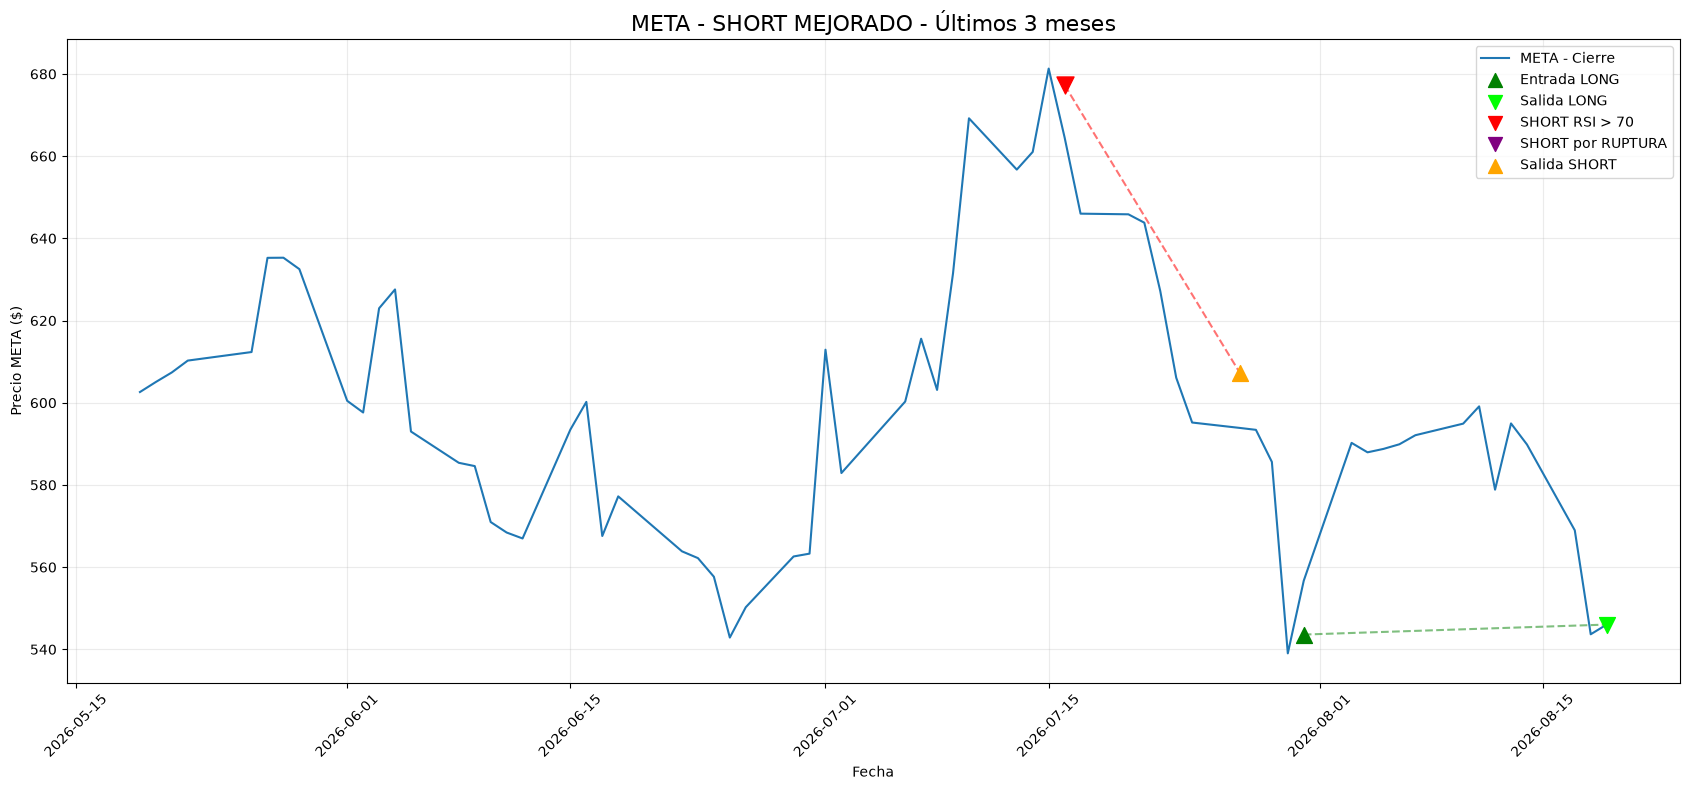

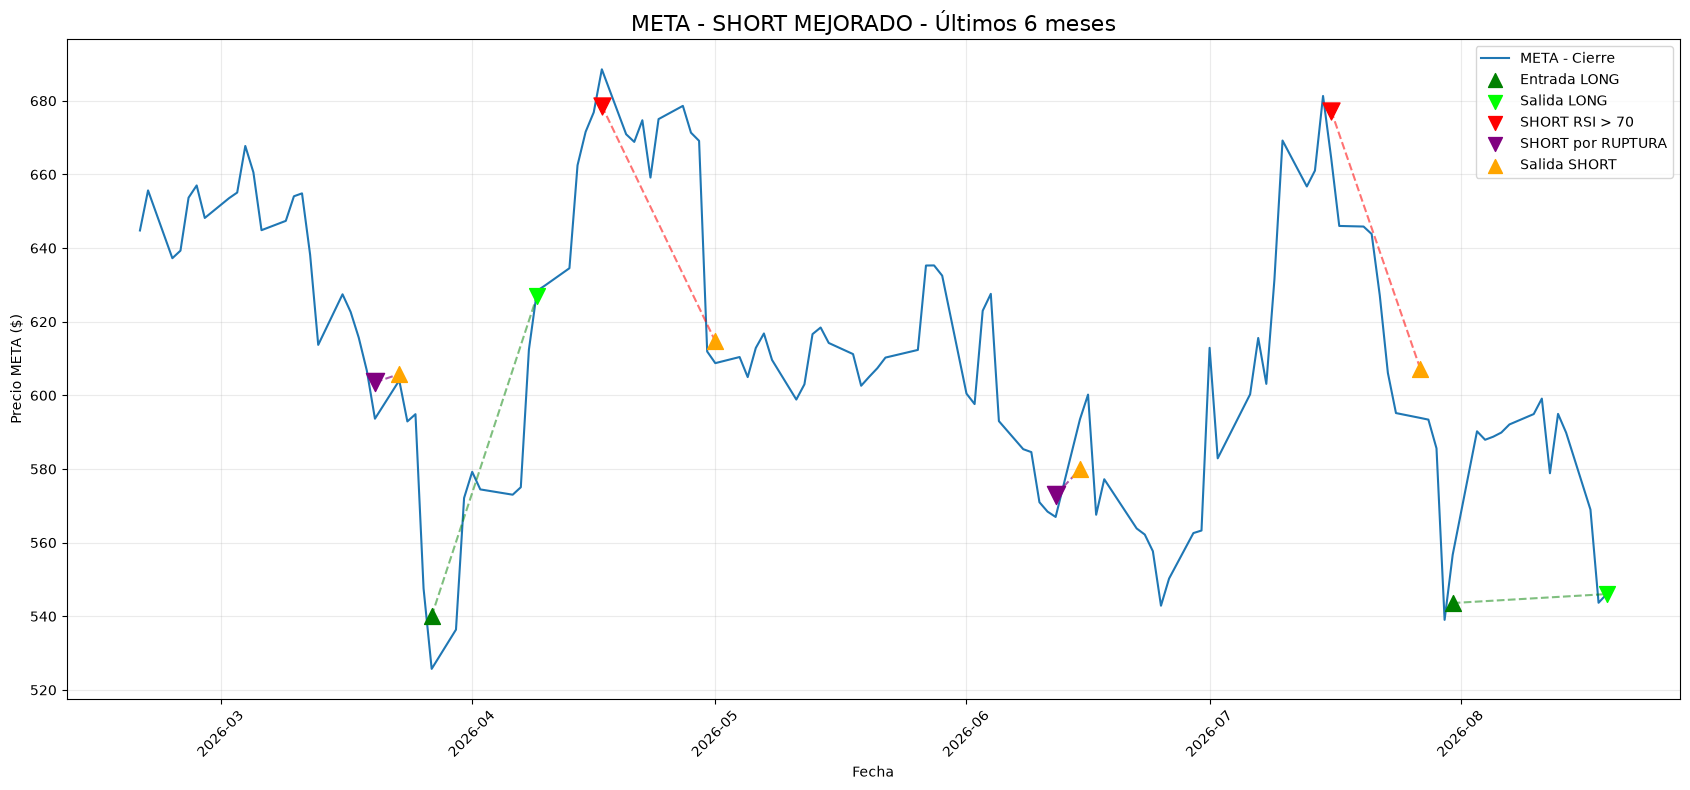

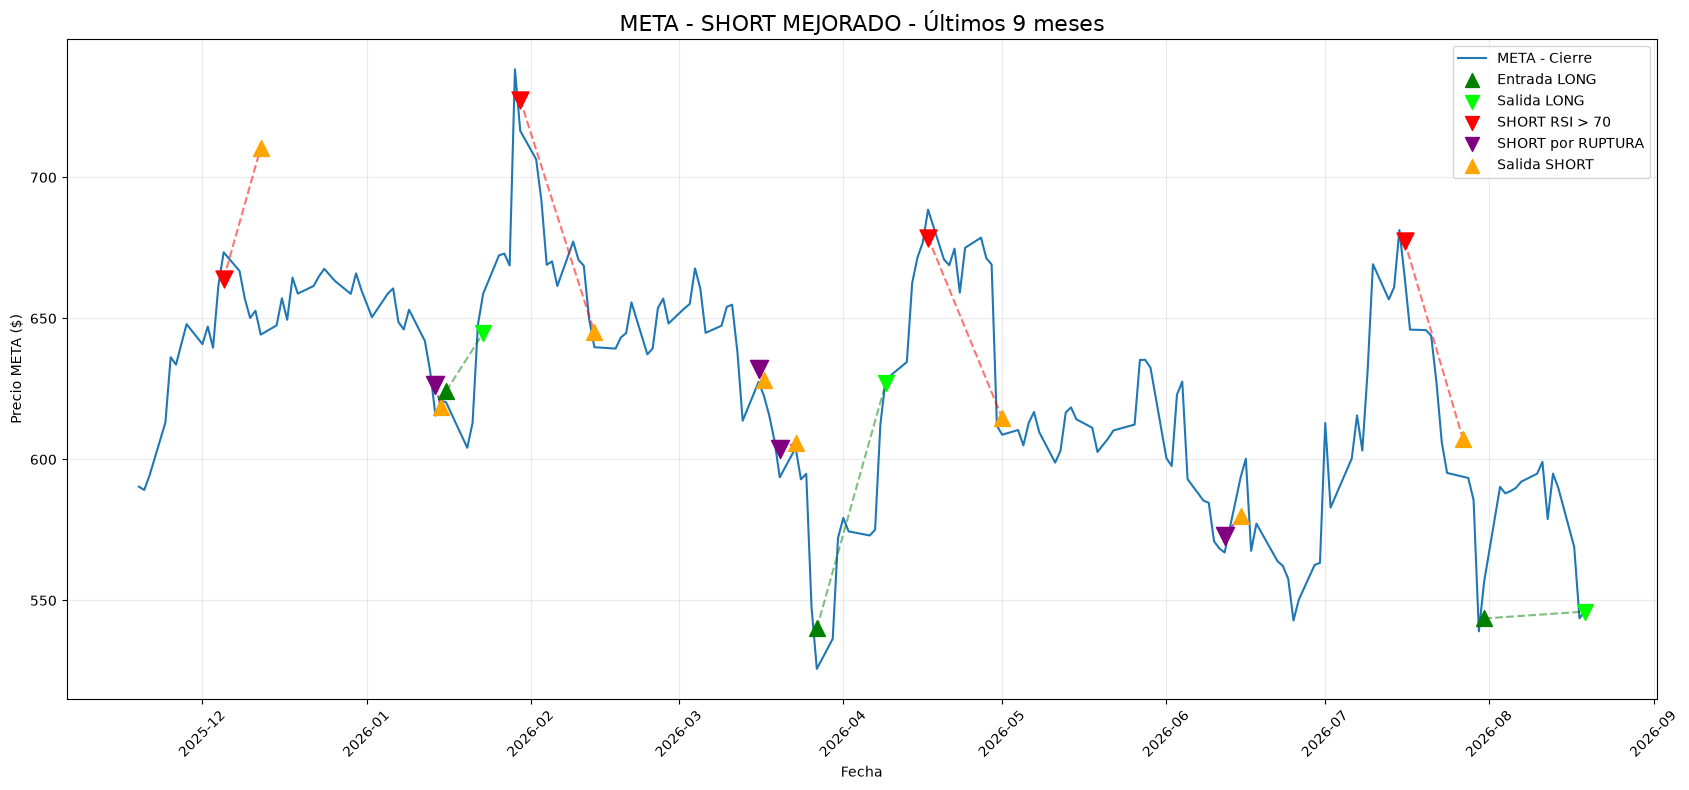

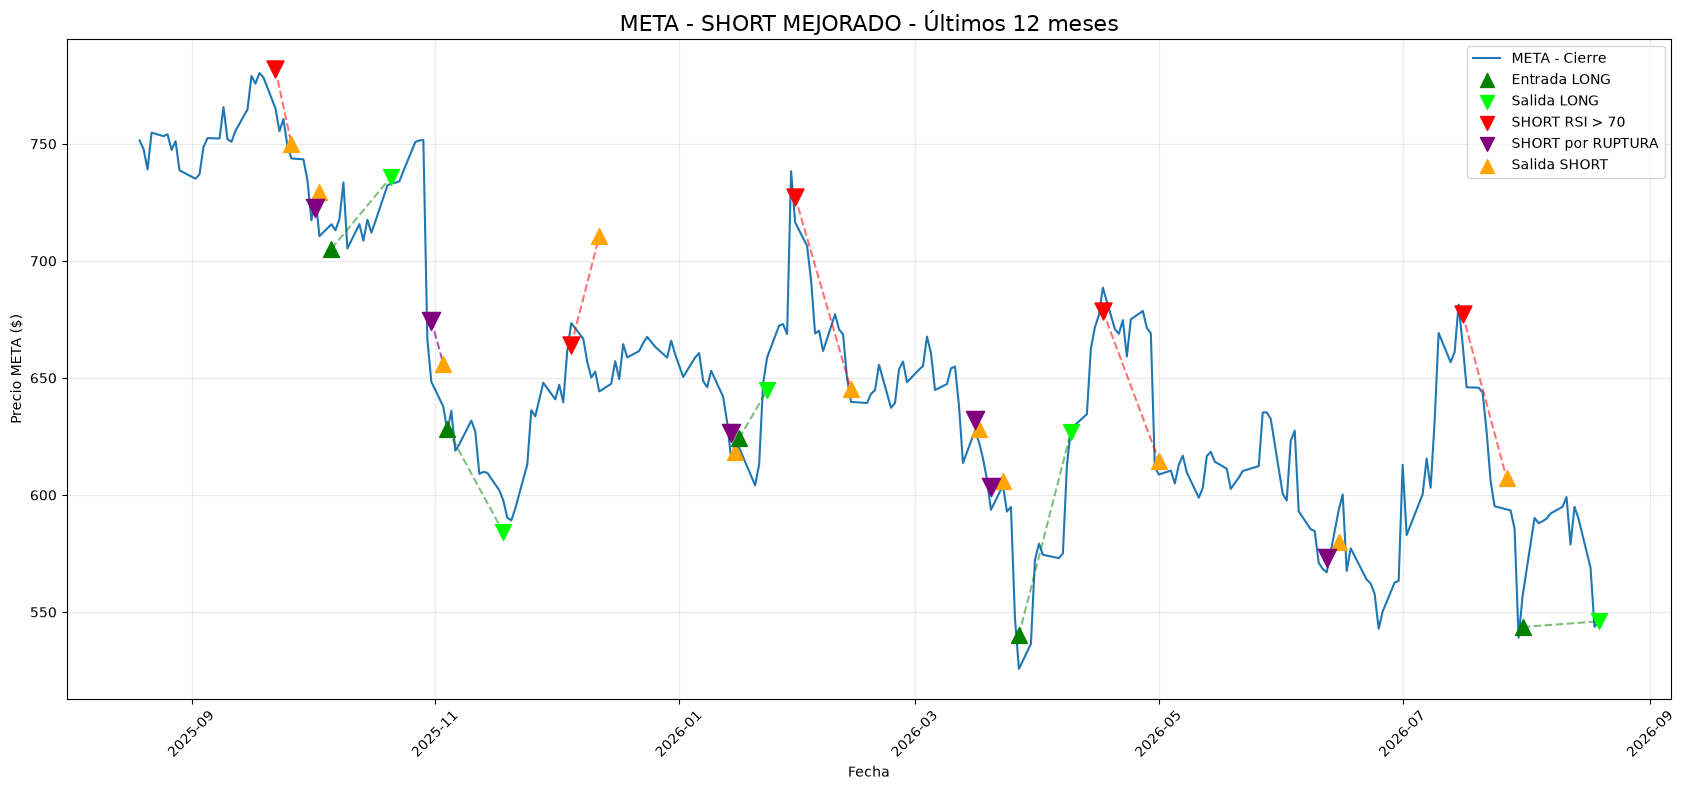

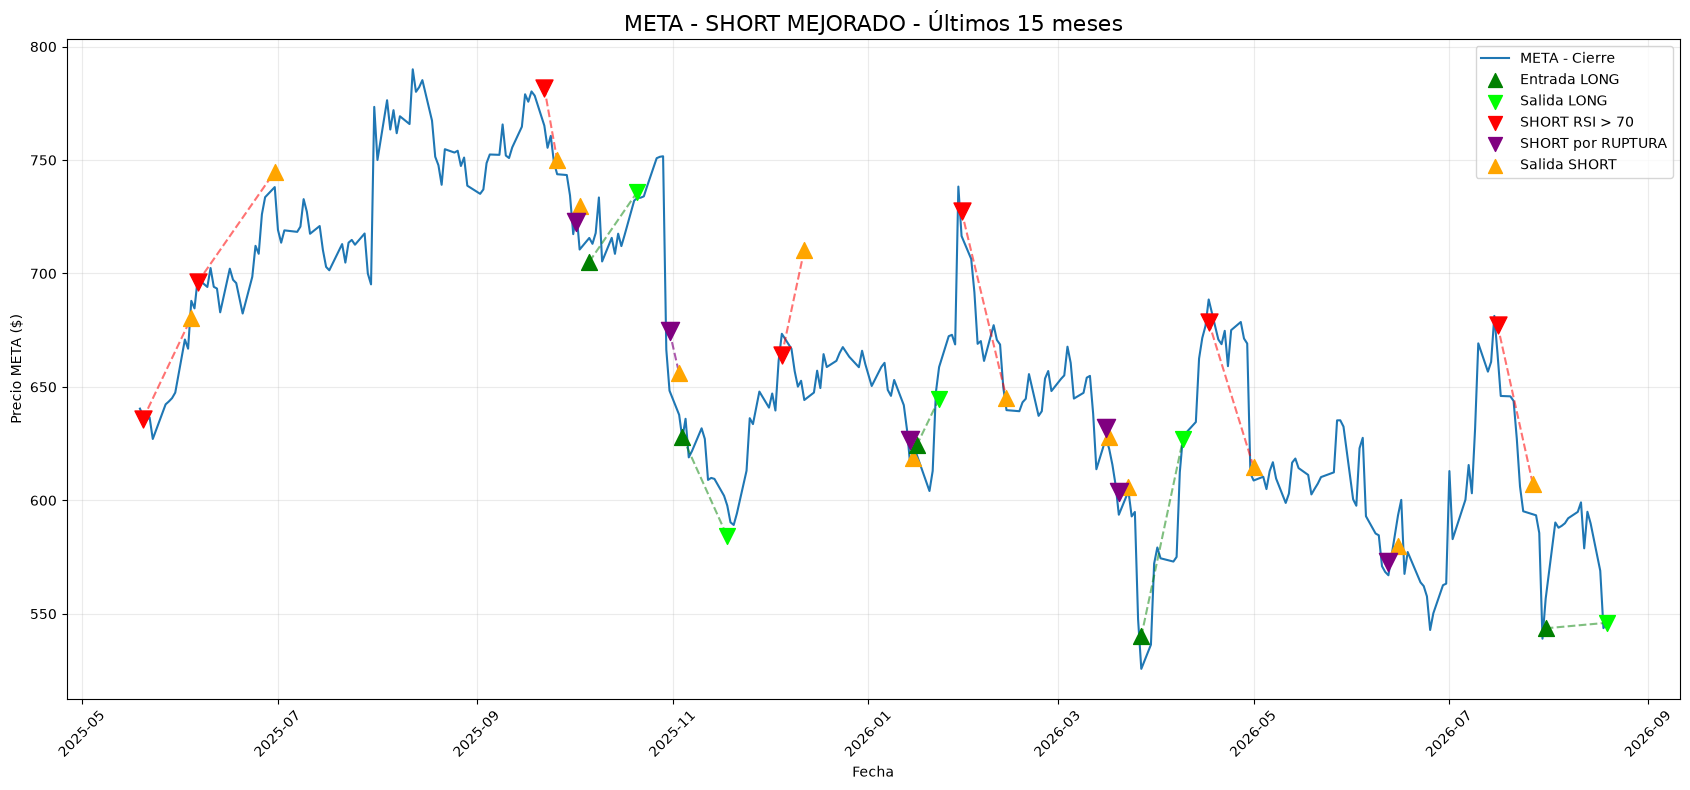

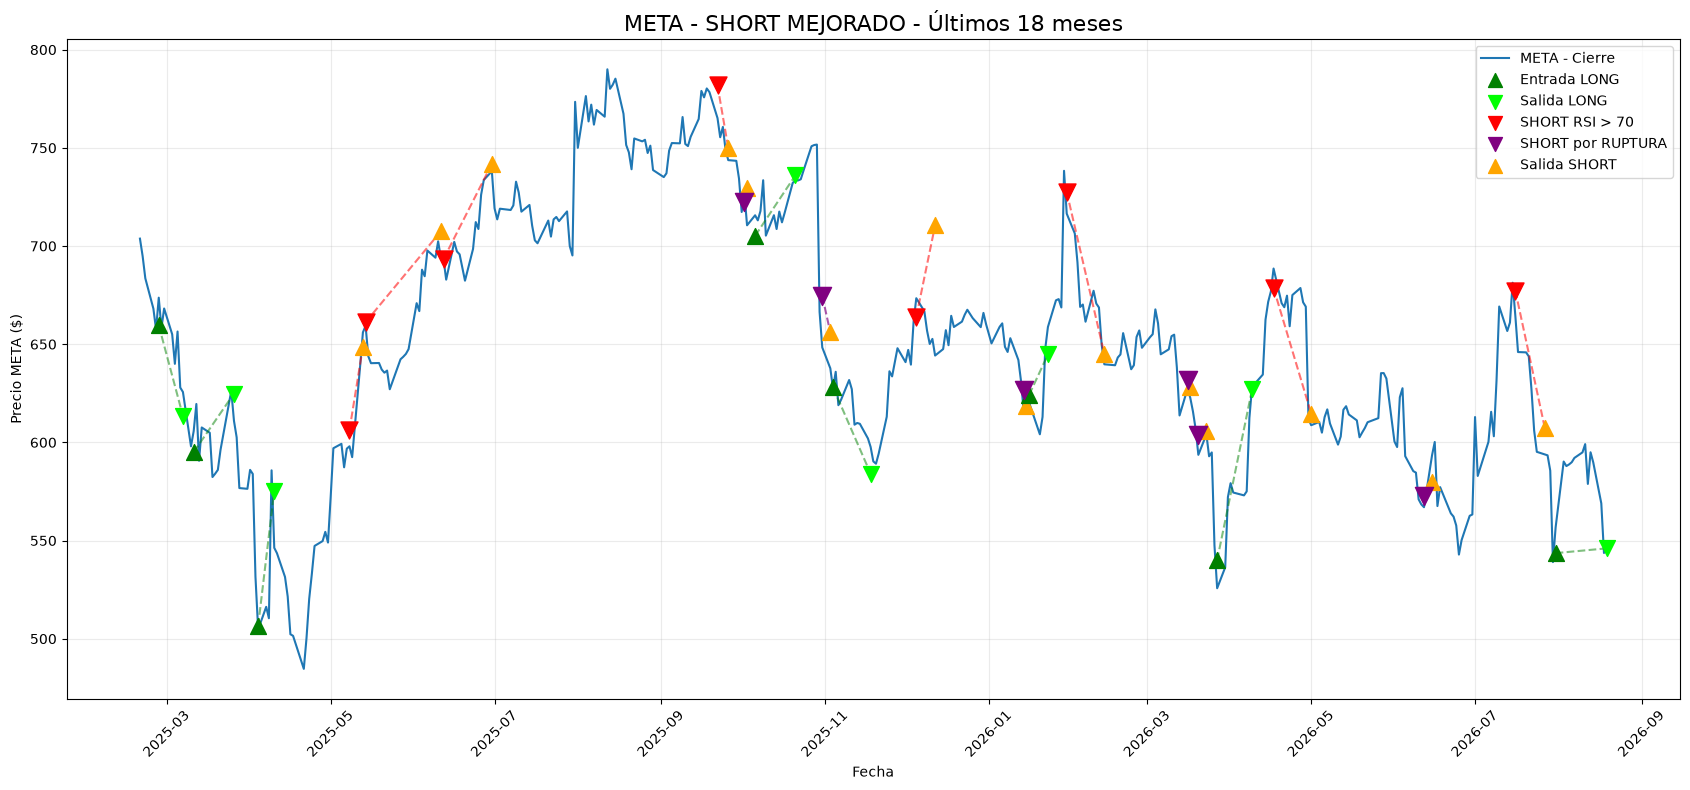


LEYENDA
▲ VERDE    = entrada LONG
▼ VERDE    = salida LONG
▼ ROJO     = entrada SHORT por RSI > 70
▼ MORADO   = entrada SHORT por ruptura bajista
▲ NARANJA  = salida SHORT

SHORT mejorado:
1) Sobrecompra RSI > 70
2) Ruptura mínimo 20 sesiones + volumen


In [ ]:
# =====================================================================
# 📉 META - SHORT MEJORADO ( Version donde meto otro tipo de short.. para detectar bajadas bruscas)
# =====================================================================
#
# Mantiene:
#
# LONG:
#   RSI < 30 + cierre <= Bollinger inferior
#
# SHORT:
#   MÉTODO A -> RSI > 70
#
#   MÉTODO B -> RUPTURA BAJISTA:
#       cierre < mínimo de las 20 sesiones ANTERIORES
#       +
#       volumen > volumen medio de las 20 sesiones ANTERIORES
#
# Señal al cierre -> ejecución en apertura del día siguiente
#
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta


# =====================================================================
# CONFIGURACIÓN SHORT MEJORADO
# =====================================================================

PERIODO_RUPTURA = 20

MULTIPLICADOR_VOLUMEN = 1.00

STOP_LONG_MEJORADO = 0.07
STOP_SHORT_MEJORADO = 0.07


# =====================================================================
# PREPARAR SEÑALES MEJORADAS
# =====================================================================

def preparar_senales_short_mejorado(df):

    d = df.copy()


    # -----------------------------------------------------------------
    # LONG
    # -----------------------------------------------------------------
    # Lo dejamos EXACTAMENTE igual que en el algoritmo anterior
    # -----------------------------------------------------------------

    d["LONG_ENTRY"] = (
        (d["RSI"] < 30) &
        (d["Close"] <= d["BB_LOWER"])
    )


    d["LONG_EXIT"] = (
        (d["RSI"] >= 65) |
        (d["Close"] >= d["BB_MIDDLE"])
    )


    # =================================================================
    # SHORT MÉTODO A
    # SOBRECOMPRA
    # =================================================================

    d["SHORT_RSI"] = (
        d["RSI"] > 70
    )


    # =================================================================
    # SHORT MÉTODO B
    # RUPTURA BAJISTA
    # =================================================================
    #
    # IMPORTANTE:
    #
    # shift(1)
    #
    # significa que NO incluimos el día actual.
    #
    # Estamos comparando el cierre de hoy contra
    # los mínimos de los 20 días ANTERIORES.
    #
    # =================================================================


    d["MINIMO_20_PREV"] = (
        d["Low"]
        .rolling(PERIODO_RUPTURA)
        .min()
        .shift(1)
    )


    d["VOLUMEN_MEDIO_20_PREV"] = (
        d["Volume"]
        .rolling(PERIODO_RUPTURA)
        .mean()
        .shift(1)
    )


    d["SHORT_RUPTURA"] = (

        # Rompe el mínimo de las últimas 20 sesiones
        (d["Close"] < d["MINIMO_20_PREV"])

        &

        # Volumen superior a la media
        (
            d["Volume"]
            >
            d["VOLUMEN_MEDIO_20_PREV"]
            * MULTIPLICADOR_VOLUMEN
        )
    )


    # =================================================================
    # ENTRADA SHORT TOTAL
    # =================================================================

    d["SHORT_ENTRY"] = (
        d["SHORT_RSI"]
        |
        d["SHORT_RUPTURA"]
    )


    # =================================================================
    # SALIDA SHORT
    # =================================================================
    #
    # Mantenemos por ahora la salida original:
    #
    # RSI < 50
    #
    # Primero queremos comprobar si mejorar LA ENTRADA
    # realmente mejora el algoritmo.
    #
    # =================================================================

    d["SHORT_EXIT"] = (
        d["RSI"] < 50
    )


    return d


# =====================================================================
# BACKTEST SHORT MEJORADO
# =====================================================================

def ejecutar_backtest_short_mejorado(
    df,
    capital_inicial=10000
):

    d = preparar_senales_short_mejorado(df)

    capital = capital_inicial

    posicion = None

    precio_entrada = None
    fecha_entrada = None

    tipo_entrada_short = None

    operaciones = []
    equity = []


    # =================================================================
    # RECORRER SESIONES
    # =================================================================

    for i in range(1, len(d)):

        fecha = d.index[i]

        fila = d.iloc[i]

        apertura = float(fila["Open"])
        maximo = float(fila["High"])
        minimo = float(fila["Low"])
        cierre = float(fila["Close"])


        # =============================================================
        # SIN POSICIÓN
        # =============================================================

        if posicion is None:

            señal_anterior = d.iloc[i - 1]


            # ---------------------------------------------------------
            # ENTRADA LONG
            # ---------------------------------------------------------

            if bool(señal_anterior["LONG_ENTRY"]):

                posicion = "LONG"

                precio_entrada = apertura
                fecha_entrada = fecha

                tipo_entrada_short = None


            # ---------------------------------------------------------
            # ENTRADA SHORT
            # ---------------------------------------------------------

            elif bool(señal_anterior["SHORT_ENTRY"]):

                posicion = "SHORT"

                precio_entrada = apertura
                fecha_entrada = fecha


                # -----------------------------------------------------
                # Guardamos POR QUÉ ha entrado SHORT
                # -----------------------------------------------------

                if bool(señal_anterior["SHORT_RUPTURA"]):

                    tipo_entrada_short = "RUPTURA"

                elif bool(señal_anterior["SHORT_RSI"]):

                    tipo_entrada_short = "RSI > 70"

                else:

                    tipo_entrada_short = "SHORT"


        # =============================================================
        # POSICIÓN LONG
        # =============================================================

        elif posicion == "LONG":

            stop = (
                precio_entrada
                * (1 - STOP_LONG_MEJORADO)
            )

            salida = None
            motivo = None


            # ---------------------------------------------------------
            # STOP LOSS
            # ---------------------------------------------------------

            if minimo <= stop:

                salida = stop
                motivo = "STOP LOSS LONG"


            # ---------------------------------------------------------
            # SALIDA POR SEÑAL
            # ---------------------------------------------------------

            elif bool(d.iloc[i - 1]["LONG_EXIT"]):

                salida = apertura
                motivo = "SEÑAL SALIDA LONG"


            # ---------------------------------------------------------
            # CERRAR OPERACIÓN
            # ---------------------------------------------------------

            if salida is not None:

                rentabilidad = (
                    (salida - precio_entrada)
                    / precio_entrada
                )


                capital *= (
                    1 + rentabilidad
                )


                operaciones.append({

                    "Tipo":
                        "LONG",

                    "Sistema entrada":
                        "RSI + BOLLINGER",

                    "Entrada":
                        fecha_entrada,

                    "Precio entrada":
                        precio_entrada,

                    "Salida":
                        fecha,

                    "Precio salida":
                        salida,

                    "Rentabilidad %":
                        rentabilidad * 100,

                    "Motivo":
                        motivo

                })


                posicion = None

                precio_entrada = None
                fecha_entrada = None


        # =============================================================
        # POSICIÓN SHORT
        # =============================================================

        elif posicion == "SHORT":

            stop = (
                precio_entrada
                * (1 + STOP_SHORT_MEJORADO)
            )

            salida = None
            motivo = None


            # ---------------------------------------------------------
            # STOP LOSS SHORT
            # ---------------------------------------------------------

            if maximo >= stop:

                salida = stop

                motivo = "STOP LOSS SHORT"


            # ---------------------------------------------------------
            # SALIDA SHORT
            # ---------------------------------------------------------

            elif bool(d.iloc[i - 1]["SHORT_EXIT"]):

                salida = apertura

                motivo = "SEÑAL SALIDA SHORT"


            # ---------------------------------------------------------
            # CERRAR SHORT
            # ---------------------------------------------------------

            if salida is not None:

                rentabilidad = (
                    (precio_entrada - salida)
                    / precio_entrada
                )


                capital *= (
                    1 + rentabilidad
                )


                operaciones.append({

                    "Tipo":
                        "SHORT",

                    "Sistema entrada":
                        tipo_entrada_short,

                    "Entrada":
                        fecha_entrada,

                    "Precio entrada":
                        precio_entrada,

                    "Salida":
                        fecha,

                    "Precio salida":
                        salida,

                    "Rentabilidad %":
                        rentabilidad * 100,

                    "Motivo":
                        motivo

                })


                posicion = None

                precio_entrada = None
                fecha_entrada = None
                tipo_entrada_short = None


        # =============================================================
        # EQUITY
        # =============================================================

        if posicion == "LONG":

            rent_actual = (
                (cierre - precio_entrada)
                / precio_entrada
            )

            valor = (
                capital
                * (1 + rent_actual)
            )


        elif posicion == "SHORT":

            rent_actual = (
                (precio_entrada - cierre)
                / precio_entrada
            )

            valor = (
                capital
                * (1 + rent_actual)
            )


        else:

            valor = capital


        equity.append({

            "Fecha":
                fecha,

            "Equity":
                valor

        })


    # =================================================================
    # CERRAR POSICIÓN AL FINAL DEL PERIODO
    # =================================================================

    if posicion is not None:

        precio_salida = float(
            d["Close"].iloc[-1]
        )

        fecha_salida = d.index[-1]


        if posicion == "LONG":

            rentabilidad = (
                (precio_salida - precio_entrada)
                / precio_entrada
            )

            sistema = "RSI + BOLLINGER"


        else:

            rentabilidad = (
                (precio_entrada - precio_salida)
                / precio_entrada
            )

            sistema = tipo_entrada_short


        capital *= (
            1 + rentabilidad
        )


        operaciones.append({

            "Tipo":
                posicion,

            "Sistema entrada":
                sistema,

            "Entrada":
                fecha_entrada,

            "Precio entrada":
                precio_entrada,

            "Salida":
                fecha_salida,

            "Precio salida":
                precio_salida,

            "Rentabilidad %":
                rentabilidad * 100,

            "Motivo":
                "FIN DEL PERIODO"

        })


    # =================================================================
    # DRAWDOWN
    # =================================================================

    if equity:

        eq = pd.DataFrame(equity)

        eq["Max"] = (
            eq["Equity"].cummax()
        )

        eq["Drawdown"] = (
            eq["Equity"]
            / eq["Max"]
            - 1
        )

        drawdown_max = (
            eq["Drawdown"].min()
            * 100
        )

    else:

        drawdown_max = 0


    # =================================================================
    # ESTADÍSTICAS
    # =================================================================

    num_operaciones = len(operaciones)


    if num_operaciones > 0:

        aciertos = sum(

            op["Rentabilidad %"] > 0

            for op in operaciones
        )


        porcentaje_aciertos = (

            aciertos
            / num_operaciones
            * 100
        )

    else:

        porcentaje_aciertos = 0


    rentabilidad_total = (

        capital
        / capital_inicial
        - 1

    ) * 100


    return {

        "Capital final":
            capital,

        "Rentabilidad %":
            rentabilidad_total,

        "Drawdown máximo %":
            drawdown_max,

        "Operaciones":
            num_operaciones,

        "% Aciertos":
            porcentaje_aciertos,

        "Operaciones detalle":
            operaciones,

        "Datos señales":
            d

    }


# =====================================================================
# EJECUTAR LAS MISMAS VENTANAS
# =====================================================================

resultados_short_mejorado = {}

filas_mejorado = []

fecha_final = datos.index[-1]


for meses in VENTANAS:

    fecha_inicio = (
        fecha_final
        - relativedelta(months=meses)
    )


    df_periodo = datos[
        datos.index >= fecha_inicio
    ].copy()


    if len(df_periodo) < 60:
        continue


    resultado = ejecutar_backtest_short_mejorado(

        df_periodo,
        CAPITAL_INICIAL
    )


    bh_capital, bh_rentabilidad = (
        calcular_buy_hold(df_periodo)
    )


    diferencia = (
        resultado["Rentabilidad %"]
        - bh_rentabilidad
    )


    resultados_short_mejorado[meses] = {

        "datos":
            df_periodo,

        "resultado":
            resultado,

        "bh_rentabilidad":
            bh_rentabilidad
    }


    # -------------------------------------------------------------
    # CONTAR TIPOS DE SHORT
    # -------------------------------------------------------------

    ops = resultado["Operaciones detalle"]


    shorts_rsi = sum(

        op["Tipo"] == "SHORT"
        and op["Sistema entrada"] == "RSI > 70"

        for op in ops
    )


    shorts_ruptura = sum(

        op["Tipo"] == "SHORT"
        and op["Sistema entrada"] == "RUPTURA"

        for op in ops
    )


    filas_mejorado.append({

        "Periodo":
            f"{meses} meses",

        "Capital final":
            resultado["Capital final"],

        "Rentabilidad %":
            resultado["Rentabilidad %"],

        "Buy & Hold %":
            bh_rentabilidad,

        "Diferencia vs B&H %":
            diferencia,

        "Drawdown máximo %":
            resultado["Drawdown máximo %"],

        "Operaciones":
            resultado["Operaciones"],

        "% Aciertos":
            resultado["% Aciertos"],

        "Short RSI":
            shorts_rsi,

        "Short ruptura":
            shorts_ruptura

    })


# =====================================================================
# TABLA RESULTADOS
# =====================================================================

df_short_mejorado = pd.DataFrame(
    filas_mejorado
)


print()

print("=" * 140)

print(
    "META - LONG ORIGINAL + SHORT MEJORADO "
    "(RSI > 70 + RUPTURA 20 DÍAS + VOLUMEN)"
)

print("=" * 140)

print()


print(

    df_short_mejorado.to_string(

        index=False,

        formatters={

            "Capital final":
                "${:,.2f}".format,

            "Rentabilidad %":
                "{:+.2f}%".format,

            "Buy & Hold %":
                "{:+.2f}%".format,

            "Diferencia vs B&H %":
                "{:+.2f}%".format,

            "Drawdown máximo %":
                "{:+.2f}%".format,

            "% Aciertos":
                "{:.1f}%".format
        }
    )
)


# =====================================================================
# DETALLE DE OPERACIONES
# =====================================================================

for meses in VENTANAS:

    if meses not in resultados_short_mejorado:
        continue


    print()
    print("=" * 130)

    print(
        f"OPERACIONES SHORT MEJORADO - "
        f"ÚLTIMOS {meses} MESES"
    )

    print("=" * 130)


    ops = (
        resultados_short_mejorado[meses]
        ["resultado"]
        ["Operaciones detalle"]
    )


    if not ops:

        print("No hubo operaciones.")

        continue


    df_ops = pd.DataFrame(ops)


    print(

        df_ops.to_string(

            index=False,

            formatters={

                "Precio entrada":
                    "${:,.2f}".format,

                "Precio salida":
                    "${:,.2f}".format,

                "Rentabilidad %":
                    "{:+.2f}%".format

            }
        )
    )


# =====================================================================
# GRÁFICAS
# =====================================================================

def graficar_short_mejorado(
    meses,
    datos_periodo,
    operaciones
):

    fig, ax = plt.subplots(
        figsize=(17, 8)
    )


    # -----------------------------------------------------------------
    # PRECIO
    # -----------------------------------------------------------------

    ax.plot(

        datos_periodo.index,
        datos_periodo["Close"],

        linewidth=1.5,

        label="META - Cierre"
    )


    # =================================================================
    # OPERACIONES
    # =================================================================

    for op in operaciones:

        fe = op["Entrada"]
        pe = op["Precio entrada"]

        fs = op["Salida"]
        ps = op["Precio salida"]


        # -------------------------------------------------------------
        # LONG
        # -------------------------------------------------------------

        if op["Tipo"] == "LONG":

            ax.scatter(
                fe,
                pe,
                color="green",
                marker="^",
                s=130,
                zorder=5
            )


            ax.scatter(
                fs,
                ps,
                color="lime",
                marker="v",
                s=130,
                zorder=5
            )


            ax.plot(

                [fe, fs],
                [pe, ps],

                color="green",
                linestyle="--",
                alpha=0.5
            )


        # -------------------------------------------------------------
        # SHORT RSI
        # -------------------------------------------------------------

        elif op["Sistema entrada"] == "RSI > 70":

            ax.scatter(

                fe,
                pe,

                color="red",
                marker="v",
                s=150,
                zorder=6
            )


            ax.scatter(

                fs,
                ps,

                color="orange",
                marker="^",
                s=130,
                zorder=5
            )


            ax.plot(

                [fe, fs],
                [pe, ps],

                color="red",
                linestyle="--",
                alpha=0.55
            )


        # -------------------------------------------------------------
        # SHORT RUPTURA
        # -------------------------------------------------------------

        elif op["Sistema entrada"] == "RUPTURA":

            ax.scatter(

                fe,
                pe,

                color="purple",
                marker="v",
                s=170,
                zorder=7
            )


            ax.scatter(

                fs,
                ps,

                color="orange",
                marker="^",
                s=130,
                zorder=5
            )


            ax.plot(

                [fe, fs],
                [pe, ps],

                color="purple",
                linestyle="--",
                alpha=0.65
            )


    # =================================================================
    # LEYENDA
    # =================================================================

    ax.scatter(
        [], [],
        color="green",
        marker="^",
        s=100,
        label="Entrada LONG"
    )


    ax.scatter(
        [], [],
        color="lime",
        marker="v",
        s=100,
        label="Salida LONG"
    )


    ax.scatter(
        [], [],
        color="red",
        marker="v",
        s=100,
        label="SHORT RSI > 70"
    )


    ax.scatter(
        [], [],
        color="purple",
        marker="v",
        s=100,
        label="SHORT por RUPTURA"
    )


    ax.scatter(
        [], [],
        color="orange",
        marker="^",
        s=100,
        label="Salida SHORT"
    )


    ax.set_title(

        f"META - SHORT MEJORADO - "
        f"Últimos {meses} meses",

        fontsize=16
    )


    ax.set_xlabel("Fecha")

    ax.set_ylabel(
        "Precio META ($)"
    )


    ax.grid(
        True,
        alpha=0.25
    )


    ax.legend(
        loc="best"
    )


    plt.xticks(
        rotation=45
    )


    plt.tight_layout()

    plt.show()


# =====================================================================
# CREAR TODAS LAS GRÁFICAS
# =====================================================================

for meses in VENTANAS:

    if meses not in resultados_short_mejorado:
        continue


    datos_periodo = (
        resultados_short_mejorado[meses]
        ["datos"]
    )


    operaciones = (
        resultados_short_mejorado[meses]
        ["resultado"]
        ["Operaciones detalle"]
    )


    graficar_short_mejorado(

        meses,
        datos_periodo,
        operaciones
    )


print()
print("=" * 120)
print("LEYENDA")
print("=" * 120)

print("▲ VERDE    = entrada LONG")
print("▼ VERDE    = salida LONG")

print("▼ ROJO     = entrada SHORT por RSI > 70")
print("▼ MORADO   = entrada SHORT por ruptura bajista")
print("▲ NARANJA  = salida SHORT")

print()
print("SHORT mejorado:")
print("1) Sobrecompra RSI > 70")
print("2) Ruptura mínimo 20 sesiones + volumen")

In [27]:
# =====================================================================
# 📈 META - SISTEMA LONG + SHORT MEJORADO V3
# =====================================================================
#
# OBJETIVO DE ESTA VERSIÓN
# ---------------------------------------------------------------------
# La V2 mejoraba el SHORT añadiendo una entrada por ruptura bajista.
#
# En esta V3 mejoramos también la entrada LONG.
#
# Problema detectado:
# ---------------------------------------------------------------------
# El LONG original entraba directamente cuando:
#
#       RSI < 30
#       +
#       Close <= Banda Bollinger inferior
#
# Esto funciona bien en muchos rebotes, pero tiene un problema:
#
#       "SOBREVENDIDO" NO SIGNIFICA NECESARIAMENTE "HA HECHO SUELO"
#
# Durante una caída fuerte el RSI puede permanecer por debajo de 30
# durante varios días mientras el precio continúa bajando.
#
# Eso puede provocar que el algoritmo compre demasiado pronto,
# intentando "coger un cuchillo cayendo".
#
#
# SOLUCIÓN V3
# ---------------------------------------------------------------------
# Dividimos el LONG en dos fases:
#
# 1) SETUP
#
#       RSI < 30
#       +
#       Close <= Banda Bollinger inferior
#
# Esto NO compra todavía.
#
# Solo significa:
#
#       "META está muy sobrevendida y podría estar formando suelo"
#
#
# 2) CONFIRMACIÓN
#
# Al día siguiente exigimos:
#
#       Close > Close del día anterior
#       RSI   > RSI del día anterior
#       Close > Open
#
# Es decir:
#
#       - el precio empieza a subir
#       - el momentum RSI empieza a recuperarse
#       - la vela del día es positiva
#
# Solo entonces generamos la señal LONG.
#
#
# IMPORTANTE
# ---------------------------------------------------------------------
# La señal se genera AL CIERRE.
#
# La operación se ejecuta en la APERTURA DEL DÍA SIGUIENTE.
#
# De esta manera evitamos utilizar información futura en el backtest.
#
#
# SHORT:
#
# MÉTODO 1
#       RSI > 70
#
# MÉTODO 2
#       ruptura del mínimo de las 20 sesiones ANTERIORES
#       +
#       volumen superior a la media de las 20 sesiones anteriores
#
#
# SALIDAS:
#
# LONG:
#       RSI >= 65
#       O
#       Close >= media Bollinger
#
# SHORT:
#       RSI < 50
#
#
# STOP LOSS:
#
#       LONG  = 7 %
#       SHORT = 7 %
#
#
# VENTANAS:
#
#       3, 6, 9, 12, 15 y 18 meses
#
#
# CAPITAL:
#
#       $10.000 por ventana
#
# =====================================================================


# =====================================================================
# INSTALAR / IMPORTAR
# =====================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta


# =====================================================================
# CONFIGURACIÓN GENERAL
# =====================================================================

TICKER = "META"

CAPITAL_INICIAL = 10000

VENTANAS = [
    3,
    6,
    9,
    12,
    15,
    18
]


# ---------------------------------------------------------------------
# STOP LOSS
# ---------------------------------------------------------------------

STOP_LONG = 0.07
STOP_SHORT = 0.07


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**telefonica3**

**Telefonica Long y Short (Buen Resultado)**

In [ ]:
# ================================================================
# TELEFÓNICA (TEF.MC) - SISTEMA COMBINADO MÁS ACTIVO
# ================================================================

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta


# ================================================================
# CONFIGURACIÓN
# ================================================================

TICKER = "TEF.MC"
CAPITAL_INICIAL = 10000

# Stop loss un poco más holgado para dar margen al ruido diario
STOP_LONG = 0.06
STOP_SHORT = 0.06

COMISION = 0.001  # 0.1% por operación

VENTANAS = [3, 6, 9, 12, 15, 18]


# ================================================================
# DESCARGAR DATOS (Ajustados por dividendo)
# ================================================================

print("=" * 100)
print(f"DESCARGANDO DATOS DE {TICKER} (AJUSTADOS POR DIVIDENDOS)")
print("=" * 100)

datos = yf.download(
    TICKER,
    period="5y",
    interval="1d",
    auto_adjust=True,  # Imprescindible para evitar saltos artificiales por dividendos
    progress=True
)

if datos.empty:
    raise Exception(f"No se pudieron descargar los datos para {TICKER}.")

if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

datos = datos[["Open", "High", "Low", "Close", "Volume"]].copy()
datos.dropna(inplace=True)


# ================================================================
# INDICADORES TÉCNICOS
# ================================================================

def calcular_rsi_wilder(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def preparar_indicadores(df):
    d = df.copy()

    # RSI 14
    d["RSI"] = calcular_rsi_wilder(d["Close"], period=14)

    # Bollinger 20 / 2
    d["BB_MIDDLE"] = d["Close"].rolling(20).mean()
    d["BB_STD"] = d["Close"].rolling(20).std()
    d["BB_UPPER"] = d["BB_MIDDLE"] + (2 * d["BB_STD"])
    d["BB_LOWER"] = d["BB_MIDDLE"] - (2 * d["BB_STD"])

    # Media rápida de 50 para filtro de tendencia corta
    d["SMA_50"] = d["Close"].rolling(50).mean()

    return d


datos = preparar_indicadores(datos)


# ================================================================
# SEÑALES (REGLAS FLEXIBILIZADAS)
# ================================================================

def preparar_senales(df):
    d = df.copy()

    # LONG: Basta con estar sobrevendido (RSI < 35) O tocar la banda inferior
    d["LONG_ENTRY"] = (d["RSI"] < 35) | (d["Close"] <= d["BB_LOWER"])

    # Salida LONG: Al volver a la media o RSI neutro-alto (> 58)
    d["LONG_EXIT"] = (d["RSI"] >= 58) | (d["Close"] >= d["BB_MIDDLE"])

    # SHORT: Sobrecompra moderada (RSI > 65) Y tendencia secundaria bajista (Precio < SMA 50)
    # O bien tocar la Banda Superior de Bollinger
    d["SHORT_ENTRY"] = ((d["RSI"] > 65) & (d["Close"] < d["SMA_50"])) | (d["Close"] >= d["BB_UPPER"])

    # Salida SHORT: RSI vuelve a nivel neutro (< 48)
    d["SHORT_EXIT"] = (d["RSI"] < 48)

    return d


# ================================================================
# BACKTEST
# ================================================================

def ejecutar_backtest(df, capital_inicial=10000):
    d = preparar_senales(df)
    capital = capital_inicial
    posicion = None
    precio_entrada = None
    fecha_entrada = None

    operaciones = []
    equity = []

    for i in range(1, len(d)):
        fecha = d.index[i]
        fila = d.iloc[i]

        apertura = float(fila["Open"])
        maximo = float(fila["High"])
        minimo = float(fila["Low"])
        cierre = float(fila["Close"])

        # SIN POSICIÓN
        if posicion is None:
            senos_anterior = d.iloc[i - 1]

            if bool(senos_anterior["LONG_ENTRY"]):
                posicion = "LONG"
                precio_entrada = apertura
                fecha_entrada = fecha

            elif bool(senos_anterior["SHORT_ENTRY"]):
                posicion = "SHORT"
                precio_entrada = apertura
                fecha_entrada = fecha

        # POSICIÓN LONG
        elif posicion == "LONG":
            stop_teorico = precio_entrada * (1 - STOP_LONG)
            salida = None
            motivo = None

            if minimo <= stop_teorico:
                salida = apertura if apertura < stop_teorico else stop_teorico
                motivo = "STOP LOSS LONG"
            elif bool(d.iloc[i - 1]["LONG_EXIT"]):
                salida = apertura
                motivo = "SEÑAL SALIDA LONG"

            if salida is not None:
                rentabilidad = (salida - precio_entrada) / precio_entrada
                rentabilidad_neta = rentabilidad - (COMISION * 2)
                capital *= (1 + rentabilidad_neta)

                operaciones.append({
                    "Tipo": "LONG",
                    "Entrada": fecha_entrada,
                    "Precio entrada": precio_entrada,
                    "Salida": fecha,
                    "Precio salida": salida,
                    "Rentabilidad %": rentabilidad_neta * 100,
                    "Motivo": motivo
                })
                posicion, precio_entrada, fecha_entrada = None, None, None

        # POSICIÓN SHORT
        elif posicion == "SHORT":
            stop_teorico = precio_entrada * (1 + STOP_SHORT)
            salida = None
            motivo = None

            if maximo >= stop_teorico:
                salida = apertura if apertura > stop_teorico else stop_teorico
                motivo = "STOP LOSS SHORT"
            elif bool(d.iloc[i - 1]["SHORT_EXIT"]):
                salida = apertura
                motivo = "SEÑAL SALIDA SHORT"

            if salida is not None:
                rentabilidad = (precio_entrada - salida) / precio_entrada
                rentabilidad_neta = rentabilidad - (COMISION * 2)
                capital *= (1 + rentabilidad_neta)

                operaciones.append({
                    "Tipo": "SHORT",
                    "Entrada": fecha_entrada,
                    "Precio entrada": precio_entrada,
                    "Salida": fecha,
                    "Precio salida": salida,
                    "Rentabilidad %": rentabilidad_neta * 100,
                    "Motivo": motivo
                })
                posicion, precio_entrada, fecha_entrada = None, None, None

        # REGISTRO DE EQUITY
        if posicion == "LONG":
            valor = capital * (1 + ((cierre - precio_entrada) / precio_entrada))
        elif posicion == "SHORT":
            valor = capital * (1 + ((precio_entrada - cierre) / precio_entrada))
        else:
            valor = capital

        equity.append({"Fecha": fecha, "Equity": valor})

    # CERRAR POSICIÓN AL FINAL
    if posicion is not None:
        precio_salida = float(d["Close"].iloc[-1])
        fecha_salida = d.index[-1]
        rentabilidad = (
            (precio_salida - precio_entrada) / precio_entrada
            if posicion == "LONG"
            else (precio_entrada - precio_salida) / precio_entrada
        ) - (COMISION * 2)

        capital *= (1 + rentabilidad)
        operaciones.append({
            "Tipo": posicion,
            "Entrada": fecha_entrada,
            "Precio entrada": precio_entrada,
            "Salida": fecha_salida,
            "Precio salida": precio_salida,
            "Rentabilidad %": rentabilidad * 100,
            "Motivo": "FIN DEL PERIODO"
        })

    # DRAWDOWN
    if len(equity) > 0:
        eq = pd.DataFrame(equity)
        eq["Max"] = eq["Equity"].cummax()
        eq["Drawdown"] = (eq["Equity"] / eq["Max"]) - 1
        drawdown_max = eq["Drawdown"].min() * 100
    else:
        drawdown_max = 0

    num_operaciones = len(operaciones)
    aciertos = sum(op["Rentabilidad %"] > 0 for op in operaciones) if num_operaciones > 0 else 0
    porcentaje_aciertos = (aciertos / num_operaciones * 100) if num_operaciones > 0 else 0
    rentabilidad_total = ((capital / capital_inicial) - 1) * 100

    return {
        "Capital final": capital,
        "Rentabilidad %": rentabilidad_total,
        "Drawdown máximo %": drawdown_max,
        "Operaciones": num_operaciones,
        "% Aciertos": porcentaje_aciertos,
        "Operaciones detalle": operaciones
    }


def calcular_buy_hold(df):
    precio_inicial = float(df["Close"].iloc[0])
    precio_final = float(df["Close"].iloc[-1])
    capital_final = CAPITAL_INICIAL * (precio_final / precio_inicial)
    rentabilidad = ((capital_final / CAPITAL_INICIAL) - 1) * 100
    return capital_final, rentabilidad


# ================================================================
# EJECUCIÓN
# ================================================================

fecha_final = datos.index[-1]
resultados = {}
filas_resultado = []

for meses in VENTANAS:
    fecha_inicio = fecha_final - relativedelta(months=meses)
    df_periodo = datos[datos.index >= fecha_inicio].copy()

    if len(df_periodo) < 60:
        continue

    resultado = ejecutar_backtest(df_periodo, CAPITAL_INICIAL)
    bh_capital, bh_rentabilidad = calcular_buy_hold(df_periodo)
    diferencia = resultado["Rentabilidad %"] - bh_rentabilidad

    resultados[meses] = {
        "datos": df_periodo,
        "resultado": resultado,
        "bh_capital": bh_capital,
        "bh_rentabilidad": bh_rentabilidad
    }

    filas_resultado.append({
        "Periodo": f"{meses} meses",
        "Desde": df_periodo.index[0].date(),
        "Hasta": df_periodo.index[-1].date(),
        "Capital final": resultado["Capital final"],
        "Rentabilidad %": resultado["Rentabilidad %"],
        "Buy & Hold %": bh_rentabilidad,
        "Diferencia vs B&H %": diferencia,
        "Drawdown máximo %": resultado["Drawdown máximo %"],
        "Operaciones": resultado["Operaciones"],
        "% Aciertos": resultado["% Aciertos"]
    })

df_resultados = pd.DataFrame(filas_resultado)

print("\n" + "=" * 120)
print(f"{TICKER} - RESULTADOS MÁS ACTIVOS")
print("=" * 120 + "\n")

print(
    df_resultados.to_string(
        index=False,
        formatters={
            "Capital final": "€{:,.2f}".format,
            "Rentabilidad %": "{:+.2f}%".format,
            "Buy & Hold %": "{:+.2f}%".format,
            "Diferencia vs B&H %": "{:+.2f}%".format,
            "Drawdown máximo %": "{:+.2f}%".format,
            "% Aciertos": "{:.1f}%".format
        }
    )
)